# DSMarket

**Proyecto:** TFM - DSMarket  
**Datasets:** daily_calendar_with_events.csv, item_prices.csv y item_sales.csv  
**Objetivo:** Preparar datos para modelo de Machine Learning  
**Integrante:** Alexis Labrador  
**Fecha:** Enero 2026

---

## 1. IMPORTS AND CONFIGURATION

### 1.1 Import libraries

In [2]:
import os
import time
from pathlib import Path
import json
import pandas as pd
import numpy as np
import pickle
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna


pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Librerías importadas correctamente!")

Librerías importadas correctamente!


### 1.2 Paths and directories

In [ ]:
BASE_PATH = Path.cwd().parent
SRC_PATH = f"{BASE_PATH}/src"

RAW_FILE_PATH = f"{SRC_PATH}/data/raw"
PROCESSED_FILE_PATH = f"{SRC_PATH}/data/processed"
FEATURES_PATH = f"{SRC_PATH}/features"
MODELS_PATH = f"{SRC_PATH}/models"

# Raw files
SALES_DATE_PATH = f"{RAW_FILE_PATH}/item_sales.csv"
CALENDAR_DATE_PATH = f"{RAW_FILE_PATH}/daily_calendar_with_events.csv"
PRICES_DATA_PATH = f"{RAW_FILE_PATH}/item_prices.csv"

for dir_name in [RAW_FILE_PATH, PROCESSED_FILE_PATH, FEATURES_PATH, MODELS_PATH]:
    os.makedirs(dir_name, exist_ok=True)

print("Path asignadas correctamente!")

Path asignadas correctamente!


### 1.3 General utility functions

In [5]:
def remove_spaces_from_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
        Remove leading and trailing spaces from DataFrame column names

        Args:
        ----------
            df: Input DataFrame with potentially spaced column names

        Returns:
        ----------
            DataFrame with cleaned column names (leading/trailing spaces removed)

        Example:
            >>> df = pd.DataFrame({'  col 1  ': [1, 2], '  col 2  ': [3, 4]})
            >>> df = remove_spaces_from_columns(df)
            >>> df.columns
            Index(['col 1', 'col 2'], dtype='object')
    """
    df = df.copy()
    print(f"\nRaw column names (leading/trailing spaces possible): {df.columns.tolist()}\n")
    df.columns = df.columns.str.strip()
    print(f"Stripped column names (no leading/trailing spaces): {df.columns.tolist()}\n")
    return df


def print_value_counts(df: pd.DataFrame, columns: list) -> None:
    """
        Print value counts for multiple DataFrame columns

        Args:
        ----------
            df: Input DataFrame
            columns: List of column names to print value counts

        Example:
            >>> columns = ['category', 'department', 'store']
            >>> print_value_counts(df_sales, columns)
    """
    for column in columns:
        print(f"\n   By {df[column].value_counts()}")


def analyze_null_values(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
        Analyze null values in a DataFrame and display detailed statistics

        Args:
        ----------
            df: Input DataFrame to analyze
            dataset_name: Name of the dataset for display purposes

        Returns:
        ----------
            DataFrame with columns containing null values, sorted by count.
                Columns: 'column', 'null_count', 'percentage'
                Returns empty DataFrame if no nulls found

        Example:
            >>> result = analyze_null_values(df_sales, 'Sales Dataset')
            >>> if not result.empty:
            >>>     print(f"Columns with nulls: {result['column'].tolist()}")
    """
    print(f"\n{'=' * 60}")
    print(f"NULL VALUES ANALYSIS - {dataset_name}")
    print(f"{'=' * 60}")

    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100

    result = pd.DataFrame({
        'column': null_counts.index,
        'null_count': null_counts.values,
        'percentage': null_percentages.values
    })

    result = result[result['null_count'] > 0].sort_values('null_count', ascending=False).reset_index(drop=True)

    if result.empty:
        print("\nNo null values found in this dataset!")
    else:
        print("\n! Columns with null values:")
        print(result.to_string(index=False))

    return result


def check_duplicates(df: pd.DataFrame, dataset_name: str, subset_column: list) -> dict:
    """
        Check for duplicate rows in a DataFrame.

        Args:
        ----------
            df: DataFrame to analyze
            dataset_name: Name of the dataset for display
            subset_column: List column(s) for subset duplicate check

        Returns:
        ----------
            Dictionary with duplicate counts
                Format: {'total': int, 'subset': int or None}

        Example:
            >>> check_duplicates(df_sales, 'SALES', subset_column='id')
            >>> check_duplicates(df_calendar, 'CALENDAR', subset_column='date')
            >>> check_duplicates(df_prices, 'PRICES', subset_column=['item', 'store_code', 'yearweek'])
    """
    print(f"\n{'=' * 60}")
    print(f"CHECK DUPLICATE - {dataset_name} DATA")
    print(f"{'=' * 60}")

    total_dups = df.duplicated().sum()
    subset_dups = None

    print(f"   Completely duplicated rows: {total_dups}")

    if subset_column:
        subset_dups = df.duplicated(subset=subset_column).sum()
        print(f"   Duplicated {', '.join(subset_column)}: {subset_dups}")

    if total_dups == 0 and (subset_dups is None or subset_dups == 0):
        print("\nNo duplicates found in this dataset!")
    else:
        print("\n! Duplicates found that should be investigated")

    return {'total': total_dups, 'subset': subset_dups}


def clean_strings_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
        Clean string values in a DataFrame by removing spaces, converting empty strings to NaN,
        and handling problematic null-like values

        Operations performed:
            - Removes leading and trailing spaces (strip)
            - Converts empty strings to NaN
            - Converts null-like strings ('nan', 'NaN', 'NA', 'N/A', 'null', 'NULL', 'None', 'NONE') to NaN
            - Reports what is found and cleaned

        Args:
        ----------
            df: Input DataFrame to clean

        Returns:
        ----------
            Cleaned DataFrame with processed string columns

        Example:
            >>> df_clean = clean_strings_dataset(df_sales)
    """
    print(f"   STRING CLEANING")

    df_clean = df.copy()
    stats = {
        'columnas_procesadas': 0,
        'valores_con_espacios': 0,
        'valores_vacios': 0,
        'columnas_modificadas': []
    }

    string_columns = df_clean.select_dtypes(include=['object']).columns

    for col in string_columns:
        modified_flag = False

        # Detect & clean spaces
        mask_spaces = df_clean[col].notna() & (df_clean[col] != df_clean[col].str.strip())
        values_with_spaces = mask_spaces.sum()

        if values_with_spaces > 0:
            print(f"\n      {col}: {values_with_spaces} valores con espacios")
            df_clean[col] = df_clean[col].str.strip()
            stats['valores_con_espacios'] += values_with_spaces
            modified_flag = True

        # Detect & convert empty
        mask_empty = df_clean[col] == ''
        values_with_empty = mask_empty.sum()

        if values_with_empty > 0:
            print(f"      {col}: {values_with_empty} strings vacíos -> NaN")
            df_clean.loc[mask_empty, col] = np.nan
            stats['valores_vacios'] += values_with_empty
            modified_flag = True

        # Clean problematic values
        for val_prob in ['nan', 'NaN', 'NA', 'N/A', 'null', 'NULL', 'None', 'NONE']:
            mask_prob = df_clean[col] == val_prob
            if mask_prob.sum() > 0:
                df_clean.loc[mask_prob, col] = np.nan
                modified_flag = True

        if modified_flag:
            stats['columnas_modificadas'].append(col)
            stats['columnas_procesadas'] += 1

    if stats['columnas_modificadas']:
        print(f"\n   Limpieza completada: {stats['columnas_procesadas']} columnas modificadas! Resumen:\n   {stats}")
    else:
        print(f"\n   Limpieza completada sin columnas modificadas!")

    return df_clean


def analyze_and_impute_nulls_by_group(df: pd.DataFrame, column_name: str, group_columns: list, dataset_name: str) -> pd.DataFrame:
    """
        Analyze null values pattern and impute using group-based median strategy

        Args:
        ----------
            df: Input DataFrame
            column_name: Name of the column to analyze and impute
            group_columns: Columns to group by for imputation
            dataset_name: Name of the dataset for display purposes

        Returns:
        ----------
            DataFrame with imputed values

        Example:
            >>> df_prices = analyze_and_impute_nulls_by_group(
            >>>     df_prices,
            >>>     column_name='yearweek',
            >>>     group_columns=['item', 'store_code'],
            >>>     dataset_name='PRICES'
            >>> )
    """
    df = df.copy()

    nulls_count = df[column_name].isnull().sum()
    total_records = len(df)
    pct_nulls = (nulls_count / total_records) * 100

    print(f"\n   ANÁLISIS E IMPUTACIÓN DE NULLS - {dataset_name} DATA")
    print(f"\n      Valores nulls en `{column_name}`: {nulls_count:,} ({pct_nulls:.2f}%)")

    if nulls_count > 0:
        print("\n      Investigando patrón de nulos...")

        # Distribution by group column
        if group_columns:
            for column_name_group in group_columns:
                print(f"\n         Distribución por `{column_name_group}`:")
                nulls_by_group = df[df[column_name].isnull()].groupby(column_name_group).size().sort_values(ascending=False)
                print(f"            Único `{column_name_group}` con null `{column_name}`: {len(nulls_by_group)}")

        # Statistics comparison if numeric column
        if 'sell_price' in df.columns:
            if df[column_name].dtype in ['int64', 'float64']:
                print(f"\n         Estadísticas con/sin `{column_name}`:")

                price_with = df[df[column_name].notna()]['sell_price'].describe()
                price_without = df[df[column_name].isnull()]['sell_price'].describe()

                print(f"\n            Con `{column_name}`:")
                print(f"               Media de `sell_price`: ${price_with['mean']:.2f}")
                print(f"               Mediana de `sell_price`: ${price_with['50%']:.2f}")
                print(f"               Min de `sell_price`: ${price_with['min']:.2f} | Max: ${price_with['max']:.2f}")

                print(f"\n            Sin `{column_name}` (nulls):")
                print(f"               Media de `sell_price`: ${price_without['mean']:.2f}")
                print(f"               Mediana de `sell_price`: ${price_without['50%']:.2f}")
                print(f"               Min de `sell_price`: ${price_without['min']:.2f} | Max: ${price_without['max']:.2f}")

        # Imputation strategy
        print(f"\n         Estrategia de imputación para nulls en `{column_name}`:")
        print(f"            Imputar con mediana por {'-'.join(group_columns)}")
        print("            Justificación: si un producto en una tienda tiene varios registros,")
        print("               los valores nulos probablemente correspondan a los mismos períodos que los no nulos.")
        print(f"               Si no hay mediana disponible, usar la mediana global de `{column_name}`")

        # Calculate global median as fallback
        global_median = df[column_name].median()

        # Create backup column
        df[f'{column_name}_original'] = df[column_name].copy()

        # Imputation function
        def impute_column(group):
            if group[column_name].notna().sum() > 0:
                group_median = group[column_name].median()
                group[column_name] = group[column_name].fillna(group_median)
            else:
                group[column_name] = group[column_name].fillna(global_median)
            return group

        # Apply imputation
        print("\n         Aplicando imputación...")
        df = df.groupby(group_columns, group_keys=False).apply(impute_column)

        # Verify results
        nulls_after = df[column_name].isnull().sum()
        imputed = nulls_count - nulls_after

        print("\n            Imputation completed:")
        print(f"               Nulls originales: {nulls_count:,}")
        print(f"               Valores imputados: {imputed:,}")
        print(f"               Nulls restantes: {nulls_after:,}")

        if nulls_after > 0:
            print(f"\n            Quedan {nulls_after} nulls (productos sin ningún `{column_name}` válido)")
            print(f"            Aplicando mediana global: {global_median:.0f}")
            df[column_name] = df[column_name].fillna(global_median)
            print(f"            Nulls restantes: {df[column_name].isnull().sum()}")

    # Final analysis
    print(f"\n      Análisis de `{column_name}` (después de limpieza):")
    print(f"         Tipo de dato: {df[column_name].dtype}")
    print(f"         Valores nulls: {df[column_name].isnull().sum()}")
    print(f"         Valores únicos: {df[column_name].nunique()}")

    if df[column_name].notna().sum() > 0:
        print(f"\n      Rango: {df[column_name].min():.0f} - {df[column_name].max():.0f}")

    return df


def create_imputation_indicator(df: pd.DataFrame, column_name: str, dataset_name: str) -> pd.DataFrame:
    """
        Create binary indicator column for imputed values and generate imputation summary

        Args:
        ----------
            df: Input DataFrame with original backup column
            column_name: Name of the column that was imputed
            dataset_name: Name of the dataset for display purposes

        Returns:
        ----------
            DataFrame with imputation indicator column and backup column removed

        Example:
            >>> df_prices = create_imputation_indicator(df_prices, 'yearweek', 'PRICES')
    """
    print(f"\n   CREACIÓN DE COLUMNA DE INDICADOR DE IMPUTACIÓN - {dataset_name} DATA")

    df = df.copy()
    original_col = f'{column_name}_original'
    indicator_col = f'{column_name}_imputed'

    # Create binary indicator column
    df[indicator_col] = (df[original_col].isnull()).astype(int)

    # Imputation statistics
    imputed_values = df[indicator_col].sum()
    pct_imputed = (imputed_values / len(df)) * 100

    print("\n      Resumen de imputación:")
    print(f"         Total registros: {len(df):,}")
    print(f"         Valores imputados: {imputed_values:,} ({pct_imputed:.2f}%)")
    print(f"         Valores originales: {(df[indicator_col] == 0).sum():,} ({100-pct_imputed:.2f}%)")

    # Remove original backup column
    print(f"\n      Removing column '{original_col}' (la copia de seguridad ya no es necesaria)...")
    df = df.drop(columns=original_col)
    print("      Column removed!")

    print("\n      Limpieza completada!")
    print(f"         - {indicator_col}: columna binaria (0=original, 1=imputado)")
    print(f"         - {original_col}: eliminado")

    return df


def transform_to_long_format(df: pd.DataFrame, prefix_col: str, var_name_melted: str, melted_name: str, dataset_name: str) -> pd.DataFrame:
    """
        Transform DataFrame from wide to long format using melt operation

        Args:
        ----------
            df: Input DataFrame in wide format
            prefix_col: Prefix to identify columns to be melted
            var_name_melted: Name for the melted column
            melted_name: Name for the melted value column
            dataset_name: Name of the dataset for display purposes

        Returns:
        ----------
            DataFrame transformed to long format with optimized data types

        Example:
            >>> df_sales_long = transform_to_long_format(
            >>>     df_sales,
            >>>     prefix_col='d_',
            >>>     var_name_melted='d',
            >>>     melted_name='sales',
            >>>     dataset_name='SALES'
            >>> )
    """
    print(f"\n   TRANSFORMACIÓN DE FORMATO WIDE A LONG - {dataset_name} DATA")

    df = df.copy()

    # Identify columns to be melted
    columns_to_melted = [col for col in df.columns if col.startswith(prefix_col)]

    # Identify columns to not be melted
    cols_not_melted = [col for col in df.columns if not col.startswith(prefix_col)]

    print("\n      Información de transformación:")
    print(f"         Columnas a fundir: {len(columns_to_melted)}")
    print(f"         Filas actuales: {len(df):,}")
    print(f"         Filas después de fundir: {len(df) * len(columns_to_melted):,}")
    print(f"         Tamaño estimado: ~{(len(df) * len(columns_to_melted) * 8) / 1024**3:.2f} GB")

    print("\n      ! Esta operación puede tardar varios minutos y consumir una cantidad significativa de memoria....")
    print("\n      Iniciando transformación...")

    # Transform to long format
    df_long = df.melt(
        id_vars=cols_not_melted,
        value_vars=columns_to_melted,
        var_name=var_name_melted,
        value_name=melted_name
    )

    print(f"\n      Transformación completada!\n         Nuevas dimensiones: {df_long.shape}")

    # Optimize data types
    print(f"\n      Optimizando formato de `{melted_name}`...")
    df_long[melted_name] = df_long[melted_name].astype('int16')
    print(f"\n         Formato de `{melted_name}` optimizado -> int16!")

    print(f"\n   Final memory usage: {df_long.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    return df_long


def yearweek_to_date(yw: int) -> pd.Timestamp:
    """
        Convert yearweek format (YYYYWW) to datetime

        Args:
        ----------
            yw: Yearweek in format YYYYWW (e.g., 202301 for week 1 of 2023)

        Returns
        -------
            Monday of the specified week, or NaT if conversion fails
    """
    year = int(yw // 100)
    week = int(yw % 100)
    try:
        return pd.to_datetime(f'{year}-W{week:02d}-1', format='%Y-W%W-%w')
    except:
        return pd.NaT


def create_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
        Create lag features in sales

        Args:
        ----------
            df: DataFrame to create lag features

        Returns:
        ----------
            DataFrame with lag features
    """
    df_temp = df.copy()
    for lag in [1, 7, 14, 21, 28]:
        df_temp[f'sales_lag_{lag}'] = df_temp.groupby('id')['sales'].shift(lag)
    return df_temp


def create_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """
        Create rolling features in sales

        Args:
        ----------
            df: DataFrame to create rolling features

        Returns:
        ----------
            DataFrame with rolling features
    """
    df_temp = df.copy()
    for window in [7, 14, 28]:
        df_temp[f'sales_rolling_mean_{window}'] = df_temp.groupby('id')['sales'].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
        )
        df_temp[f'sales_rolling_std_{window}'] = df_temp.groupby('id')['sales'].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).std()
        )

    df_temp['sales_rolling_max_28'] = df_temp.groupby('id')['sales'].transform(
        lambda x: x.shift(1).rolling(window=28, min_periods=1).max()
    )
    df_temp['sales_rolling_min_28'] = df_temp.groupby('id')['sales'].transform(
        lambda x: x.shift(1).rolling(window=28, min_periods=1).min()
    )
    return df_temp


def create_price_features(df: pd.DataFrame) -> pd.DataFrame:
    """
        Create price features

        Args:
        ----------
            df: DataFrame to create price features

        Returns:
        ----------
            DataFrame with price features
    """
    df_temp = df.copy()
    df_temp['price_lag_1'] = df_temp.groupby('id')['sell_price'].shift(1)
    df_temp['price_change'] = df_temp['sell_price'] - df_temp['price_lag_1']
    df_temp['price_change_pct'] = (df_temp['price_change'] / df_temp['price_lag_1']) * 100
    df_temp['price_rolling_mean_4w'] = df_temp.groupby('id')['sell_price'].transform(
        lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
    )
    df_temp['price_ratio_vs_avg'] = df_temp['sell_price'] / df_temp['price_rolling_mean_4w']
    return df_temp


def create_aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """
        Create added features

        Args:
        ----------
            df: DataFrame to create added features

        Returns:
        ----------
            DataFrame with added features
    """
    df_temp = df.copy()

    # Promedios por entidad
    item_avg_sales = df_temp.groupby('item')['sales'].transform('mean')
    store_avg_sales = df_temp.groupby('store')['sales'].transform('mean')
    category_avg_sales = df_temp.groupby('category')['sales'].transform('mean')
    city_avg_sales = df_temp.groupby('city')['sales'].transform('mean')

    df_temp['item_avg_sales'] = item_avg_sales
    df_temp['store_avg_sales'] = store_avg_sales
    df_temp['category_avg_sales'] = category_avg_sales
    df_temp['city_avg_sales'] = city_avg_sales

    return df_temp


def create_encoding_features(df: pd.DataFrame, categorical_cols: list) -> pd.DataFrame:
    """
        Create categorical encoding features

        Args:
        ----------
            df: DataFrame to create categorical encoding features

        Returns:
        ----------
            DataFrame with categorical encoding features
    """
    df_temp = df.copy()

    for col in categorical_cols:
        if col in df_temp.columns:
            df_temp[f'{col}_encoded'] = LabelEncoder().fit_transform(df_temp[col].astype(str))

    return df_temp


def plot_clustering_evaluation(k_values: list, clustering_results: dict, entity_name: str = 'Productos') -> str:
    """
        Plot the Elbow Method and Silhouette Score to select the optimal number of clusters k

        The Elbow Method identifies the point where decreasing k no longer
        provides a significant improvement in inertia. The Silhouette Score
        measures how well-separated the clusters are (higher is better,
        range [-1, 1])

        Args:
        ----------
            k_values : List of k values to evaluate
            clustering_results: Dictionary with results per k. Each key is an
                int (k value) and its value is a dict containing at least
                'inertia' (float) and 'silhouette' (float)
            entity_name: Name of the clustered entity used in plot titles

        Returns:
        ----------
            Recommended k value based on the Silhouette Score, including
            the justification string
    """
    inertias = [clustering_results[k]['inertia'] for k in k_values]
    silhouettes = [clustering_results[k]['silhouette'] for k in k_values]

    _, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Elbow method
    axes[0].plot(k_values, inertias, marker='o', color='steelblue', linewidth=2)
    axes[0].set_title(f'Elbow method — {entity_name}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Número de Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_xticks(k_values)

    # Silhouette Score
    best_k = k_values[silhouettes.index(max(silhouettes))]
    x_offset = (max(k_values) - min(k_values)) * 0.03
    y_offset = (max(silhouettes) - min(silhouettes))

    axes[1].plot(k_values, silhouettes, marker='o', color='tomato', linewidth=2, markersize=8)
    axes[1].set_title(f'Silhouette Score — {entity_name}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Score')
    axes[1].set_xticks(k_values)
    axes[1].annotate(
        f'Best: k={best_k} ({max(silhouettes):.4f})',
        xy=(best_k, max(silhouettes)),
        xytext=(best_k + x_offset, max(silhouettes) - y_offset),
        fontsize=10, color='darkred'
    )

    plt.suptitle(f'Evaluación de Clustering — {entity_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return best_k


def run_kmeans_clustering(X: np.ndarray, k_values: list, entity_name: str) -> dict:
    """
        Run KMeans clustering for multiple k values and store results

        For each k, fits a KMeans model, computes cluster assignments
        and evaluation metrics (silhouette score and inertia)

        Args:
        ----------
            X : Scaled feature matrix to cluster
            k_values: List of k values to evaluate
            entity_name: Name of the clustered entity for print output

        Returns:
        ----------
            Results per k. Each key is an int (k value) and its value is a dict with keys:
                - 'model': fitted KMeans object
                - 'clusters': array of cluster labels (shape: n_samples,)
                - 'silhouette': float, silhouette score
                - 'inertia': float, sum of squared distances to centroids
    """
    results = dict()

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X)
        sil = silhouette_score(X, clusters)

        results[k] = {
            'model': kmeans,
            'clusters': clusters,
            'silhouette' : sil,
            'inertia': kmeans.inertia_
        }
        print(f"{entity_name} k={k:2d} -> Silhouette: {sil:.4f} | Inertia: {kmeans.inertia_:.0f}")

    return results


def analyze_cluster_profiles(product_feat: pd.DataFrame, clustering_results: dict, k_optimal: int, feature_cols: list, group_col: str, entity_name: str) -> pd.DataFrame:
    """
        Assign cluster labels to entities and analyze the profile of each cluster

        Adds a 'cluster' column to product_features, prints the mean feature
        values per cluster, visualizes the cluster profiles as a bar chart,
        and shows the category distribution across clusters.

        Args:
        ----------
            product_feat: DataFrame with one row per entity (product or store)
                and the features used for clustering
            clustering_results: Dictionary with results per k. Each key is an int
                (k value) and its value must contain the key 'clusters' (array of cluster labels)
            k_optimal: The chosen k value
            feature_cols: List of feature column names to include in the cluster profile analysis
            group_col: Column used to show distribution across clusters.
                Use 'category' for products or 'city' for stores
            entity_name: Name of the clustered entity used in plot titles

        Returns:
        ----------
            Cluster profiles — mean value of each feature per cluster
    """
    # Asignar etiquetas de cluster
    product_features = product_feat.copy()
    product_features['cluster'] = clustering_results[k_optimal]['clusters']

    # Perfil medio de cada cluster
    cluster_profiles = product_features.groupby('cluster')[feature_cols].mean()
    print(f"\nPERFIL DE CLUSTERS (k={k_optimal}):")
    print(cluster_profiles.round(3).T.to_string())

    # Visualización del perfil
    cluster_profiles.T.plot(kind='bar', figsize=(15, 6))
    plt.title(f'Perfil de Clusters de {entity_name} (k={k_optimal})', fontsize=14, fontweight='bold')
    plt.xlabel('Feature')
    plt.ylabel('Valor Promedio (normalizado)')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

    # Distribución de categorías por cluster
    print(f"\n{group_col.capitalize()} predominante por cluster:")
    print(product_features.groupby(['cluster', group_col]).size().unstack(fill_value=0))

    return cluster_profiles


def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> dict:
    """
        Calculate RMSE, MAE and MAPE for any regression model

        Args:
        ----------
            y_true: Array of true sales values
            y_pred: Array of predicted sales values
            model_name: Name of the model for display purposes

        Returns:
        ----------
            Dictionary with keys 'model', 'rmse', 'mae', 'mape'
    """
    mask = y_true != 0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"{model_name}\n{'=' * 60}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE: {mae:.4f}")
    print(f"   MAPE: {mape:.2f}%")

    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'mape': mape}


def plot_model_comparison(results_df: pd.DataFrame, metrics: list = ['rmse', 'mae', 'mape']) -> None:
    """
        Plot a horizontal bar chart comparing multiple regression models
        across evaluation metrics.

        Models are displayed in the order provided by results_df. Each metric
        gets its own subplot. Colors follow a red-to-green gradient where
        lower values (better performance) appear in green and higher values
        (worse performance) appear in red.

    Args:
    ----------
        results_df: DataFrame with model comparison results. Must contain
            a 'model' column and one column per metric to plot.
            Expected to be sorted by the primary metric (e.g. RMSE)
            so the best model appears at the top
        metrics: List of metric column names to plot. Each metric gets
            its own subplot

    Returns:
    ----------
        Displays a figure with one subplot per metric
    """
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5))

    for i, metric in enumerate(metrics):
        axes[i].barh(
            results_df['model'],
            results_df[metric],
            color=sns.color_palette("RdYlGn_r", len(results_df))
        )
        axes[i].set_title(f'Comparativa: {metric.upper()}', fontweight='bold')
        axes[i].set_xlabel(metric.upper())
        axes[i].invert_yaxis()

    plt.suptitle('Comparativa de Modelos de Regresión', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def objective_xgb(X_tune: pd.DataFrame, y_tune: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, trial: optuna.Trial) -> float:
    """
        Objective function for Optuna hyperparameter optimization of XGBoost

        Args:
        ----------
            X_tune: Feature matrix used for training (subset of X_train)
            y_tune: Target vector used for training (subset of y_train)
            X_test: Feature matrix used for early stopping evaluation
            y_test: Target vector used for early stopping evaluation
            trial: Optuna trial object that suggests hyperparameter values

        Returns:
        ----------
            Best RMSE on the test set for the given hyperparameters
    """
    params = {
        'objective': 'reg:squarederror',        # Función de pérdida: minimizar MSE (regresión)
        'eval_metric': 'rmse',              # Métrica de evaluación en eval_set
        'n_jobs': -1,                       # Usa todos los núcleos disponibles
        'verbosity': 0,                     # Silencia los logs internos de XGBoost
        'random_state': 42,                 # Reproducibilidad

        # Número de árboles a construir; más árboles = más capacidad, pero más lento
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),

        # Cuánto "aprende" cada árbol nuevo; bajo = más árboles necesarios pero más preciso
        # log=True porque valores pequeños (0.01) son tan importantes como grandes (0.1)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # Profundidad máxima de cada árbol; más profundo = captura más patrones pero puede sobreajustar
        'max_depth': trial.suggest_int('max_depth', 4, 8),

        # Fracción de filas usadas para construir cada árbol; <1 añade aleatoriedad (como bagging)
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),

        # Fracción de features usadas por árbol; <1 reduce correlación entre árboles
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        # Mínimo de "peso" (suma de instancias) en una hoja; valores altos -> árboles más conservadores
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),

        # Ganancia mínima para hacer una división; evita que el modelo cree ramas para patrones casi irrelevantes
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),

        # Regularización L1 (Lasso): Si un peso es muy pequeño y no aporta casi nada, L1 lo fuerza directamente a cero,
        # eliminando esa hoja por completo
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),

        # Regularización L2 (Ridge): Ningún peso llega a cero exacto, simplemente se vuelven más pequeños y moderados
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0)
    }

    model = xgb.XGBRegressor(
        **params,
        early_stopping_rounds=50
    )

    model.fit(
        X_tune, y_tune,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    return model.best_score


def objective_lgb(X_tune: pd.DataFrame, y_tune: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, trial: optuna.Trial) -> float:
    """
        Objective function for Optuna hyperparameter optimization of LightGBM

        Args:
        ----------
            X_tune: Feature matrix used for training (subset of X_train)
            y_tune: Target vector used for training (subset of y_train)
            X_test: Feature matrix used for early stopping evaluation
            y_test: Target vector used for early stopping evaluation
            trial: Optuna trial object that suggests hyperparameter values

        Returns:
        ----------
            Best RMSE on the test set for the given hyperparameters
    """
    params = {
        'n_jobs': -1,                   # Usa todos los núcleos disponibles
        'random_state': 42,             # Reproducibilidad
        'verbosity': -1,                # Silencia todos los logs internos de LightGBM

        # Número de árboles a construir
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),

        # Cuánto aprende cada árbol nuevo; bajo = más árboles necesarios pero más preciso
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # Profundidad máxima de cada árbol; más profundo = captura más patrones pero puede sobreajustar
        'max_depth': trial.suggest_int('max_depth', 4, 8),

        # Número máximo de hojas por árbol; parámetro clave en LightGBM porque crece
        # hoja a hoja (leaf-wise) en lugar de nivel a nivel como XGBoost
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),

        # Fracción de filas usadas por árbol; <1 añade aleatoriedad y reduce sobreajuste
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),

        # Fracción de features usadas por árbol; <1 reduce correlación entre árboles
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        # Regularización L1 (Lasso): Si un peso es muy pequeño y no aporta casi nada, L1 lo fuerza directamente a cero,
        # eliminando esa hoja por completo
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),

        # Regularización L2 (Ridge): Ningún peso llega a cero exacto, simplemente se vuelven más pequeños y moderados
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),

        # Mínimo de filas que debe tener una hoja para crearse; evita hojas con muy pocos datos
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100)
    }

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_tune, y_tune,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    return model.best_score_['valid_0']['rmse']


def objective_cat(X_tune: pd.DataFrame, y_tune: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, trial: optuna.Trial) -> float:
    """
        Objective function for Optuna hyperparameter optimization of CatBoost

        Args:
        ----------
            X_tune: Feature matrix used for training (subset of X_train)
            y_tune: Target vector used for training (subset of y_train)
            X_test: Feature matrix used for early stopping evaluation
            y_test: Target vector used for early stopping evaluation
            trial: Optuna trial object that suggests hyperparameter values

        Returns:
        ----------
            Best RMSE on the test set for the given hyperparameters
    """
    params = {
        'random_seed': 42,          # Reproducibilidad
        'verbose': 0,               # Silencia los logs internos de CatBoost

        # Número de árboles a construir
        'iterations': trial.suggest_int('iterations', 500, 2000),

        # Cuánto aprende cada árbol nuevo; bajo = más árboles necesarios pero más preciso
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # Profundidad máxima de cada árbol; más profundo = captura más patrones pero puede sobreajustar
        'depth': trial.suggest_int('depth', 4, 8),

        # Regularización L2 (Ridge): Ningún peso llega a cero exacto, simplemente se vuelven más pequeños y moderados
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.5, 2.0),

        # Fracción de filas usadas por árbol; <1 añade aleatoriedad y reduce sobreajuste
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),

        # Fracción de features seleccionadas en cada nivel del árbol (no por árbol completo
        # como en XGBoost/LightGBM, sino en cada profundidad)
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),

        # Mínimo de filas que debe tener una hoja para crearse; evita hojas con muy pocos datos
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_tune, y_tune,
        eval_set=(X_test, y_test),
        early_stopping_rounds=50
    )

    return model.best_score_['validation']['RMSE']


def make_objective(objective_fn: callable, X_tune: pd.DataFrame, y_tune: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
        Closure factory that wraps a model-specific objective function with its data

        Allows Optuna's study.optimize() to receive a callable that takes only
        a trial argument, while keeping the data and objective function configurable

        Args:
        ----------
            objective_fn: One of objective_xgb, objective_lgb, objective_cat
            X_tune: Feature matrix used for training (subset of X_train)
            y_tune: Target vector used for training (subset of y_train)
            X_test: Feature matrix used for early stopping evaluation
            y_test: Target vector used for early stopping evaluation

        Returns:
        ----------
            objective(trial) ready for study.optimize()
    """
    def objective(trial):
        return objective_fn(X_tune, y_tune, X_test, y_test, trial)
    return objective


def retrain_best_xgb(study: optuna.Study, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
        Retrain XGBoost on the full training dataset using the best hyperparameters
        found by an Optuna study

        Args:
        ----------
            study: Completed Optuna study with best_params available
            X_train: Full feature matrix for training
            y_train: Full target vector for training
            X_test: Feature matrix for early stopping evaluation
            y_test: Target vector for early stopping evaluation

        Returns:
        ----------
            Trained model with optimal hyperparameters
    """
    best_params = {
        **study.best_params,
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'n_jobs': -1,
        'verbosity': 0,
        'random_state': 42
    }

    t0 = time.time()
    model = xgb.XGBRegressor(**best_params, early_stopping_rounds=50)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    print(f"Tiempo: {time.time() - t0:.1f}s | Best iteration: {model.best_iteration}")

    return model


def get_label_encoders(df: pd.DataFrame, categorical_cols: list) -> dict:
    """
        Fit a LabelEncoder for each categorical column and return them as a dictionary

        Replicates the same encoding logic used in the feature engineering pipeline,
        ensuring the mappings are identical to those applied during training

        Args:
        ----------
            df: DataFrame containing the original categorical columns
            categorical_cols: List of column names to encode

        Returns:
        ----------
            {column_name: fitted LabelEncoder} for each column in categorical_cols
    """
    label_encoders = dict()

    for col in categorical_cols:
        le = LabelEncoder()
        le.fit(df[col].astype(str))
        label_encoders[col] = le

    return label_encoders


def calculate_order(model: object, current_stock: int, features_row: pd.DataFrame, safety_stock_days: int = 3) -> dict:
    """
        Calculate purchase order for a single product-store combination

        Args:
        ----------
            model: Trained model with a predict() method
            current_stock: Current units in stock
            features_row: Feature matrix rows for prediction (next 7 days)
            safety_stock_days: Number of extra days as safety buffer

        Returns:
        ----------
            forecast_7d, safety_stock, order_quantity, priority
    """
    # Se le pasa al modelo las features de los próximos 7 días de un producto-tienda concreto y
    # devuelve 7 predicciones de ventas, una por día
    forecast_7d = np.clip(model.predict(features_row), 0, None)

    # Suma las 7 predicciones para obtener la demanda total esperada en la semana
    expected_demand = forecast_7d.sum()

    # El stock de seguridad es un buffer que cubre la incertidumbre de equivocarse en la demanda
    # (cubrir los días extra de esa variabilidad)
    safety_stock = safety_stock_days * forecast_7d.std()

    # Cuántas unidades se necesitan tener mínimo
    reorder_point = expected_demand + safety_stock

    # La cantidad a pedir es la diferencia entre lo que se necesita y lo que ya se tiene.
    # El max() evita que el resultado sea negativo, si ya se tiene suficiente stock, no se pide nada
    order_qty = max(0, reorder_point - current_stock)

    return {
        'current_stock': current_stock,
        'forecast_7d': round(expected_demand, 1),
        'safety_stock': round(safety_stock, 1),
        'order_quantity': round(order_qty, 0),
        # Si el stock actual cubre menos del 50% del reorder_point, el pedido es urgente
        'priority': 'ALTA' if current_stock < reorder_point * 0.5 else 'NORMAL'
    }


def generate_replenishment_orders(model: object, df_validation: pd.DataFrame, X_validation: pd.DataFrame, store_id: str, item_ids: list, safety_stock_days: int = 3, horizon_days: int = 7, stock_overrides: dict = None) -> pd.DataFrame:
    """
        Generate weekly replenishment recommendations for a list of items in a store

        Args:
        ----------
            model: Trained model with a predict() method
            df_validation: DataFrame with item and store columns (same index as X_validation)
            X_validation: Feature matrix for the validation period
            store_id: Store to generate orders for
            item_ids: List of item IDs to evaluate
            safety_stock_days: Extra days as safety buffer
            horizon_days: Forecast horizon in days (weekly = 7)
            stock_overrides: Dictionary mapping {item_id: current_stock} to force specific stock values.
                Useful for demo purposes to simulate low-stock scenarios and trigger ALTA priority.
                If None, a random stock value is generated for each item

        Returns:
        ----------
            Replenishment recommendations sorted by priority and order quantity
    """
    recommendations = list()

    for item_id in item_ids:
        # En producción: stock real del ERP. En demo: stock forzado o aleatorio
        if stock_overrides and item_id in stock_overrides:
            current_stock = stock_overrides[item_id]
        else:
            current_stock = np.random.randint(20, 100)

        mask = (df_validation['item'] == item_id) & (df_validation['store'] == store_id)

        item_features = X_validation[mask].loc[
            df_validation[mask].sort_values('date').index
        ].head(horizon_days)

        if len(item_features) == 0:
            continue

        rec = calculate_order(model, current_stock, item_features, safety_stock_days)
        rec['item_id'] = item_id
        rec['store_id'] = store_id
        recommendations.append(rec)

    recommendations_df = (
        pd.DataFrame(recommendations)
        .sort_values(['priority', 'order_quantity'], ascending=[True, False])
        .reset_index(drop=True)
    )

    return recommendations_df


print("Funciones de utilidad generales cargadas correctamente!")

Funciones de utilidad generales cargadas correctamente!


---

## 2. DATA LOADING

### 2.1 Sales data

#### Read Sales data & Info

In [6]:
df_sales = pd.read_csv(SALES_DATE_PATH, sep=",")
print(f"The shape of the sales DataFrame is: {df_sales.shape}\n\n{df_sales.head()}")

The shape of the sales DataFrame is: (30490, 1920)

                       id              item    category    department              store store_code    region  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  d_97  d_98  d_99  d_100  d_101  d_102  d_103  d_104  d_105  d_106  d_107  d_108  d_109  d_110  d_111  d_112  d_113  d_114  d_115  d_116  d_117  d_118  d_119  d_120  d_121  d_122  d_123  d_124  d_125  d_126  d_127  d_128  d_129  d_130  d_131  d_132  d_133  d_134  d_135  

In [7]:
df_sales.iloc[:,:50].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 50 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          30490 non-null  object
 1   item        30490 non-null  object
 2   category    30490 non-null  object
 3   department  30490 non-null  object
 4   store       30490 non-null  object
 5   store_code  30490 non-null  object
 6   region      30490 non-null  object
 7   d_1         30490 non-null  int64 
 8   d_2         30490 non-null  int64 
 9   d_3         30490 non-null  int64 
 10  d_4         30490 non-null  int64 
 11  d_5         30490 non-null  int64 
 12  d_6         30490 non-null  int64 
 13  d_7         30490 non-null  int64 
 14  d_8         30490 non-null  int64 
 15  d_9         30490 non-null  int64 
 16  d_10        30490 non-null  int64 
 17  d_11        30490 non-null  int64 
 18  d_12        30490 non-null  int64 
 19  d_13        30490 non-null  int64 
 20  d_14  

#### Remove whitespace from column names

In [8]:
df_sales = remove_spaces_from_columns(df_sales)


Raw column names (leading/trailing spaces possible): ['id', 'item', 'category', 'department', 'store', 'store_code', 'region', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100', 'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', 'd_107', 'd_108', 'd_109',

#### How many **stores** are there in the data?

In [9]:
print(f"There are {df_sales['store'].nunique()} stores in the data, and the number of registers per store are:\n")
df_sales['store'].value_counts()

There are 10 stores in the data, and the number of registers per store are:



store
Greenwich_Village    3049
Harlem               3049
Tribeca              3049
Brooklyn             3049
South_End            3049
Roxbury              3049
Back_Bay             3049
Midtown_Village      3049
Yorktown             3049
Queen_Village        3049
Name: count, dtype: int64

#### How many **departments**?

In [10]:
print(f"There are {df_sales['department'].nunique()} departments in the data, and the number of registers per department are:\n")
df_sales['department'].value_counts()

There are 7 departments in the data, and the number of registers per department are:



department
SUPERMARKET_3      8230
HOME_&_GARDEN_1    5320
HOME_&_GARDEN_2    5150
ACCESORIES_1       4160
SUPERMARKET_2      3980
SUPERMARKET_1      2160
ACCESORIES_2       1490
Name: count, dtype: int64

#### And **items**?

In [11]:
print(f"There are {df_sales['item'].nunique()} items in the data, and the number of registers per item are:\n")
df_sales['item'].value_counts()

There are 3049 items in the data, and the number of registers per item are:



item
SUPERMARKET_3_827    10
ACCESORIES_1_001     10
ACCESORIES_1_002     10
ACCESORIES_1_003     10
ACCESORIES_1_004     10
                     ..
ACCESORIES_1_014     10
ACCESORIES_1_013     10
ACCESORIES_1_012     10
ACCESORIES_1_011     10
ACCESORIES_1_010     10
Name: count, Length: 3049, dtype: int64

#### Do we have one register per id? In other words, can two registers have the same id?

In [12]:
print(f"[INFO] Sales DataFrame dimensions — rows, columns: {df_sales.shape}\n")
print(f"[INFO] Unique values in 'id' column: {df_sales['id'].drop_duplicates().shape}\n")
print(f"[CHECK] 'id' column uniqueness: {df_sales['id'].is_unique}")

[INFO] Sales DataFrame dimensions — rows, columns: (30490, 1920)

[INFO] Unique values in 'id' column: (30490,)

[CHECK] 'id' column uniqueness: True


#### Rename column `region`

In [13]:
# The 'region' column already contains the cities, we simply rename it
df_sales = df_sales.rename(columns={'region': 'city'})
print("Nombre de columna modificada!")

Nombre de columna modificada!


#### Sales data summary:

In [14]:
print("\nUniqueness analysis:")
print("-" * 60)

print(f"   Unique IDs: {df_sales['id'].nunique():,} (Only one per row? {df_sales['id'].nunique() == len(df_sales)})")
print(f"   Items: {df_sales['item'].nunique():,}")
print(f"   Category: {df_sales['category'].nunique():,}")
print(f"   Department: {df_sales['department'].nunique():,}")
print(f"   Store: {df_sales['store'].nunique():,}")
print(f"   Store code: {df_sales['store_code'].nunique():,}")
print(f"   City: {df_sales['city'].nunique():,}")

print(f"\n   Available stores:\n      {df_sales['store'].unique()}")
print(f"\n   Available city:\n      {df_sales['city'].unique()}")

# Record distribution
print("\n\nData distribution:")
print("-" * 60)
columns_to_analyze = ['category', 'department', 'store', 'store_code', 'city']
print_value_counts(df_sales, columns_to_analyze)


Uniqueness analysis:
------------------------------------------------------------
   Unique IDs: 30,490 (Only one per row? True)
   Items: 3,049
   Category: 3
   Department: 7
   Store: 10
   Store code: 10
   City: 3

   Available stores:
      ['Greenwich_Village' 'Harlem' 'Tribeca' 'Brooklyn' 'South_End' 'Roxbury'
 'Back_Bay' 'Midtown_Village' 'Yorktown' 'Queen_Village']

   Available city:
      ['New York' 'Boston' 'Philadelphia']


Data distribution:
------------------------------------------------------------

   By category
SUPERMARKET      14370
HOME_&_GARDEN    10470
ACCESORIES        5650
Name: count, dtype: int64

   By department
SUPERMARKET_3      8230
HOME_&_GARDEN_1    5320
HOME_&_GARDEN_2    5150
ACCESORIES_1       4160
SUPERMARKET_2      3980
SUPERMARKET_1      2160
ACCESORIES_2       1490
Name: count, dtype: int64

   By store
Greenwich_Village    3049
Harlem               3049
Tribeca              3049
Brooklyn             3049
South_End            3049
Roxbury   

### 2.2 Calendar data

#### Read Calendar data & Info

In [15]:
df_calendar = pd.read_csv(CALENDAR_DATE_PATH, sep=",")
print(f"The shape of the calendar DataFrame is: {df_calendar.shape}\n\n{df_calendar.head()}")

The shape of the calendar DataFrame is: (1913, 5)

   date         weekday     weekday_int   d       event
0  2011-01-29   Saturday              1   d_1          
1  2011-01-30   Sunday                2   d_2          
2  2011-01-31   Monday                3   d_3          
3  2011-02-01   Tuesday               4   d_4          
4  2011-02-02   Wednesday             5   d_5          


In [16]:
df_calendar.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1913 non-null   object
 1    weekday      1913 non-null   object
 2    weekday_int  1913 non-null   int64 
 3    d            1913 non-null   object
 4    event        1913 non-null   object
dtypes: int64(1), object(4)
memory usage: 74.9+ KB


#### Remove whitespace from column names

In [17]:
df_calendar = remove_spaces_from_columns(df_calendar)


Raw column names (leading/trailing spaces possible): ['date      ', ' weekday  ', ' weekday_int', ' d     ', ' event']

Stripped column names (no leading/trailing spaces): ['date', 'weekday', 'weekday_int', 'd', 'event']



#### Range dates available

In [18]:
print(f"The range of dates available are: {df_calendar['date'].min()} to {df_calendar['date'].max()}")

The range of dates available are: 2011-01-29 to 2016-04-24


#### What sort of events do we have?

In [19]:
print(f"[INFO] Event occurrence counts:\n")
df_calendar['event'].value_counts()

[INFO] Event occurrence counts:



event
                  1887
SuperBowl            6
Ramadan starts       5
Thanksgiving         5
NewYear              5
Easter               5
Name: count, dtype: int64

We don't have a lot of events, but we can think about including additional ones in a later stage (it might help!)

### 2.3 Prices data

#### Read Prices data & Info

In [20]:
df_prices = pd.read_csv(PRICES_DATA_PATH, sep=",")
print(f"The shape of the prices DataFrame is: {df_prices.shape}\n\n{df_prices.head()}")

The shape of the prices DataFrame is: (6965706, 5)

               item    category store_code   yearweek  sell_price
0  ACCESORIES_1_001  ACCESORIES      NYC_1 201,328.00       12.74
1  ACCESORIES_1_001  ACCESORIES      NYC_1 201,329.00       12.74
2  ACCESORIES_1_001  ACCESORIES      NYC_1 201,330.00       10.99
3  ACCESORIES_1_001  ACCESORIES      NYC_1 201,331.00       10.99
4  ACCESORIES_1_001  ACCESORIES      NYC_1 201,332.00       10.99


In [21]:
df_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    float64
 4   sell_price  float64
dtypes: float64(2), object(3)
memory usage: 265.7+ MB


#### Remove whitespace from column names

In [22]:
df_prices = remove_spaces_from_columns(df_prices)


Raw column names (leading/trailing spaces possible): ['item', 'category', 'store_code', 'yearweek', 'sell_price']

Stripped column names (no leading/trailing spaces): ['item', 'category', 'store_code', 'yearweek', 'sell_price']



#### Same number of items in the prices data?

In [23]:
print(f"There are {df_prices['item'].nunique()} items in the data, and the number of registers per item are:\n")
df_prices['item'].value_counts()

There are 3049 items in the data, and the number of registers per item are:



item
SUPERMARKET_3_793      2870
ACCESORIES_1_010       2870
SUPERMARKET_3_792      2870
SUPERMARKET_3_822      2870
SUPERMARKET_3_812      2870
                       ... 
HOME_&_GARDEN_1_308     652
HOME_&_GARDEN_1_159     633
HOME_&_GARDEN_1_242     610
SUPERMARKET_3_296       602
SUPERMARKET_2_379       543
Name: count, Length: 3049, dtype: int64

The number of items matches what's in Sales data (`items`), but there are many registers per item. It seems that prices per item can change with time.

#### Let's take a look at the variables distribution of the Prices data

In [24]:
df_prices.describe().T

,count,mean,std,min,25%,50%,75%,max
yearweek,"6,721,786.00","201,382.42",145.02,"201,105.00","201,248.00","201,410.00","201,515.00","201,617.00"
sell_price,"6,965,706.00",5.52,4.39,0.01,2.62,4.20,7.18,134.15


In [25]:
df_prices.describe(include=['object']).T

,count,unique,top,freq
item,6965706,3049,SUPERMARKET_3_793,2870
category,6965706,3,SUPERMARKET,3239821
store_code,6965706,10,BOS_2,713960


#### Prices data summary:

In [26]:
print("\nAnálisis de unicidad:")
print("-" * 60)

print(f"   Products with prices: {df_prices['item'].nunique():,}")
print(f"   Stores in prices: {df_prices['store_code'].nunique():,}")
print(f"   Category: {df_prices['category'].nunique():,}")

# Record distribution
print("\n\nDistribución de la data por productos:")
print("-" * 60)
price_counts = df_prices['item'].value_counts()
print(f"   Mínimo: {price_counts.min()}")
print(f"   Máximo: {price_counts.max()}")
print(f"   Media: {price_counts.mean():.0f}")
print(f"   Mediana: {price_counts.median():.0f}")



Análisis de unicidad:
------------------------------------------------------------
   Products with prices: 3,049
   Stores in prices: 10
   Category: 3


Distribución de la data por productos:
------------------------------------------------------------
   Mínimo: 543
   Máximo: 2870
   Media: 2285
   Mediana: 2528


---

## 3. DATA VERIFICATION

### 3.1 Null value verification

In [27]:
# Analyze each dataset
nulos_sales = analyze_null_values(df_sales, "SALES")
nulos_calendar = analyze_null_values(df_calendar, "CALENDAR")
nulos_prices = analyze_null_values(df_prices, "PRICES")


NULL VALUES ANALYSIS - SALES

No null values found in this dataset!

NULL VALUES ANALYSIS - CALENDAR

No null values found in this dataset!

NULL VALUES ANALYSIS - PRICES

! Columns with null values:
  column  null_count  percentage
yearweek      243920        3.50


### 3.2 Duplicate verification

In [28]:
# Check duplicates
results_sales = check_duplicates(df_sales, 'SALES', ['id'])
results_calendar = check_duplicates(df_calendar, 'CALENDAR', ['date'])
results_prices = check_duplicates(df_prices, 'PRICES', ['item', 'store_code', 'yearweek'])


CHECK DUPLICATE - SALES DATA
   Completely duplicated rows: 0
   Duplicated id: 0

No duplicates found in this dataset!

CHECK DUPLICATE - CALENDAR DATA
   Completely duplicated rows: 0
   Duplicated date: 0

No duplicates found in this dataset!

CHECK DUPLICATE - PRICES DATA
   Completely duplicated rows: 212120
   Duplicated item, store_code, yearweek: 213430

! Duplicates found that should be investigated


### 3.3 Data type validation

In [29]:
print("\nTIPOS DE DATOS ACTUALES")
print("=" * 60)

print(f"\nSALES DATA:\n{df_sales.dtypes.value_counts()}\n")

print(f"\nCALENDAR DATA:\n{df_calendar.dtypes}\n")

print(f"\nPRICES DATA:\n{df_prices.dtypes}\n")


TIPOS DE DATOS ACTUALES

SALES DATA:
int64     1913
object       7
Name: count, dtype: int64


CALENDAR DATA:
date           object
weekday        object
weekday_int     int64
d              object
event          object
dtype: object


PRICES DATA:
item           object
category       object
store_code     object
yearweek      float64
sell_price    float64
dtype: object



---

## 4. DATA CLEANING

### 4.1 Sales data cleaning

In [30]:
print("LIMPIEZA DE SALES DATA")
print("=" * 60)

# Clean dataset
df_sales = clean_strings_dataset(df_sales)

print("\n\nSales dataset limpio:")
df_sales.head()

LIMPIEZA DE SALES DATA
   STRING CLEANING

   Limpieza completada sin columnas modificadas!


Sales dataset limpio:


,id,item,category,department,store,store_code,city,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,0,

In [31]:
df_sales.iloc[:,:50].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 50 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          30490 non-null  object
 1   item        30490 non-null  object
 2   category    30490 non-null  object
 3   department  30490 non-null  object
 4   store       30490 non-null  object
 5   store_code  30490 non-null  object
 6   city        30490 non-null  object
 7   d_1         30490 non-null  int64 
 8   d_2         30490 non-null  int64 
 9   d_3         30490 non-null  int64 
 10  d_4         30490 non-null  int64 
 11  d_5         30490 non-null  int64 
 12  d_6         30490 non-null  int64 
 13  d_7         30490 non-null  int64 
 14  d_8         30490 non-null  int64 
 15  d_9         30490 non-null  int64 
 16  d_10        30490 non-null  int64 
 17  d_11        30490 non-null  int64 
 18  d_12        30490 non-null  int64 
 19  d_13        30490 non-null  int64 
 20  d_14  

### 4.2 Calendar data cleaning

In [32]:
print("LIMPIEZA DE CALENDAR DATA")
print("=" * 60)

# Clean dataset
df_calendar = clean_strings_dataset(df_calendar)

# Convert date column to datetime
df_calendar['date'] = pd.to_datetime(df_calendar['date'], format = "%Y-%m-%d")
df_calendar = df_calendar.sort_values('date').reset_index(drop=True)
print("\n   Columna 'date' convertida a datetime!")

# Create additional calendar features
df_calendar['year'] = df_calendar['date'].dt.year
df_calendar['month'] = df_calendar['date'].dt.month
df_calendar['day'] = df_calendar['date'].dt.day
df_calendar['quarter'] = df_calendar['date'].dt.quarter         # Quarterly seasonality
df_calendar['week_of_year'] = df_calendar['date'].dt.isocalendar().week.astype('int64')         # Weekly analysis
df_calendar['is_weekend'] = df_calendar['weekday_int'].isin([1, 2]).astype(int)         # Weekend sales pattern (Saturday=1, Sunday=2) -> 0 = weekday / 1 = weekend
df_calendar['is_event'] = df_calendar['event'].notna().astype(int)         # Impact events -> 0 = normal day / 1 = day with event

print("\n   Features adicionales creadas:")
print("      - year, month, day")
print("      - quarter")
print("      - week_of_year")
print("      - is_weekend (0 = weekday, 1 = weekend)")
print("      - is_event (0 = normal day, 1 = day with event)")

print("\n\nCalendar dataset limpio:")
df_calendar.head()

LIMPIEZA DE CALENDAR DATA
   STRING CLEANING

      weekday: 1913 valores con espacios

      d: 1913 valores con espacios

      event: 1913 valores con espacios
      event: 1887 strings vacíos -> NaN

   Limpieza completada: 3 columnas modificadas! Resumen:
   {'columnas_procesadas': 3, 'valores_con_espacios': np.int64(5739), 'valores_vacios': np.int64(1887), 'columnas_modificadas': ['weekday', 'd', 'event']}

   Columna 'date' convertida a datetime!

   Features adicionales creadas:
      - year, month, day
      - quarter
      - week_of_year
      - is_weekend (0 = weekday, 1 = weekend)
      - is_event (0 = normal day, 1 = day with event)


Calendar dataset limpio:


,date,weekday,weekday_int,d,event,year,month,day,quarter,week_of_year,is_weekend,is_event
0,2011-01-29,Saturday,1,d_1,NaN,2011,1,29,1,4,1,0
1,2011-01-30,Sunday,2,d_2,NaN,2011,1,30,1,4,1,0
2,2011-01-31,Monday,3,d_3,NaN,2011,1,31,1,5,0,0
3,2011-02-01,Tuesday,4,d_4,NaN,2011,2,1,1,5,0,0
4,2011-02-02,Wednesday,5,d_5,NaN,2011,2,2,1,5,0,0


In [33]:
df_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1913 non-null   datetime64[ns]
 1   weekday       1913 non-null   object        
 2   weekday_int   1913 non-null   int64         
 3   d             1913 non-null   object        
 4   event         26 non-null     object        
 5   year          1913 non-null   int32         
 6   month         1913 non-null   int32         
 7   day           1913 non-null   int32         
 8   quarter       1913 non-null   int32         
 9   week_of_year  1913 non-null   int64         
 10  is_weekend    1913 non-null   int64         
 11  is_event      1913 non-null   int64         
dtypes: datetime64[ns](1), int32(4), int64(4), object(3)
memory usage: 149.6+ KB


### 4.3 Prices data cleaning

In [34]:
print("LIMPIEZA DE PRICES DATA")
print("=" * 60)

# Clean dataset
df_prices = clean_strings_dataset(df_prices)

# Check for negative or zero prices
invalid_prices = (df_prices['sell_price'] <= 0).sum()
print(f"\n   Precios <= 0: {invalid_prices}")

# Analysis of null values in 'yearweek'
df_prices = analyze_and_impute_nulls_by_group(
    df_prices,
    column_name='yearweek',
    group_columns=['item', 'store_code'],
    dataset_name='PRICES'
)

# Verify consistency of products between Sales data & Prices data
items_sales = set(df_sales['item'].unique())
items_prices = set(df_prices['item'].unique())

items_solo_sales = items_sales - items_prices
items_solo_prices = items_prices - items_sales

print(f"\n\n   Consistencia de productos:")
print(f"      Items en Sales data: {len(items_sales)}")
print(f"      Items en Prices data: {len(items_prices)}")
print(f"      Items solo en Sales data vs. Prices data: {len(items_solo_sales)}")
print(f"      Items solo en Prices data vs. Sales data: {len(items_solo_prices)}")

if len(items_solo_sales) > 0:
    print("\n   Productos en Sales data sin precios (se requerirá imputación):")
    print(f"      Total: {len(items_solo_sales)}")

# Create binary indicator column for imputed values and generate imputation summary
df_prices = create_imputation_indicator(df_prices, 'yearweek', 'PRICES')

# Convert float to int 'yearweek'
df_prices['yearweek'] = df_prices['yearweek'].astype('int32')

print("\n\nPrices dataset limpio:")
df_prices.head()

LIMPIEZA DE PRICES DATA
   STRING CLEANING

   Limpieza completada sin columnas modificadas!

   Precios <= 0: 0

   ANÁLISIS E IMPUTACIÓN DE NULLS - PRICES DATA

      Valores nulls en `yearweek`: 243,920 (3.50%)

      Investigando patrón de nulos...

         Distribución por `item`:
            Único `item` con null `yearweek`: 3049

         Distribución por `store_code`:
            Único `store_code` con null `yearweek`: 10

         Estadísticas con/sin `yearweek`:

            Con `yearweek`:
               Media de `sell_price`: $5.52
               Mediana de `sell_price`: $4.20
               Min de `sell_price`: $0.01 | Max: $134.15

            Sin `yearweek` (nulls):
               Media de `sell_price`: $5.61
               Mediana de `sell_price`: $4.25
               Min de `sell_price`: $0.12 | Max: $42.15

         Estrategia de imputación para nulls en `yearweek`:
            Imputar con mediana por item-store_code
            Justificación: si un producto en una t

/var/folders/hj/mvzndrt11kbf9zpp2p80hjz80000gn/T/ipykernel_3467/1218421288.py:288: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(group_columns, group_keys=False).apply(impute_column)



            Imputation completed:
               Nulls originales: 243,920
               Valores imputados: 243,920
               Nulls restantes: 0

      Análisis de `yearweek` (después de limpieza):
         Tipo de dato: float64
         Valores nulls: 0
         Valores únicos: 408

      Rango: 201105 - 201617


   Consistencia de productos:
      Items en Sales data: 3049
      Items en Prices data: 3049
      Items solo en Sales data vs. Prices data: 0
      Items solo en Prices data vs. Sales data: 0

   CREACIÓN DE COLUMNA DE INDICADOR DE IMPUTACIÓN - PRICES DATA

      Resumen de imputación:
         Total registros: 6,965,706
         Valores imputados: 243,920 (3.50%)
         Valores originales: 6,721,786 (96.50%)

      Removing column 'yearweek_original' (la copia de seguridad ya no es necesaria)...
      Column removed!

      Limpieza completada!
         - yearweek_imputed: columna binaria (0=original, 1=imputado)
         - yearweek_original: eliminado


Prices d

,item,category,store_code,yearweek,sell_price,yearweek_imputed
0,ACCESORIES_1_001,ACCESORIES,NYC_1,201328,12.74,0
1,ACCESORIES_1_001,ACCESORIES,NYC_1,201329,12.74,0
2,ACCESORIES_1_001,ACCESORIES,NYC_1,201330,10.99,0
3,ACCESORIES_1_001,ACCESORIES,NYC_1,201331,10.99,0
4,ACCESORIES_1_001,ACCESORIES,NYC_1,201332,10.99,0


In [35]:
df_prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 6965706 entries, 0 to 6965705
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   item              6965706 non-null  object 
 1   category          6965706 non-null  object 
 2   store_code        6965706 non-null  object 
 3   yearweek          6965706 non-null  int32  
 4   sell_price        6965706 non-null  float64
 5   yearweek_imputed  6965706 non-null  int64  
dtypes: float64(1), int32(1), int64(1), object(3)
memory usage: 603.4+ MB


---

## 5. PREPROCESSING

### 5.1 Transform Sales data from Wide to Long Format

**IMPORTANTE**: Esta transformación puede ser intensiva en memoria. El dataset pasará de 30,490 filas a ~58 millones (30,490 × 1,913 días).

In [36]:
print("TRANSFORMACIÓN DE SALES DATA A FORMATO LONG")
print("=" * 60)

# Transform from Wide to Long Format
df_sales_long = transform_to_long_format(
    df=df_sales,
    prefix_col='d_',
    var_name_melted='d',
    melted_name='sales',
    dataset_name='SALES'
)

print("\n   Primeras filas del Sales data transformado:")
df_sales_long.head(10)

TRANSFORMACIÓN DE SALES DATA A FORMATO LONG

   TRANSFORMACIÓN DE FORMATO WIDE A LONG - SALES DATA

      Información de transformación:
         Columnas a fundir: 1913
         Filas actuales: 30,490
         Filas después de fundir: 58,327,370
         Tamaño estimado: ~0.43 GB

      ! Esta operación puede tardar varios minutos y consumir una cantidad significativa de memoria....

      Iniciando transformación...

      Transformación completada!
         Nuevas dimensiones: (58327370, 9)

      Optimizando formato de `sales`...

         Formato de `sales` optimizado -> int16!

   Final memory usage: 27191.17 MB

   Primeras filas del Sales data transformado:


,id,item,category,department,store,store_code,city,d,sales
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
5,ACCESORIES_1_006_NYC_1,ACCESORIES_1_006,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
6,ACCESORIES_1_007_NYC_1,ACCESORIES_1_007,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
7,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,12
8,ACCESORIES_1_009_NYC_1,ACCESORIES_1_009,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,2
9,ACCESORIES_1_010_NYC_1,ACCESORIES_1_010,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0


### 5.2 Merge Sales Long data with Calendar data

In [37]:
print("MERGE DE SALES LONG DATA CON CALENDAR DATA")
print("=" * 60)

print("\n   Iniciando merge...")
df_sales_long = df_sales_long.merge(
    df_calendar,
    on='d',
    how='left'
)

print(f"\n   Merge completado!")
print(f"      Nuevas dimensiones: {df_sales_long.shape}")

# Verify that there are no nulls in date after the merge
nulls_date = df_sales_long['date'].isnull().sum()
if nulls_date > 0:
    print(f"\n   ! Advertencia: {nulls_date} filas sin fecha después del merge")
else:
    print("\n   Todas las filas tienen fecha")

# Sort by date and product
df_sales_long = df_sales_long.sort_values(['id', 'date']).reset_index(drop=True)
print("\n   Dataset ordenado por 'id' y 'fecha'")

print("\n\nSales dataset final:")
df_sales_long.head(10)

MERGE DE SALES LONG DATA CON CALENDAR DATA

   Iniciando merge...

   Merge completado!
      Nuevas dimensiones: (58327370, 20)

   Todas las filas tienen fecha

   Dataset ordenado por 'id' y 'fecha'


Sales dataset final:


,id,item,category,department,store,store_code,city,d,sales,date,weekday,weekday_int,event,year,month,day,quarter,week_of_year,is_weekend,is_event
0,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_1,0,2011-01-29,Saturday,1,NaN,2011,1,29,1,4,1,0
1,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_2,0,2011-01-30,Sunday,2,NaN,2011,1,30,1,4,1,0
2,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_3,0,2011-01-31,Monday,3,NaN,2011,1,31,1,5,0,0
3,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_4,0,2011-02-01,Tuesday,4,NaN,2011,2,1,1,5,0,0
4,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_5,0,2011-02-02,Wednesday,5,NaN,2011,2,2,1,5,0,0
5,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_6,0,2011-02-03,Thursday,6,NaN,2011,2,3,1,5,0,0
6,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_7,0,2011-02-04,Friday,7,NaN,2011,2,4,1,5,0,0
7,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_8,0,2011-02-05,Saturday,1,NaN,2011,2,5,1,5,1,0
8,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_9,0,2011-02-06,Sunday,2,SuperBowl,2011,2,6,1,5,1,1
9,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_10,0,2011-02-07,Monday,3,NaN,2011,2,7,1,6,0,0


### 5.3 Merge Sales Long data with Prices data

In [38]:
print("MERGE DE SALES LONG DATA CON PRICES DATA")
print("=" * 60)

print("\n   Iniciando merge...")
# Create the `yearweek` column in df_sales_long for the merge
df_sales_long['yearweek'] = (df_sales_long['year'] * 100 + df_sales_long['week_of_year']).astype('int32')

# Merge with prices
df_sales_long = df_sales_long.merge(
    df_prices[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='left'
)

print(f"\n   Nulls en 'sell_price' antes de imputación: {df_sales_long['sell_price'].isnull().sum()}")

# Impute missing prices with backfill/ffill by product-store
UNIQUE_COLS = ['id']
df_sales_long['sell_price'] = df_sales_long.groupby(UNIQUE_COLS)['sell_price'].transform(
    lambda series: series.bfill().ffill()
)

print(f"\n   Nulls en 'sell_price' después de imputación: {df_sales_long['sell_price'].isnull().sum()}")

MERGE DE SALES LONG DATA CON PRICES DATA

   Iniciando merge...

   Nulls en 'sell_price' antes de imputación: 12532729

   Nulls en 'sell_price' después de imputación: 0


### 5.4 Delete redundant columns

In [39]:
print("BORRADA DE COLUMNAS REDUNDANTES")
print("=" * 60)

# df_sales_long columns
columns_del_df_sales_long = ['d', 'weekday']
df_sales_long = df_sales_long.drop(columns=columns_del_df_sales_long)

print(f"\n   Columnas eliminadas: {columns_del_df_sales_long}")
print(f"   Nuevas dimensiones: {df_sales_long.shape}")

BORRADA DE COLUMNAS REDUNDANTES

   Columnas eliminadas: ['d', 'weekday']
   Nuevas dimensiones: (60004842, 20)


In [40]:
print("INFO DEL DATASET RESULTANTE")
print("=" * 60)

df_sales_long.info(verbose=True)

INFO DEL DATASET RESULTANTE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60004842 entries, 0 to 60004841
Data columns (total 20 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            object        
 1   item          object        
 2   category      object        
 3   department    object        
 4   store         object        
 5   store_code    object        
 6   city          object        
 7   sales         int16         
 8   date          datetime64[ns]
 9   weekday_int   int64         
 10  event         object        
 11  year          int32         
 12  month         int32         
 13  day           int32         
 14  quarter       int32         
 15  week_of_year  int64         
 16  is_weekend    int64         
 17  is_event      int64         
 18  yearweek      int32         
 19  sell_price    float64       
dtypes: datetime64[ns](1), float64(1), int16(1), int32(5), int64(4), object(8)
memory usage: 7.5+ GB


In [41]:
print("INFO DEL DATASET RESULTANTE")
print("=" * 60)

df_sales_long.isnull().sum()

INFO DEL DATASET RESULTANTE


id                     0
item                   0
category               0
department             0
store                  0
store_code             0
city                   0
sales                  0
date                   0
weekday_int            0
event           59201942
year                   0
month                  0
day                    0
quarter                0
week_of_year           0
is_weekend             0
is_event               0
yearweek               0
sell_price             0
dtype: int64

### 5.5 Create aggregate dataset by City & Day

In [42]:
print("CREACIÓN DE DATASETS AGREGADOS")
print("=" * 60)

# Aggregation by city & date
df_city_daily = df_sales_long.groupby(['city', 'date']).agg({
    'sales': 'sum',
    'item': 'nunique'
}).reset_index()

df_city_daily.columns = ['city', 'date', 'total_sales', 'unique_items']

# Merge con features del calendario
df_city_daily = df_city_daily.merge(
    df_calendar[['date', 'weekday', 'year', 'month', 'is_weekend', 'event']],
    on='date',
    how='left'
)

print("   Dataset de ventas por ciudad y día creado!")
print(f"      Shape: {df_city_daily.shape}")
print(f"\n   Primeras filas:")
print(df_city_daily.head(10))

# Aggregation by product & date
df_product_daily = df_sales_long.groupby(['item', 'category', 'department', 'date']).agg({
    'sales': 'sum',
    'store': 'nunique'
}).reset_index()

df_product_daily.columns = ['item', 'category', 'department', 'date', 'total_sales', 'num_stores']

print("\n\n   Dataset de ventas por producto y día creado!")
print(f"      Shape: {df_product_daily.shape}")
print(f"\n   Primeras filas:")
print(df_product_daily.head(10))

# Aggregation by store & date
df_store_daily = df_sales_long.groupby(['store', 'city', 'date']).agg({
    'sales': 'sum',
    'item': 'nunique'
}).reset_index()

df_store_daily.columns = ['store', 'city', 'date', 'total_sales', 'unique_items']

print("\n\n   Dataset de ventas por tienda y día creado!")
print(f"      Shape: {df_store_daily.shape}")
print(f"\n   Primeras filas:")
print(df_store_daily.head(10))

CREACIÓN DE DATASETS AGREGADOS
   Dataset de ventas por ciudad y día creado!
      Shape: (5739, 9)

   Primeras filas:
     city       date  total_sales  unique_items    weekday  year  month  is_weekend      event
0  Boston 2011-01-29         9438          3049   Saturday  2011      1           1        NaN
1  Boston 2011-01-30         9630          3049     Sunday  2011      1           1        NaN
2  Boston 2011-01-31         6778          3049     Monday  2011      1           0        NaN
3  Boston 2011-02-01         7381          3049    Tuesday  2011      2           0        NaN
4  Boston 2011-02-02         5912          3049  Wednesday  2011      2           0        NaN
5  Boston 2011-02-03         9006          3049   Thursday  2011      2           0        NaN
6  Boston 2011-02-04         6226          3049     Friday  2011      2           0        NaN
7  Boston 2011-02-05         9440          3049   Saturday  2011      2           1        NaN
8  Boston 2011-02-06     

---

## 6. ANÁLISIS EXPLORATORIO (EDA)

### 6.1 Análisis por Ciudad

#### 6.1.1 Ventas totales por ciudad

ANÁLISIS DE VENTAS POR CIUDAD

   Ventas totales por ciudad:
      New York:   29,736,475 unidades (43.65%)
      Boston:   19,607,622 unidades (28.78%)
      Philadelphia:   18,783,144 unidades (27.57%)

   TOTAL:   68,127,241 unidades


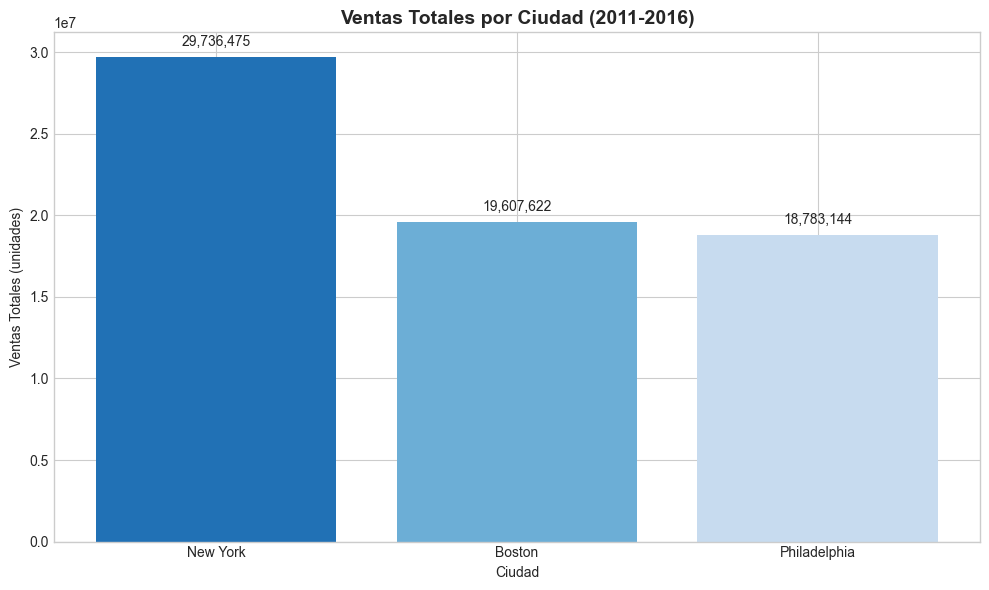

In [43]:
print("ANÁLISIS DE VENTAS POR CIUDAD")
print("=" * 60)

# Total sales by city
ventas_por_ciudad = df_city_daily.groupby('city')['total_sales'].sum().sort_values(ascending=False)

print("\n   Ventas totales por ciudad:")
for city, sales in ventas_por_ciudad.items():
    pct = (sales / ventas_por_ciudad.sum()) * 100
    print(f"      {city}: {sales:>12,} unidades ({pct:.2f}%)")

print(f"\n   TOTAL: {ventas_por_ciudad.sum():>12,} unidades")

# Graphic
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(ventas_por_ciudad.index, ventas_por_ciudad.values, color=sns.color_palette("Blues_r", len(ventas_por_ciudad)))
ax.set_xlabel('Ciudad')
ax.set_ylabel('Ventas Totales (unidades)')
ax.set_title('Ventas Totales por Ciudad (2011-2016)', fontsize=14, fontweight='bold')

# Add values ​​above the bars
for bar, val in zip(bars, ventas_por_ciudad.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500000, f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Conclusión:**  
*  En la ciudad de **New York** es donde más se venden productos con respecto a **Boston** y **Philadelphia**.
*  Las ciudades **Boston** y **Philadelphia** comparten casi la misma cantidad de ventas.

#### 6.1.2 Evolución de ventas diarias por ciudad

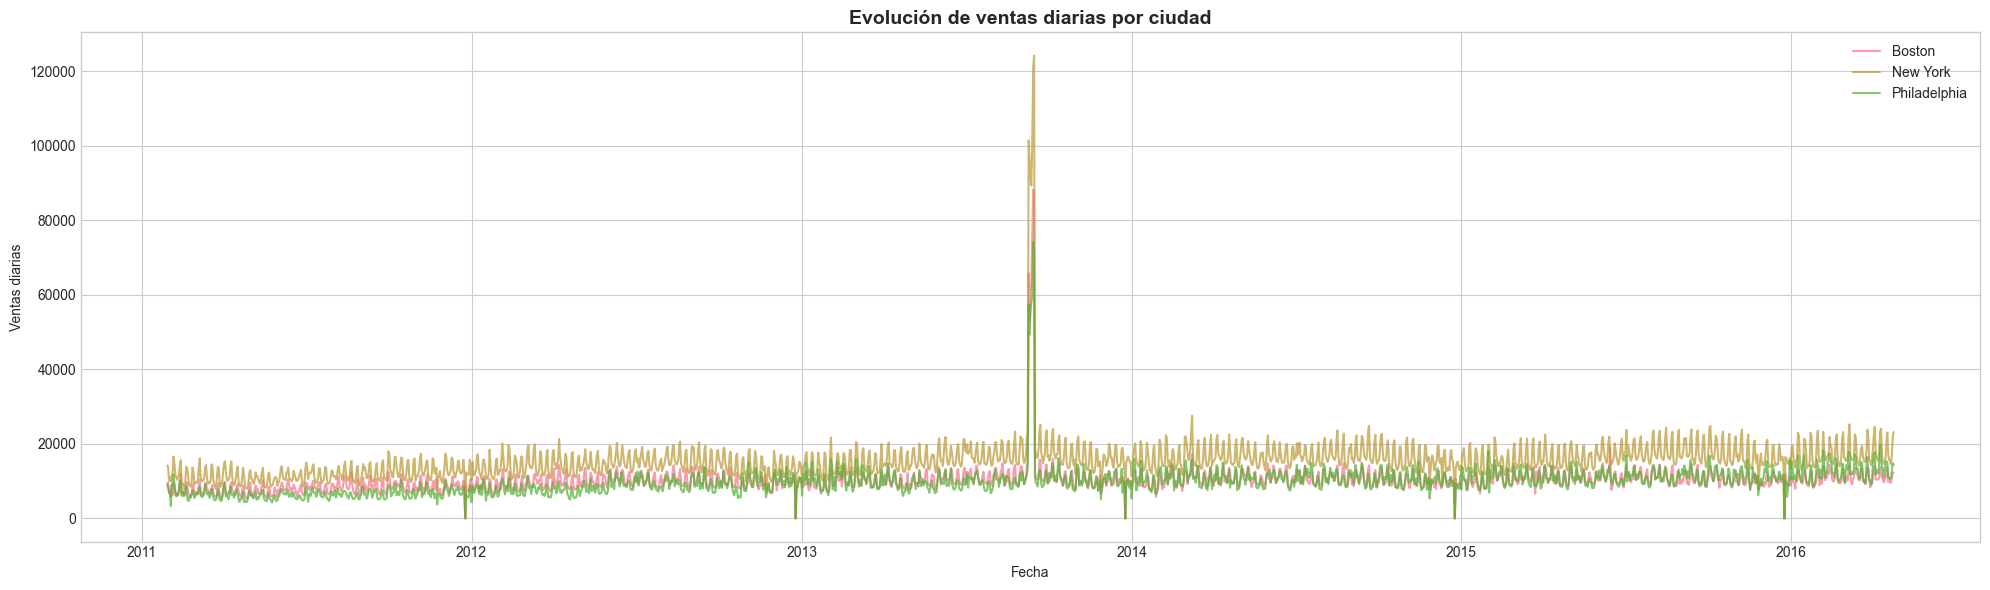

In [44]:
# Graphic
fig, ax = plt.subplots(figsize=(20, 6))

for city in df_city_daily['city'].unique():
    city_data = df_city_daily[df_city_daily['city'] == city]
    ax.plot(city_data['date'], city_data['total_sales'], label=city, alpha=0.7)

ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas diarias')
ax.set_title('Evolución de ventas diarias por ciudad', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
print("ANÁLISIS DE PICOS EN LA EVOLUCIÓN DE VENTAS DIARIAS POR CIUDAD")
print("=" * 60)

# Check peak
for city in df_city_daily['city'].unique():
    mask = (df_city_daily['city'] == city) & (df_city_daily['date'] >= "2013-01-01") & (df_city_daily['date'] <= "2014-01-01")
    city_data = df_city_daily[mask].groupby(['city', 'date'])['total_sales'].sum().reset_index()
    peak_row = city_data.loc[city_data['total_sales'].idxmax()]
    peak_date = peak_row['date']

    print(f"\n   Pico máximo en {city}:")
    print(f"      Fecha: {peak_date.date()} | Ventas: {peak_row['total_sales']:,.0f}")

    # Extract events from peak week
    peak_year = peak_date.year
    peak_week = peak_date.isocalendar().week

    events_mask = (df_city_daily['city'] == city) & \
        (df_city_daily['date'].dt.year == peak_year) & \
        (df_city_daily['date'].dt.isocalendar().week == peak_week) & \
        (df_city_daily['event'].notna()
    )

    events_in_week = df_city_daily[events_mask]['event'].unique()

    if len(events_in_week) > 0:
        print(f"   Eventos detectados semana {peak_week}: {', '.join(events_in_week)}")
    else:
        print(f"   Eventos detectados semana {peak_week}: Ninguno registrado en el dataset.")

ANÁLISIS DE PICOS EN LA EVOLUCIÓN DE VENTAS DIARIAS POR CIUDAD

   Pico máximo en Boston:
      Fecha: 2013-09-14 | Ventas: 88,169
   Eventos detectados semana 37: Ninguno registrado en el dataset.

   Pico máximo en New York:
      Fecha: 2013-09-15 | Ventas: 124,184
   Eventos detectados semana 37: Ninguno registrado en el dataset.

   Pico máximo en Philadelphia:
      Fecha: 2013-09-14 | Ventas: 74,145
   Eventos detectados semana 37: Ninguno registrado en el dataset.


**CONCLUSIÓN:**  
*  Los picos ocurren exactamente alrededor de la semana 37 de 2013, que es a mediados de septiembre. Esto descarta un error local de una tienda y confirma que es un fenómeno sistémico.  
*  Estos son los posibles casos:
   *  Un posible lanzamiento de producto, volumen de reservas entrando al sistema.
   *  Calendario escolar, suelen empezar entre finales de Agosto y principios de Septiembre. Podría deberse a la campaña "Back to School".

#### 6.1.3 Evolución de ventas mensuales por ciudad

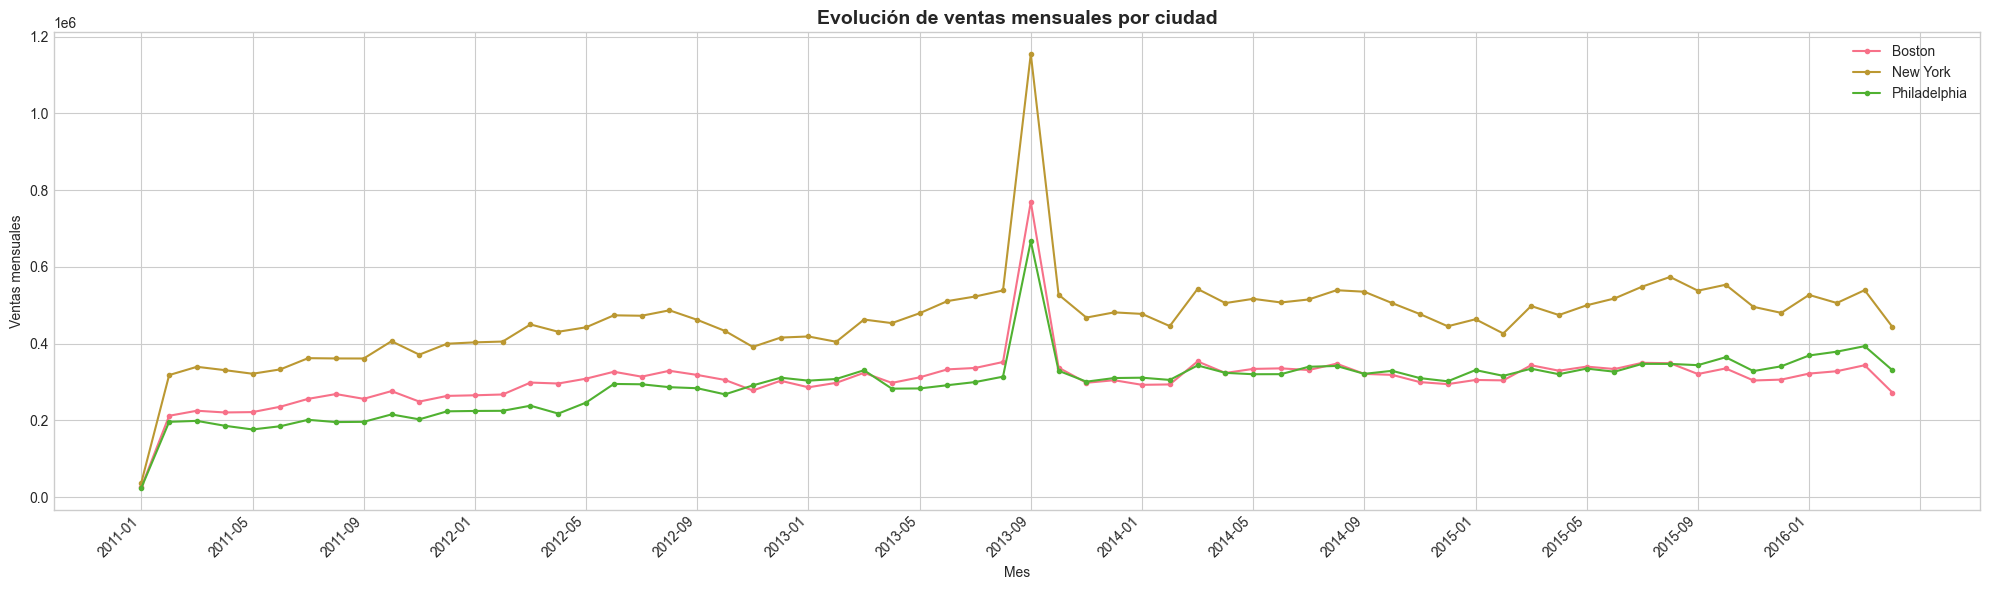

In [46]:
df_city_monthly = df_city_daily.copy()
df_city_monthly['year_month'] = df_city_monthly['date'].dt.to_period('M')
df_city_monthly_agg = df_city_monthly.groupby(['city', 'year_month'])['total_sales'].sum().reset_index()

# Graphic
fig, ax = plt.subplots(figsize=(20, 6))

for city in df_city_monthly_agg['city'].unique():
    city_data = df_city_monthly_agg[df_city_monthly_agg['city'] == city]
    ax.plot(city_data['year_month'].astype(str), city_data['total_sales'], label=city, marker='o', markersize=3)

ax.set_xlabel('Mes')
ax.set_ylabel('Ventas mensuales')
ax.set_title('Evolución de ventas mensuales por ciudad', fontsize=14, fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.tight_layout()
plt.show()

#### 6.1.4 Ventas promedio por día de la semana y ciudad

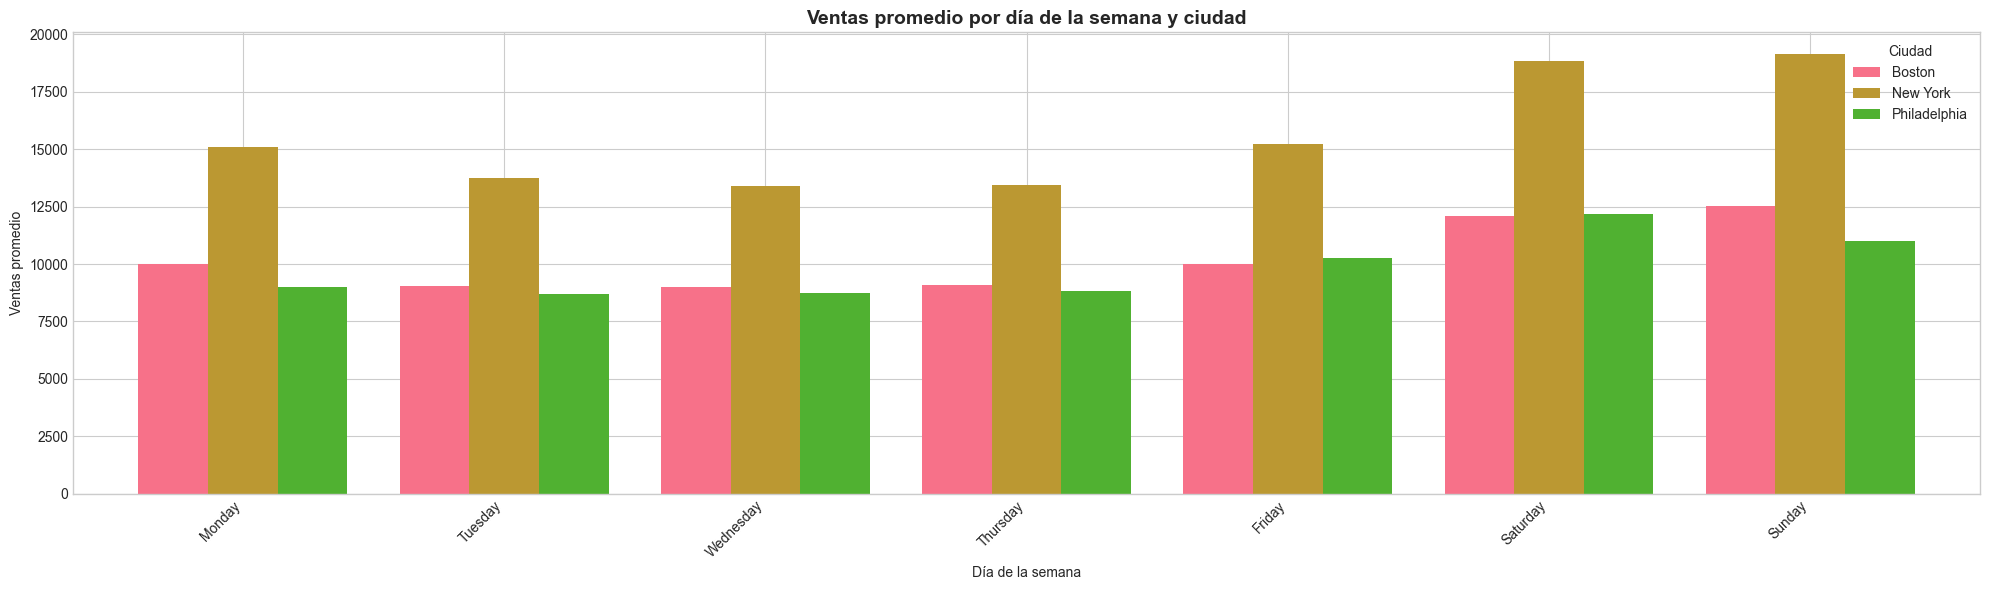

In [47]:
ventas_por_weekday = df_city_daily.groupby(['city', 'weekday'])['total_sales'].mean().reset_index()

# Sort days
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_por_weekday['weekday'] = pd.Categorical(ventas_por_weekday['weekday'], categories=weekday_order, ordered=True)
ventas_por_weekday = ventas_por_weekday.sort_values('weekday')

# Graphic
fig, ax = plt.subplots(figsize=(20, 6))
ventas_pivot = ventas_por_weekday.pivot(index='weekday', columns='city', values='total_sales')
ventas_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Día de la semana')
ax.set_ylabel('Ventas promedio')
ax.set_title('Ventas promedio por día de la semana y ciudad', fontsize=14, fontweight='bold')
ax.legend(title='Ciudad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusión:**  
*  Se puede observar que el miércoles es el día con las ventas promedio más bajas en las tres ciudades. Es el "punto muerto" de la semana laboral.
*  Hay un crecimiento progresivo que empieza el viernes y explota el Domingo, que es el día de mayores ventas para **New York**, mientras que para **Boston** y **Philadelphia** parece estar muy igualado con el sábado.

In [48]:
# Weekend vs Weekday analysis
print("\nANÁLISIS FIN DE SEMANA VS. DÍA DE SEMANA")
print("=" * 60)

weekend_analysis = df_city_daily.groupby(['city', 'is_weekend'])['total_sales'].mean().reset_index()

for city in df_city_daily['city'].unique():
    city_data = weekend_analysis[weekend_analysis['city'] == city]
    weekday_sales = city_data[city_data['is_weekend'] == 0]['total_sales'].values[0]
    weekend_sales = city_data[city_data['is_weekend'] == 1]['total_sales'].values[0]

    if weekday_sales > 0:
        ratio = (weekend_sales / weekday_sales - 1) * 100
    else:
        ratio = 0

    print(f"\n   Para la ciudad {city}:")
    print(f"      Promedio en día de semana: {weekday_sales:>10,.2f}")
    print(f"      Promedio en fin de semana: {weekend_sales:>10,.2f}")
    print(f"      Diferencia:  {ratio:>+10,.2f}%")


ANÁLISIS FIN DE SEMANA VS. DÍA DE SEMANA

   Para la ciudad Boston:
      Promedio en día de semana:   9,427.38
      Promedio en fin de semana:  12,297.90
      Diferencia:      +30.45%

   Para la ciudad New York:
      Promedio en día de semana:  14,168.88
      Promedio en fin de semana:  18,970.72
      Diferencia:      +33.89%

   Para la ciudad Philadelphia:
      Promedio en día de semana:   9,106.67
      Promedio en fin de semana:  11,592.22
      Diferencia:      +27.29%


**Conclusión:**  
*  Hay un aumento de ventas de entre el 27-33% los fin de semana vs. días de la semana.

### 6.2 Análisis de Productos

#### 6.2.1 Top 20 productos más vendidos

TOP PRODUCTOS MÁS VENDIDOS

   Top 20 productos más vendidos:
      SUPERMARKET_3_090               SUPERMARKET_3               1,099,745 unidades
      SUPERMARKET_3_586               SUPERMARKET_3                 946,882 unidades
      SUPERMARKET_3_252               SUPERMARKET_3                 584,043 unidades
      SUPERMARKET_3_555               SUPERMARKET_3                 504,495 unidades
      SUPERMARKET_3_714               SUPERMARKET_3                 409,636 unidades
      SUPERMARKET_3_694               SUPERMARKET_3                 404,177 unidades
      SUPERMARKET_3_587               SUPERMARKET_3                 398,151 unidades
      SUPERMARKET_3_226               SUPERMARKET_3                 376,818 unidades
      SUPERMARKET_3_723               SUPERMARKET_3                 306,037 unidades
      SUPERMARKET_3_202               SUPERMARKET_3                 303,897 unidades
      SUPERMARKET_3_808               SUPERMARKET_3                 294,199 unidades
   

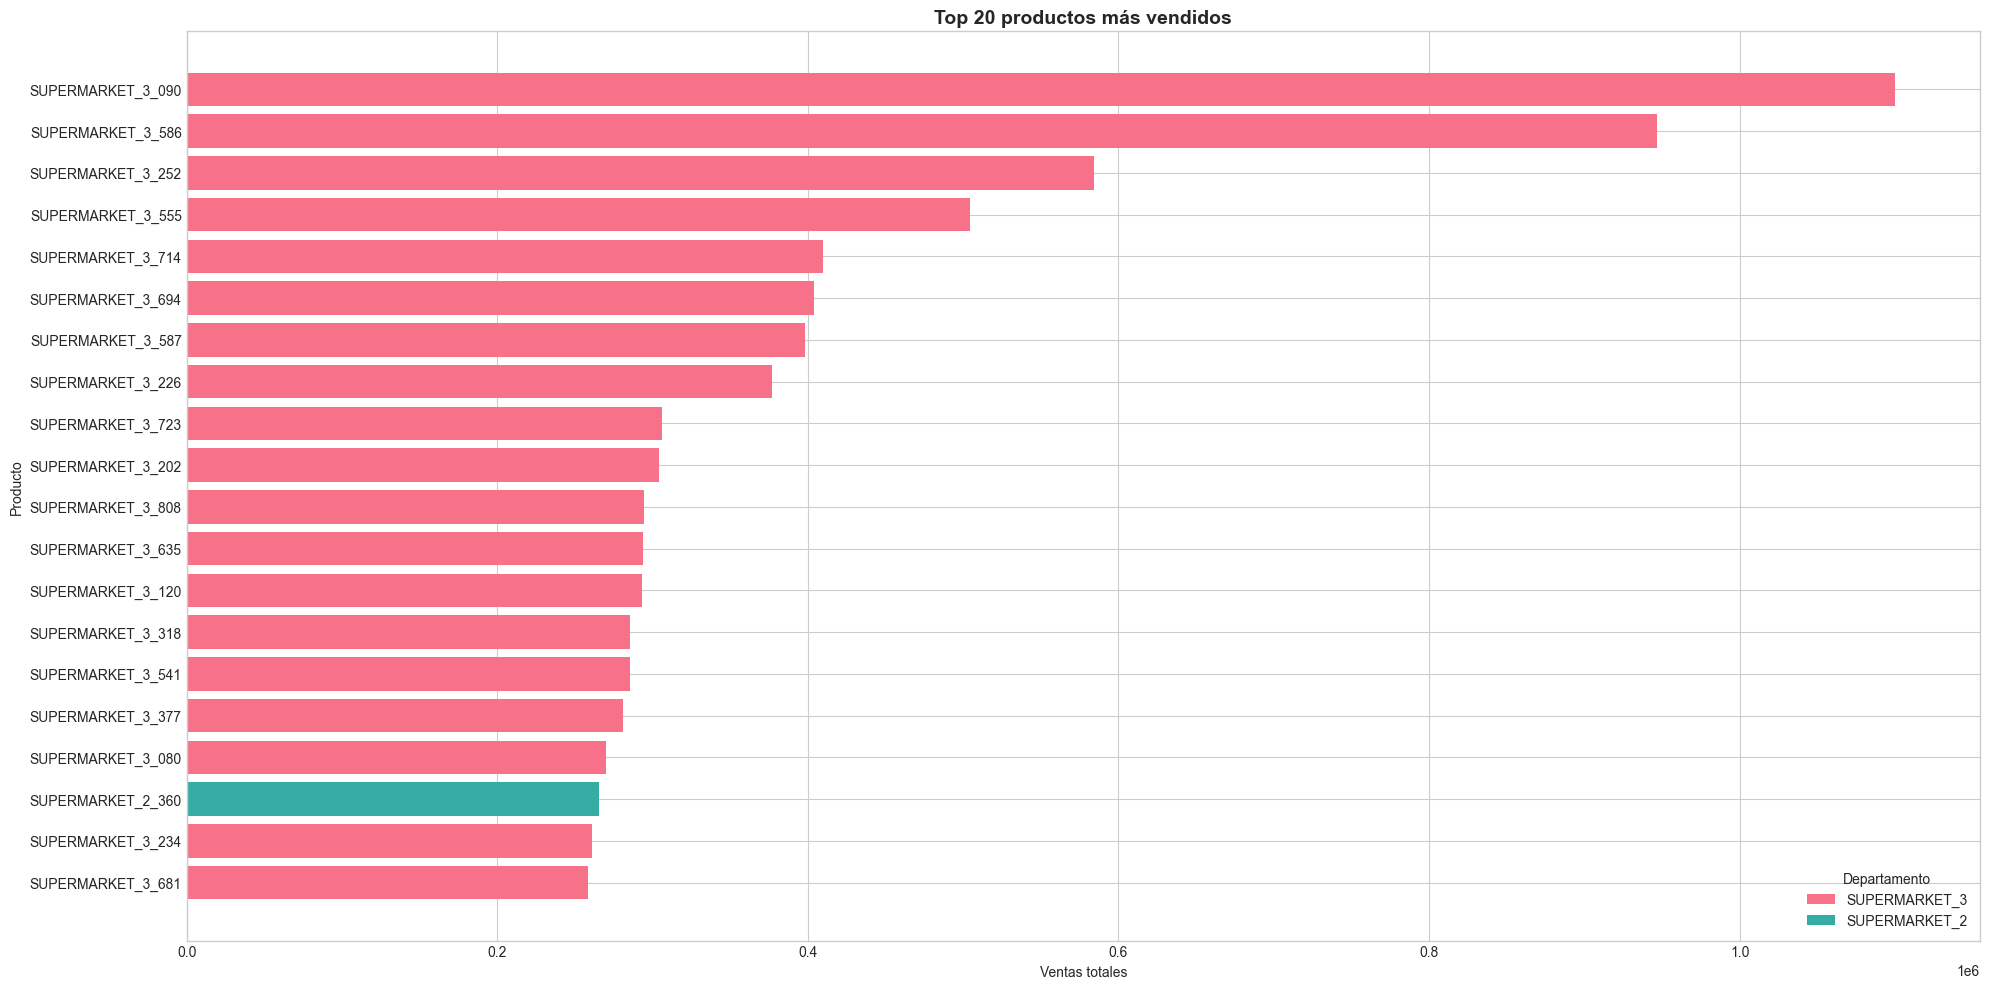

In [49]:
print("TOP PRODUCTOS MÁS VENDIDOS")
print("=" * 60)

# Calculate total sales per product
ventas_por_producto = df_sales_long.groupby(['item', 'category', 'department'])['sales'].sum().reset_index()
ventas_por_producto = ventas_por_producto.sort_values('sales', ascending=False)

# Top 20 products
top_20_productos = ventas_por_producto.head(20)

print("\n   Top 20 productos más vendidos:")
for idx, row in top_20_productos.iterrows():
    print(f"      {row['item']:30s}  {row['department']:20s}  {row['sales']:>15,} unidades")

# Graphic
fig, ax = plt.subplots(figsize=(20, 10))
colors = sns.color_palette("husl", top_20_productos['department'].nunique())
dept_colors = {dept: colors[i] for i, dept in enumerate(top_20_productos['department'].unique())}

bars = ax.barh(top_20_productos['item'], top_20_productos['sales'], color=[dept_colors[d] for d in top_20_productos['department']])

ax.set_xlabel('Ventas totales')
ax.set_ylabel('Producto')
ax.set_title('Top 20 productos más vendidos', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Manual legend for departments
legend_elements = [Patch(facecolor=dept_colors[d], label=d) for d in dept_colors]
ax.legend(handles=legend_elements, title='Departamento', loc='lower right')

plt.tight_layout()
plt.show()

**Conclusión:**  
*  La mayoría de los productos más vendidos pertenecen al **departamento** SUPERMARKET_3.

#### 6.2.2 Distribución por categoría y departamento


ANÁLISIS POR CATEGORÍA Y DEPARTAMENTO

   Ventas por Categoría:
      SUPERMARKET:   46,804,603 (68.70%)
      HOME_&_GARDEN:   15,002,118 (22.02%)
      ACCESORIES:    6,320,520 ( 9.28%)

   Ventas por Departamento:
      SUPERMARKET_3:   33,656,380 (49.40%)
      HOME_&_GARDEN_1:   11,920,350 (17.50%)
      SUPERMARKET_2:    7,886,686 (11.58%)
      ACCESORIES_1:    5,773,356 ( 8.47%)
      SUPERMARKET_1:    5,261,537 ( 7.72%)
      HOME_&_GARDEN_2:    3,081,768 ( 4.52%)
      ACCESORIES_2:      547,164 ( 0.80%)


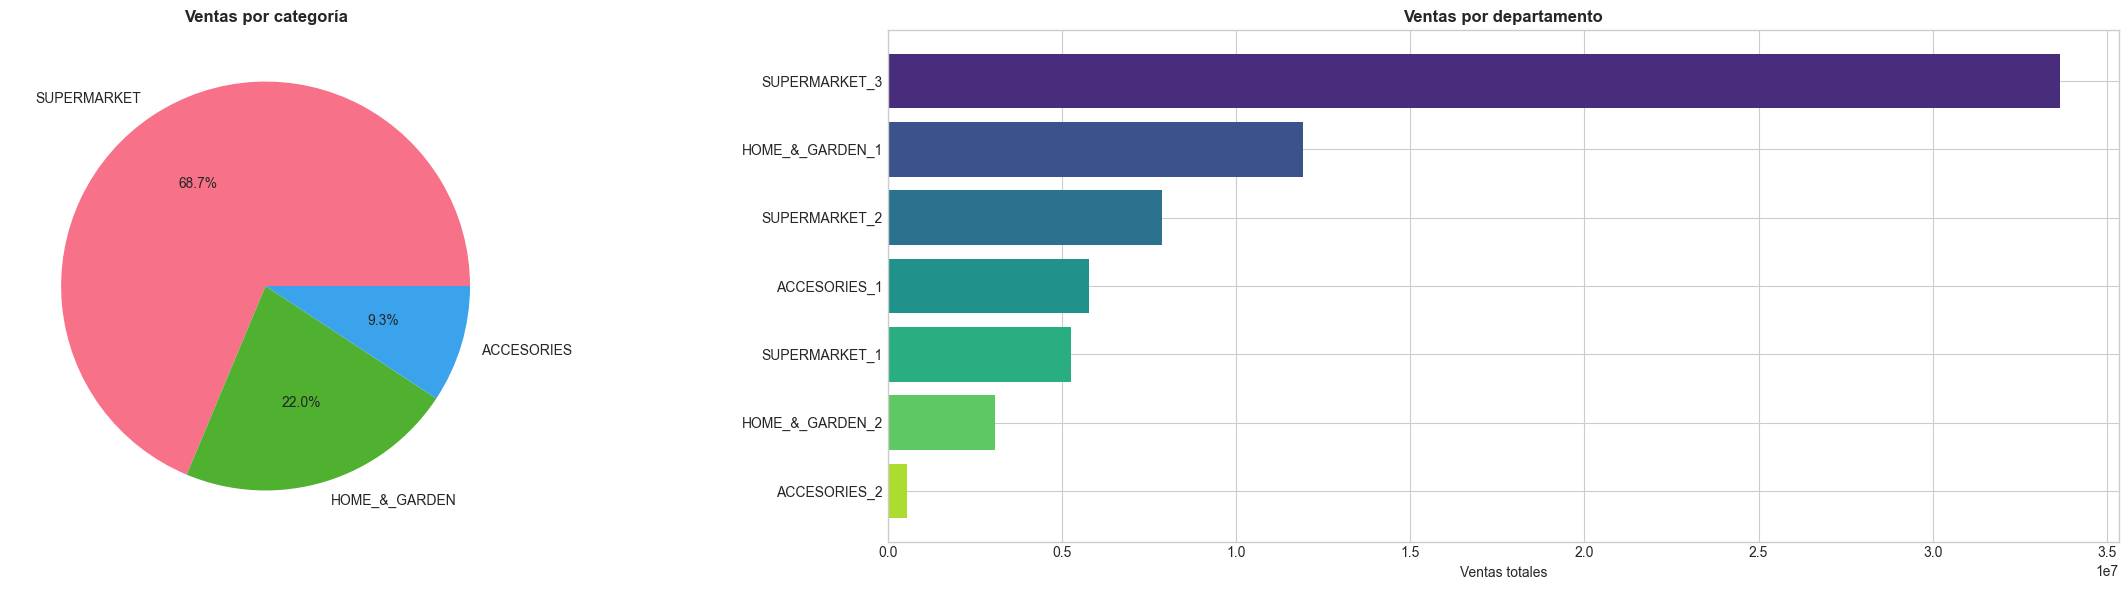

In [50]:
print("\nANÁLISIS POR CATEGORÍA Y DEPARTAMENTO")
print("=" * 60)

# Sales by category
ventas_por_categoria = df_sales_long.groupby('category')['sales'].sum().sort_values(ascending=False)

print("\n   Ventas por Categoría:")
for cat, sales in ventas_por_categoria.items():
    pct = (sales / ventas_por_categoria.sum()) * 100
    print(f"      {cat}: {sales:>12,} ({pct:>5.2f}%)")

# Sales by department
ventas_por_depto = df_sales_long.groupby('department')['sales'].sum().sort_values(ascending=False)
print("\n   Ventas por Departamento:")
for dept, sales in ventas_por_depto.items():
    pct = (sales / ventas_por_depto.sum()) * 100
    print(f"      {dept}: {sales:>12,} ({pct:>5.2f}%)")

# Graph with subplots
fig, axes = plt.subplots(1, 2, figsize=(25, 6))

# Foot chart for categories
axes[0].pie(ventas_por_categoria.values, labels=ventas_por_categoria.index, autopct='%3.1f%%', colors=sns.color_palette("husl", len(ventas_por_categoria)))
axes[0].set_title('Ventas por categoría', fontsize=12, fontweight='bold')

# Horizontal bar chart for departments
axes[1].barh(ventas_por_depto.index, ventas_por_depto.values, color=sns.color_palette("viridis", len(ventas_por_depto)))
axes[1].set_xlabel('Ventas totales')
axes[1].set_title('Ventas por departamento', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Conclusión:**  
*  La categoría **SUPERMARKET** es el motor principal de la empresa, representando el 68.7% del total de las ventas.
*  Dentro de la categoría **SUPERMARKET**, el departamento **SUPERMARKET_3** es el líder en ventas totales, presenta una dominancia de mercado interna superior al 100% respecto a su competidor más cercano.
*  Las categorías de **Home & Garden** (22%) y **Accessories** (9.3%) son complementarias pero mucho menores en volumen.

#### 6.2.3 Mix de categorías por ciudad


MIX DE CATEGORÍAS POR CIUDAD (%)


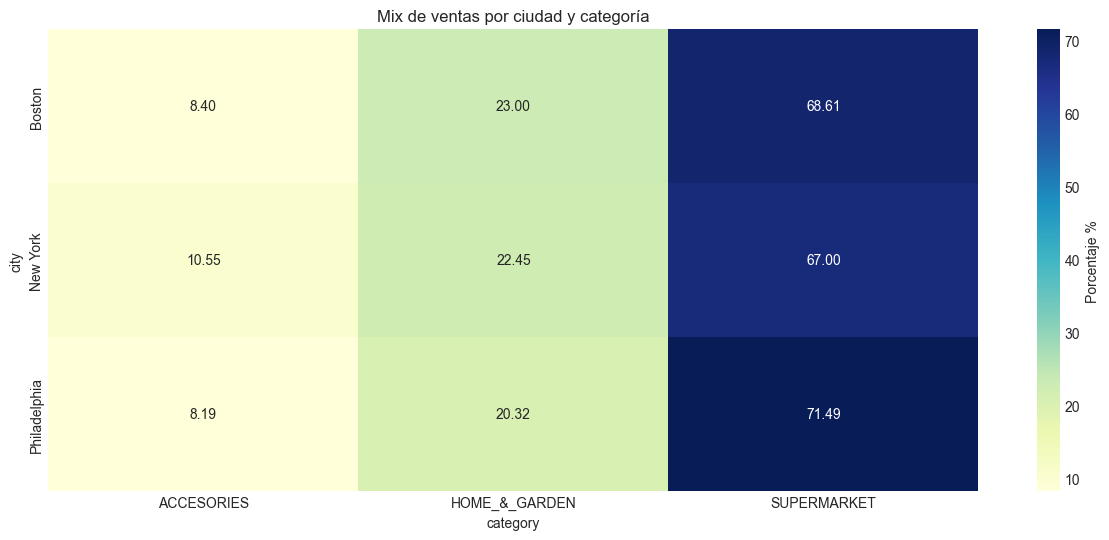

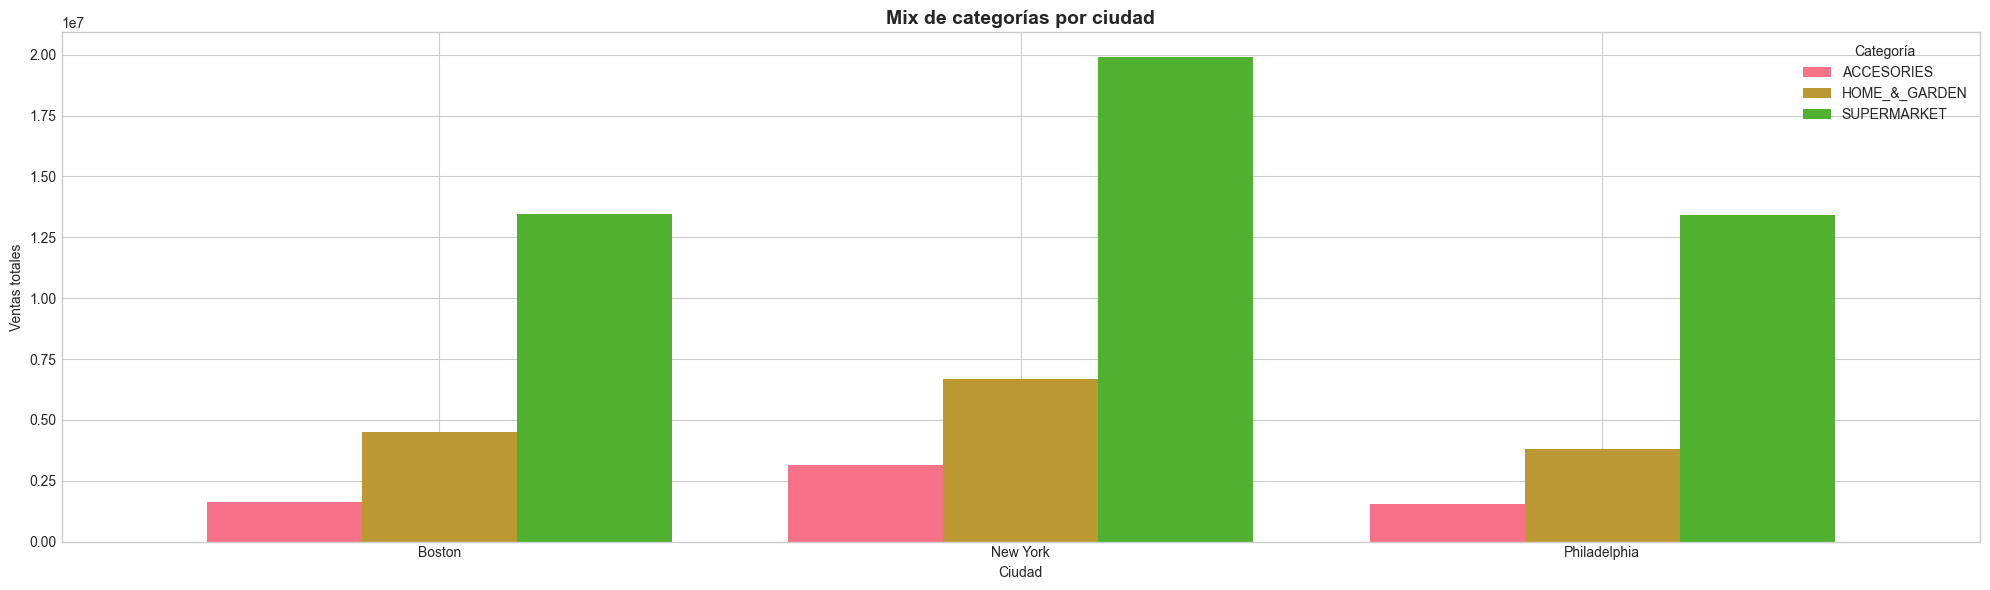

In [51]:
print("\nMIX DE CATEGORÍAS POR CIUDAD (%)")
print("=" * 60)

# Mix of categories by city
mix_ciudad_categoria = df_sales_long.groupby(['city', 'category'])['sales'].sum().reset_index()

mix_pct = mix_ciudad_categoria.pivot(index='city', columns='category', values='sales')
mix_pct_norm = mix_pct.div(mix_pct.sum(axis=1), axis=0) * 100

# Table
plt.figure(figsize=(15, 6))
sns.heatmap(mix_pct_norm, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Porcentaje %'})
plt.title("Mix de ventas por ciudad y categoría")
plt.show()

# Graphic
fig, ax = plt.subplots(figsize=(20, 6))
mix_pivot = mix_ciudad_categoria.pivot(index='city', columns='category', values='sales')
mix_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Ciudad')
ax.set_ylabel('Ventas totales')
ax.set_title('Mix de categorías por ciudad', fontsize=14, fontweight='bold')
ax.legend(title='Categoría')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Conclusiones:**  
*  La categoría **SUPERMARKET** representa casi el 70% de las ventas totales.
*  Aunque la estructura es similar en todas las sedes, **Philadelphia** es la ciudad con mayor dependencia de la alimentación (71.49%), mientras que New York presenta el mix más diversificado con un 10.55% en **ACCESORIES**.

### 6.3 Análisis de Precios

#### 6.3.1 Distribución de precios

ANÁLISIS DE PRECIOS

   Estadísticas descriptivas de precios:
count   6,965,706.00
mean            5.52
std             4.39
min             0.01
25%             2.62
50%             4.20
75%             7.18
max           134.15
Name: sell_price, dtype: float64


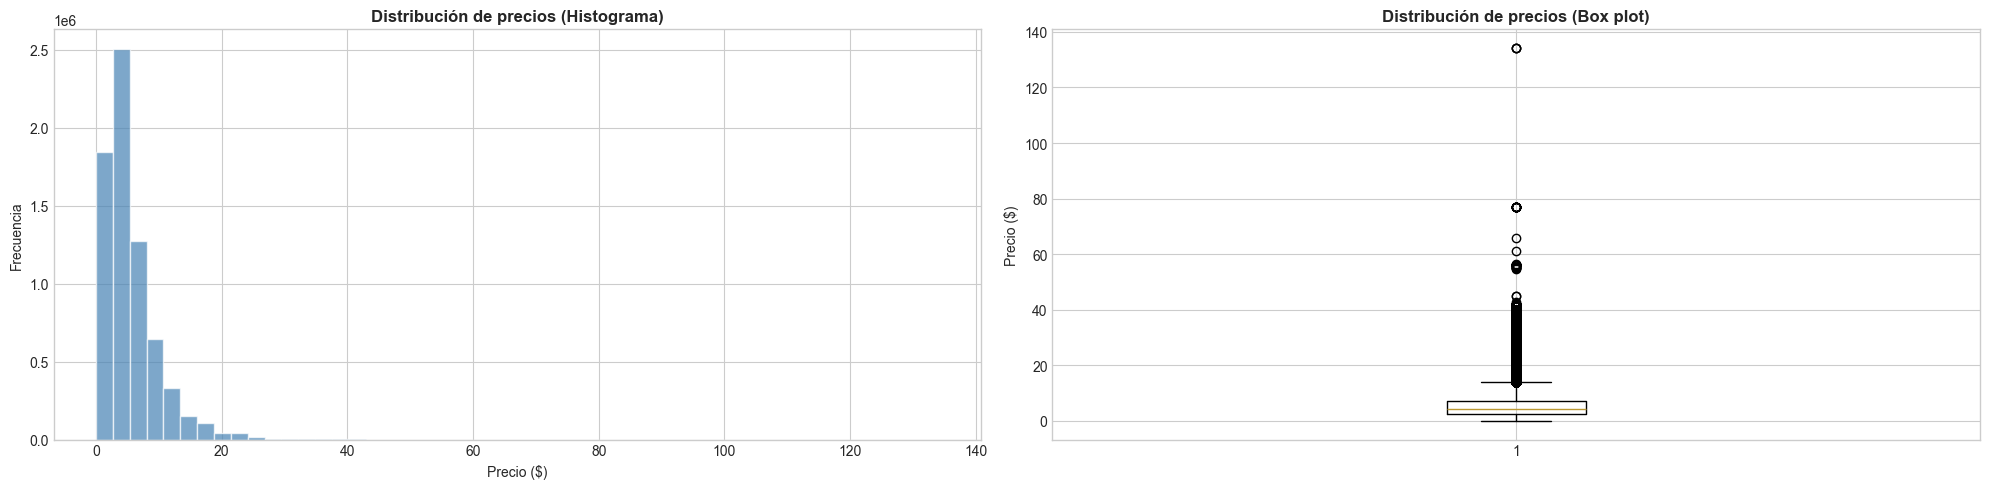


   Precios promedio por categoría:
               mean  median  std
category                        
ACCESORIES     7.09    5.28 6.42
HOME_&_GARDEN  6.83    6.18 4.22
SUPERMARKET    3.90    3.22 2.56


In [52]:
print("ANÁLISIS DE PRECIOS")
print("=" * 60)

print("\n   Estadísticas descriptivas de precios:")
print(df_prices['sell_price'].describe())

# Graph with subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Histogram
axes[0].hist(df_prices['sell_price'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de precios (Histograma)', fontsize=12, fontweight='bold')

# Box plot
axes[1].boxplot(df_prices['sell_price'], vert=True)
axes[1].set_ylabel('Precio ($)')
axes[1].set_title('Distribución de precios (Box plot)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Prices by category
print("\n   Precios promedio por categoría:")
precios_por_categoria = df_prices.groupby('category')['sell_price'].agg(['mean', 'median', 'std']).round(2)
print(precios_por_categoria)

**Conclusión:**  
*  El histograma muestra una distribución con sesgo positivo (a la derecha); la gran mayoría de los productos son baratos (menos de 10$), pero existen "colas" largas de productos caros.
*  El Boxplot revela valores atípicos que llegan hasta los 134.15$, mientras que la mediana general es de apenas 4.20$.
*  **ACCESORIES** es la categoría más cara (media 7.09) y la más volátil (desviación estándar de 6.42), lo que sugiere un catálogo muy variado.
*  **SUPERMARKET** tiene los precios más bajos (3.90) y estables, confirmando su rol como producto de alta rotación y bajo margen.

#### 6.3.2 Variación de precios


ANÁLISIS DE VARIACIÓN DE PRECIOS ENTRE TIENDAS

   Top 10 productos con mayor variación de precio entre tiendas:
      HOME_&_GARDEN_2_406            |   Min: $  4.07   |   Max: $134.15   |   Range: $130.07
      HOME_&_GARDEN_2_466            |   Min: $  7.46   |   Max: $ 65.77   |   Range: $ 58.31
      HOME_&_GARDEN_2_178            |   Min: $  3.75   |   Max: $ 55.45   |   Range: $ 51.70
      HOME_&_GARDEN_2_250            |   Min: $  4.20   |   Max: $ 42.73   |   Range: $ 38.52
      HOME_&_GARDEN_2_514            |   Min: $  1.25   |   Max: $ 26.21   |   Range: $ 24.96
      ACCESORIES_1_342               |   Min: $  2.66   |   Max: $ 27.11   |   Range: $ 24.45
      HOME_&_GARDEN_1_469            |   Min: $  1.25   |   Max: $ 25.58   |   Range: $ 24.33
      ACCESORIES_1_257               |   Min: $ 10.59   |   Max: $ 34.31   |   Range: $ 23.73
      HOME_&_GARDEN_1_342            |   Min: $  1.25   |   Max: $ 22.46   |   Range: $ 21.21
      HOME_&_GARDEN_1_102            |  

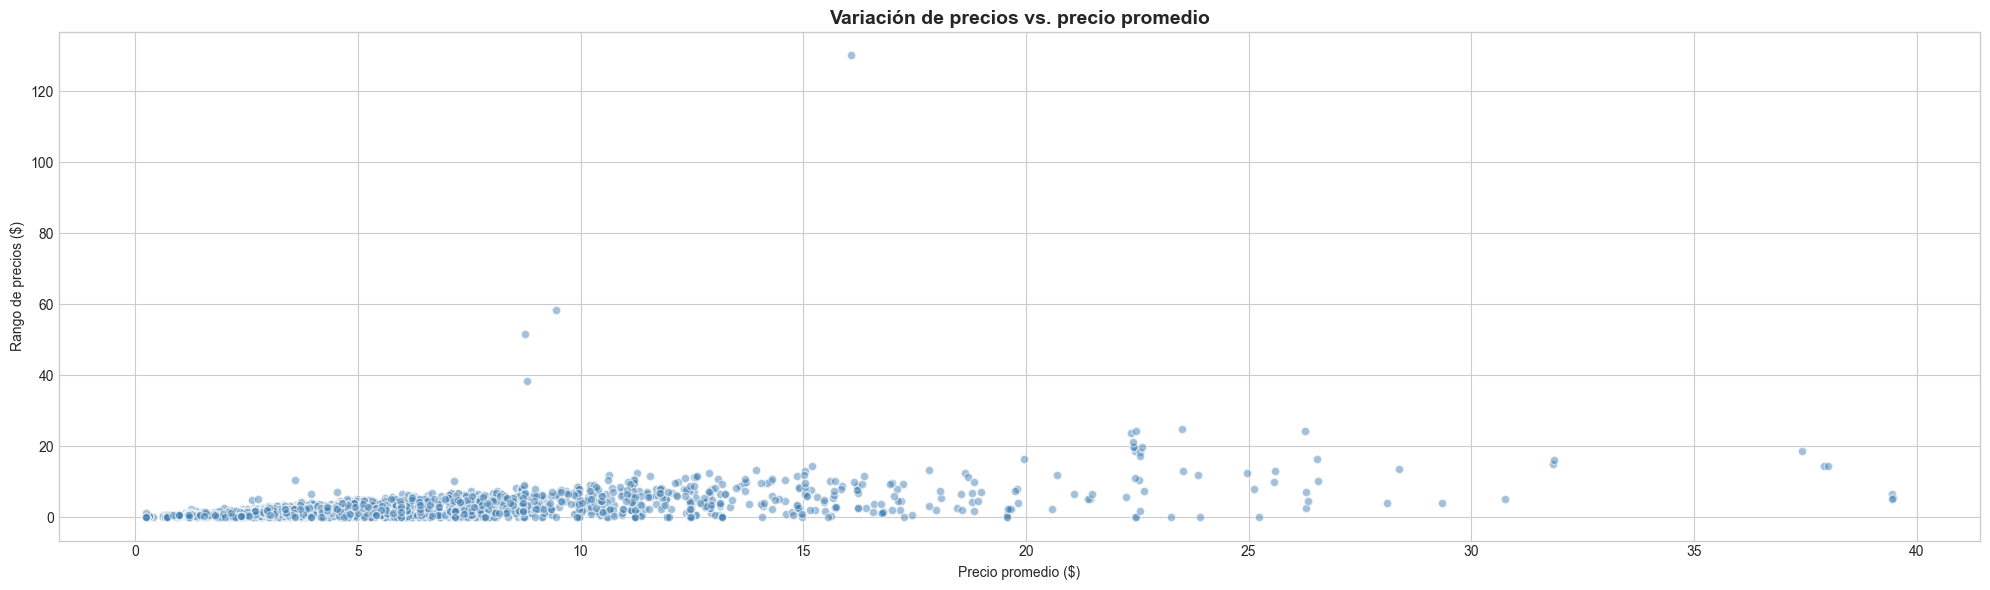

In [53]:
print("\nANÁLISIS DE VARIACIÓN DE PRECIOS ENTRE TIENDAS")
print("=" * 60)

# For each product, calculate the price variation
price_variation = df_prices.groupby('item')['sell_price'].agg(['min', 'max', 'mean', 'std']).reset_index()
price_variation['price_range'] = price_variation['max'] - price_variation['min']

# Top products with the greatest variation
top_variation = price_variation.nlargest(10, 'price_range')

print("\n   Top 10 productos con mayor variación de precio entre tiendas:")
for idx, row in top_variation.iterrows():
    print(f"      {row['item']:30s} |   Min: ${row['min']:>6.2f}   |   Max: ${row['max']:>6.2f}   |   Range: ${row['price_range']:>6.2f}")

# Scatter chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.scatter(price_variation['mean'], price_variation['price_range'], alpha=0.5, c='steelblue', edgecolors='white')
ax.set_xlabel('Precio promedio ($)')
ax.set_ylabel('Rango de precios ($)')
ax.set_title('Variación de precios vs. precio promedio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión:**  
*  Se observa que a mayor precio promedio, tiende a haber un rango de variación mayor entre tiendas.
*  Hay items, como **HOME_&_GARDEN_2_406**, que tienen un rango de precio alto (de $4.07 a $134.15). Esto puede ser por errores de carga de datos, o por estrategias de liquidación agresivas en tiendas específicas.

#### 6.3.3 Evolución temporal de precios

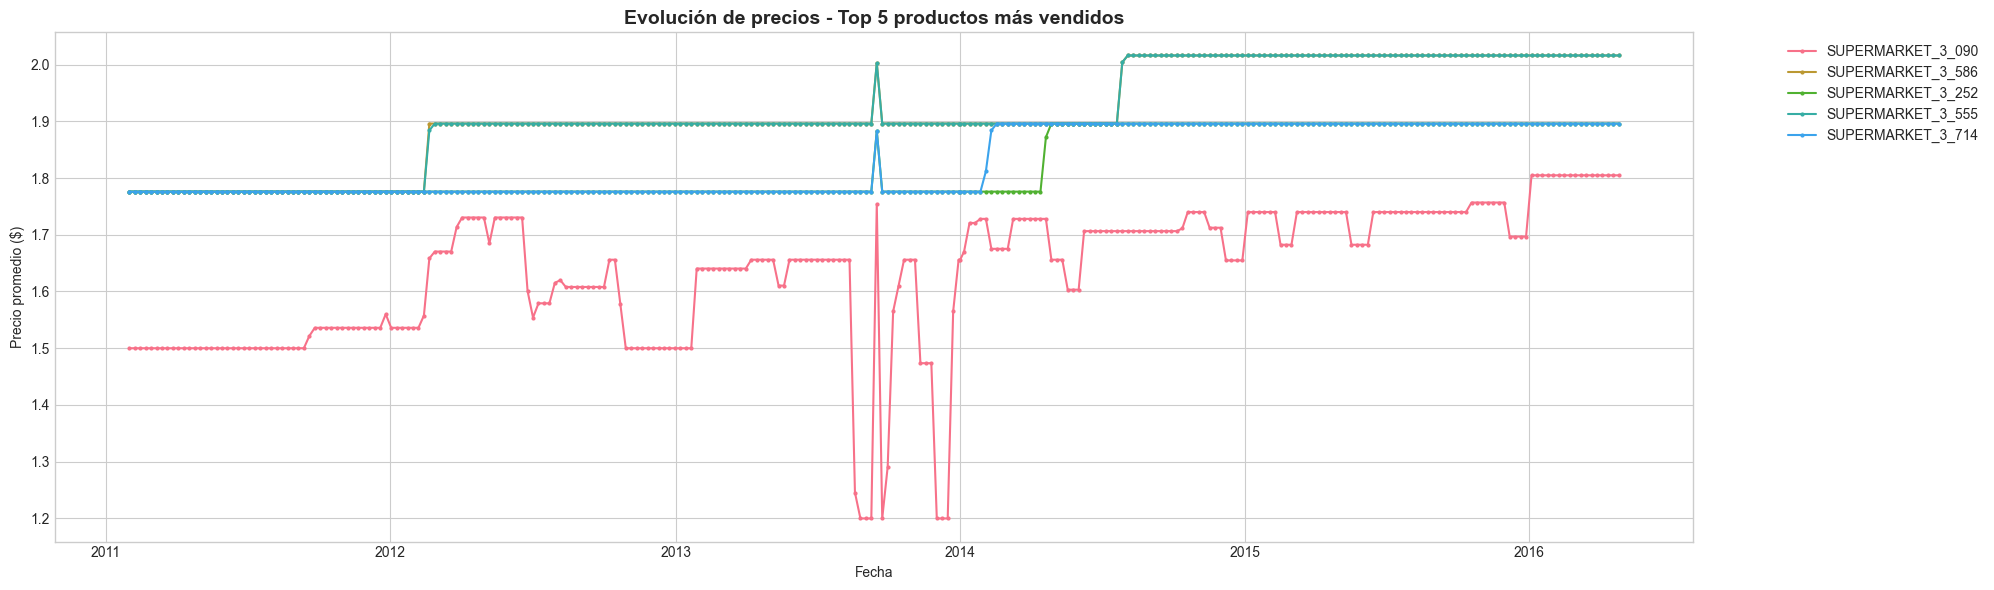

In [54]:
# Price evolution for top products
top_5_items = ventas_por_producto.head(5)['item'].tolist()
prices_top_items = df_prices[df_prices['item'].isin(top_5_items)].copy()

prices_top_items['date'] = prices_top_items['yearweek'].apply(yearweek_to_date)
prices_top_items = prices_top_items.dropna(subset=['date'])

# Average price per week
prices_top_weekly = prices_top_items.groupby(['item', 'date'])['sell_price'].mean().reset_index()

# Graph
fig, ax = plt.subplots(figsize=(20, 6))

for item in top_5_items:
    item_data = prices_top_weekly[prices_top_weekly['item'] == item]
    ax.plot(item_data['date'], item_data['sell_price'], label=item, marker='o', markersize=2)

ax.set_xlabel('Fecha')
ax.set_ylabel('Precio promedio ($)')
ax.set_title('Evolución de precios - Top 5 productos más vendidos', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Conclusión:**  
*  Se observa que hay una caída drástica y volátil en los precios de los productos más vendidos justo en la segunda mitad de 2013. Esto coincide temporalmente con los picos masivos de ventas que vimos en otras gráficas anteriores.
*  El aumento de ventas no fue orgánico; fue provocado por una agresiva bajada de precios o promociones de alto impacto en los productos líderes.

### 6.4 Análisis Temporal

#### 6.4.1 Estacionalidad por mes

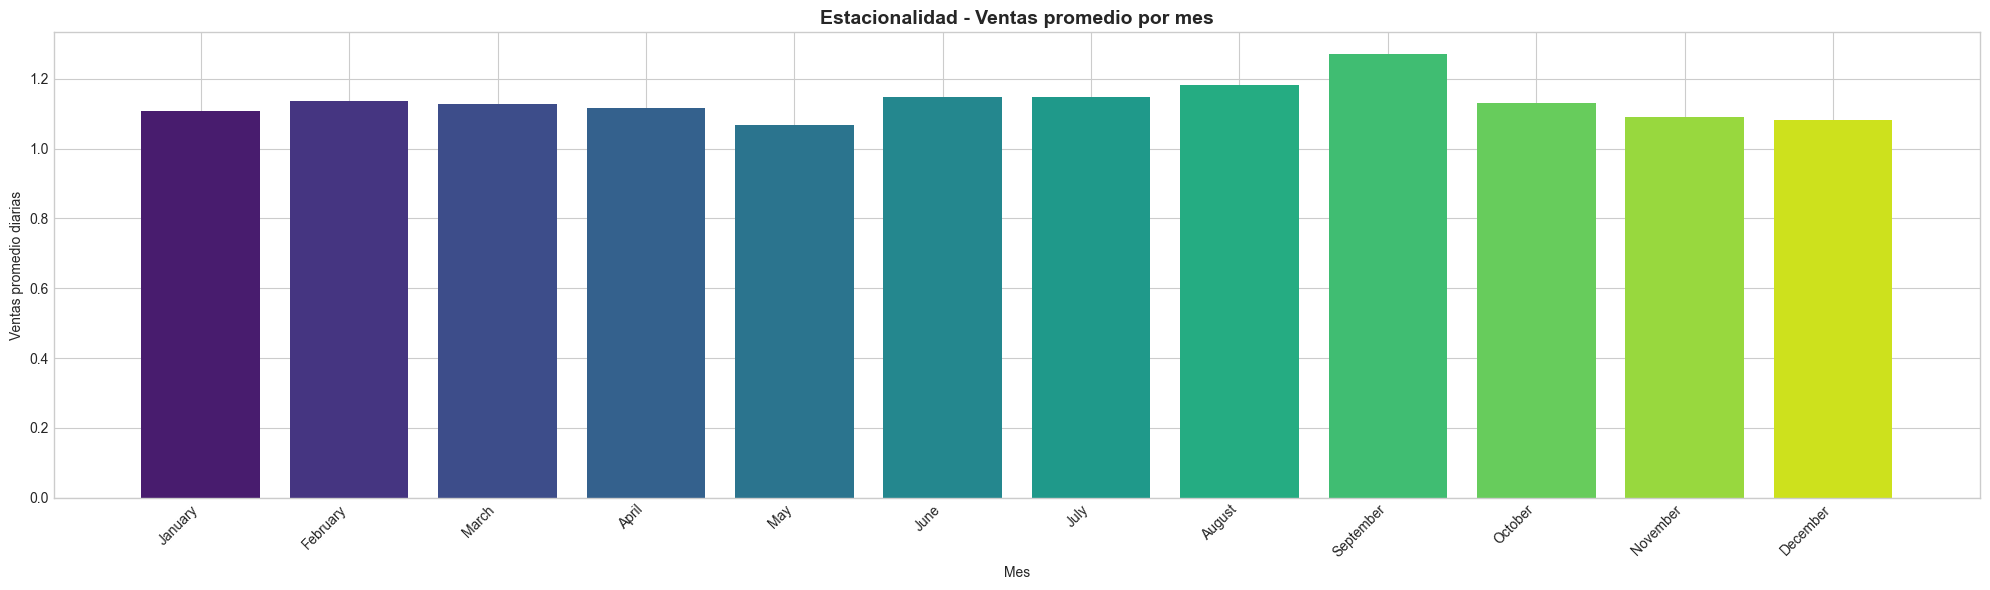


Ventas promedio por mes:
month_name  sales
   January   1.11
  February   1.14
     March   1.13
     April   1.12
       May   1.07
      June   1.15
      July   1.15
    August   1.18
 September   1.27
   October   1.13
  November   1.09
  December   1.08


In [55]:
# Average sales per month
ventas_por_mes = df_sales_long.groupby('month')['sales'].mean().reset_index()
ventas_por_mes['month_name'] = ventas_por_mes['month'].apply(lambda x: pd.to_datetime(f'2020-{x:02d}-01').strftime('%B'))

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
ventas_por_mes['month_name'] = pd.Categorical(ventas_por_mes['month_name'], categories=month_order, ordered=True)
ventas_por_mes = ventas_por_mes.sort_values('month_name')

# Graphic
fig, ax = plt.subplots(figsize=(20, 6))
colors = sns.color_palette("viridis", len(ventas_por_mes))
bars = ax.bar(ventas_por_mes['month_name'], ventas_por_mes['sales'], color=colors)

ax.set_xlabel('Mes')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Estacionalidad - Ventas promedio por mes', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nVentas promedio por mes:")
print(ventas_por_mes[['month_name', 'sales']].to_string(index=False))

**Conclusión:**  
*  **Septiembre** se consolida como el mes de mayor actividad promedio, lo cual es consistente con el gran pico histórico observado.

#### 6.4.2 Heatmap mes vs. día de semana

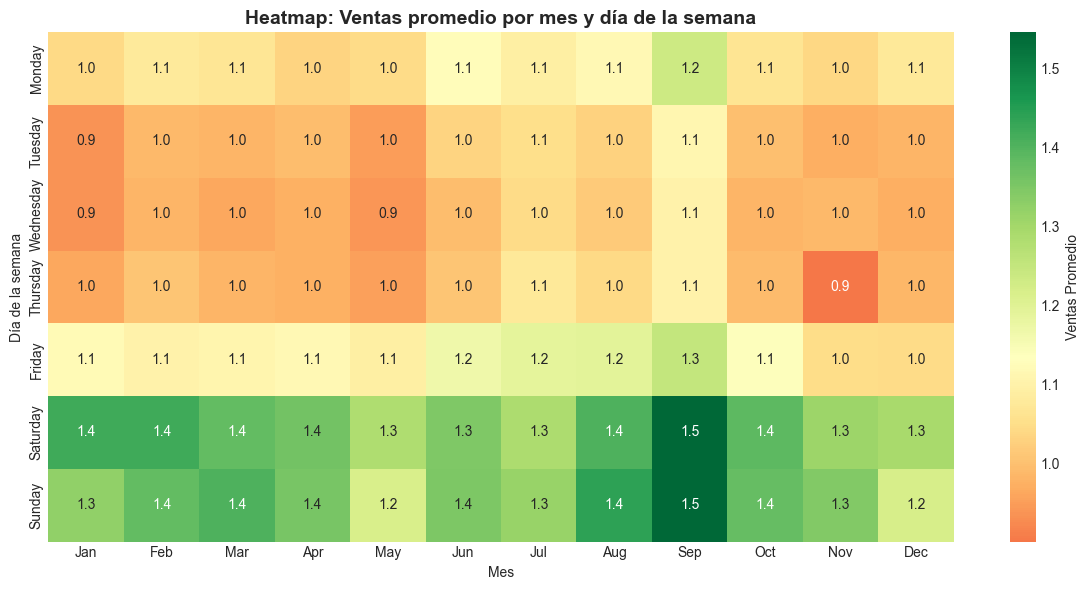

In [56]:
# Necesitamos weekday en df_sales_long
if 'weekday' not in df_sales_long.columns:
    df_sales_long['weekday'] = df_sales_long['date'].dt.day_name()

heatmap_data = df_sales_long.groupby(['month', 'weekday'])['sales'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='weekday', columns='month', values='sales')
df_sales_long = df_sales_long.drop(columns='weekday')

# Sort days
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot.reindex(weekday_order)

# Rename columns with month names
month_names = {i: pd.to_datetime(f'2020-{i:02d}-01').strftime('%b') for i in range(1, 13)}
heatmap_pivot.columns = [month_names[col] for col in heatmap_pivot.columns]

# Graphic
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=heatmap_pivot.values.mean(), ax=ax, cbar_kws={'label': 'Ventas Promedio'})

ax.set_xlabel('Mes')
ax.set_ylabel('Día de la semana')
ax.set_title('Heatmap: Ventas promedio por mes y día de la semana', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión:**  
*  El heatmap de ventas por mes y día de la semana confirma que, sistemáticamente, el sábado y el domingo son los días de mayor actividad durante todo el año.
*  No solo hubo un pico en 2013; los datos promediados muestran que septiembre es el mes con mayor volumen de ventas diarias de todo el calendario.
*  El sábado de septiembre es, estadísticamente, el momento de mayor facturación del año.

<a id='ACF_PACF_Desc'></a>
#### 6.4.3 ACF/PACF + Descomposición

Antes de construir features para el modelo, es necesario entender la estructura temporal de las ventas. Este análisis responde tres preguntas clave sobre el comportamiento de la serie:

1. **¿Las ventas pasadas predicen las ventas futuras y con qué periodicidad?**
    -> ACF/PACF: miden la correlación entre el valor actual y sus valores anteriores, revelando qué períodos históricos tienen mayor poder predictivo.

2. **¿Existe un patrón estacional que se repite en el tiempo?**
    -> Descomposición estacional: separa la serie en tendencia, estacionalidad y ruido, permitiendo identificar si hay ciclos semanales, mensuales u otros.

3. **¿Es la serie estacionaria?**
    -> Test Dickey-Fuller (ADF): verifica si la media y varianza son constantes a lo largo del tiempo, lo cual determina si la serie requiere transformaciones antes de modelarla.

El análisis se realiza sobre el producto más vendido del dataset, ya que al tener mayor volumen de ventas su serie es más continua y los patrones son más visibles e interpretables.

In [57]:
# Elegir el producto más vendido como representativo
item_id_sample  = df_sales_long.groupby('item')['sales'].sum().idxmax()
store_id_sample = df_sales_long['store_code'].iloc[0]

item_ts = df_sales_long[
    (df_sales_long['item'] == item_id_sample) &
    (df_sales_long['store_code'] == store_id_sample)
].set_index('date')['sales'].sort_index()

print(f"Producto analizado: {item_id_sample} | Tienda: {store_id_sample}")
print(f"Período: {item_ts.index.min()} -> {item_ts.index.max()} ({len(item_ts)} días)")

Producto analizado: SUPERMARKET_3_090 | Tienda: BOS_1
Período: 2011-01-29 00:00:00 -> 2016-04-24 00:00:00 (1969 días)


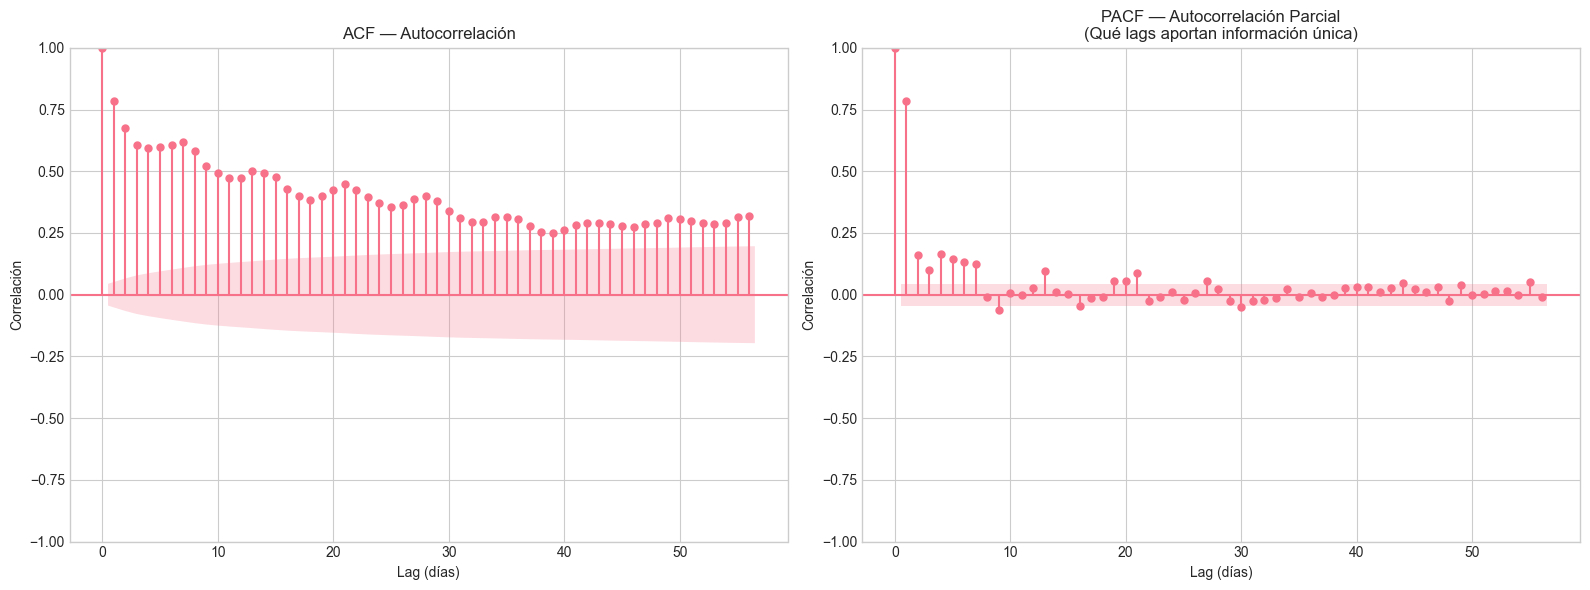

In [58]:
# ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(item_ts.dropna(), lags=56, ax=axes[0])
# axes[0].set_title('ACF — Autocorrelación\n(Picos en 7 y 28 confirman patrón semanal/mensual)')
axes[0].set_title('ACF — Autocorrelación')
axes[0].set_xlabel('Lag (días)')
axes[0].set_ylabel('Correlación')

plot_pacf(item_ts.dropna(), lags=56, ax=axes[1])
axes[1].set_title('PACF — Autocorrelación Parcial\n(Qué lags aportan información única)')
axes[1].set_xlabel('Lag (días)')
axes[1].set_ylabel('Correlación')

plt.tight_layout()
plt.show()

**Conclusiones:**<br>

*  ACF:
    *  *Lag 1 ≈ 0.78:* las ventas de ayer son el predictor más fuerte de las ventas de hoy.
    *  *Decaimiento lento y sostenido:* todos los lags hasta 40+ siguen siendo significativos (por encima de la banda de confianza rosa). Esto indica que la serie tiene mucha memoria, el pasado lejano sigue siendo relevante.
    *  *No hay un corte brusco:* confirma que un modelo autoregresivo basado en árboles con lags es adecuado.
    *  *No se ven picos claros en lag 7 o 28:* la estacionalidad semanal existe pero queda enmascarada por la fuerte persistencia general de la serie.

*  PACF:
    *  *Lag 1 ≈ 0.78:* efecto directo muy fuerte de las ventas de ayer.
    *  *Lag 2 ≈ 0.15:* contribución pequeña pero visible.
    *  *Lags 3 en adelante ≈ 0:* caen dentro de la banda de confianza, es decir que no aportan información nueva una vez controlado el lag 1.
    *  *Esto sugiere un proceso AR(1):* el lag 1 explica casi toda la autocorrelación.

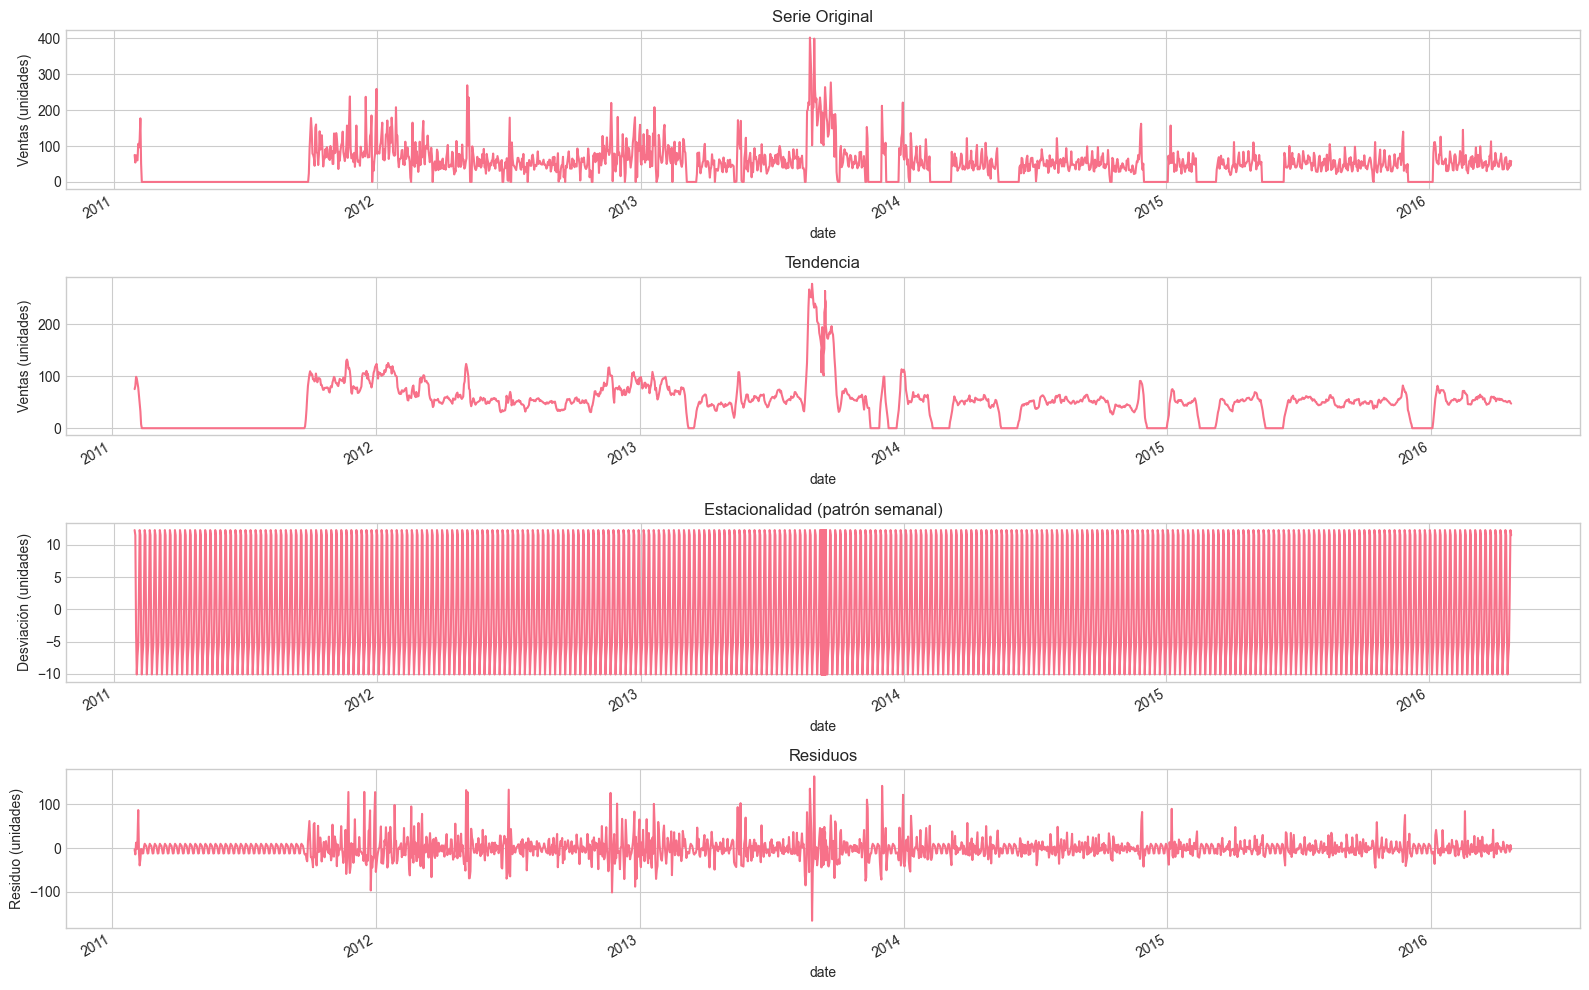

In [59]:
# Descomposición: tendencia + estacionalidad + ruido
decomposition = seasonal_decompose(item_ts.dropna(), model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))

# Serie original sin modificar
decomposition.observed.plot(ax=axes[0], title='Serie Original', ylabel='Ventas (unidades)')

# Media móvil suavizada, muestra la dirección general a largo plazo ignorando el ruido
decomposition.trend.plot(ax=axes[1], title='Tendencia', ylabel='Ventas (unidades)')

# Patrón que se repite cada 7 días, el mismo ciclo semanal extraído y repetido
decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad (patrón semanal)', ylabel='Desviación (unidades)')

# Lo que queda después de quitar tendencia y estacionalidad, es decir, eventos inesperados, anomalías
decomposition.resid.plot(ax=axes[3], title='Residuos', ylabel='Residuo (unidades)')

plt.tight_layout()
plt.show()

**Conclusiones:**<br>

*  **Serie Original:**
    *  *Hay dos períodos con ventas en 0 o muy bajas (inicio de 2011 y mediados de 2014):* el producto probablemente no estaba disponible o la tienda cerrada. Un pico muy alto alrededor de finales de 2013 (~400 unidades) que destaca sobre el resto de la serie.

*  **Tendencia:**
    *  Refleja bien los cambios a largo plazo. El pico de 2013 queda absorbido en la tendencia, lo que confirma que fue un período sostenido de alta demanda (no un día aislado). Después de 2014 la tendencia es claramente más baja y estable.

*  **Estacionalidad:**
    *  Oscilación regular y constante entre -10 y +10 que se repite cada 7 días durante toda la serie. Confirma que existe un patrón semanal real. La amplitud es pequeña (±10) comparada con los valores de la serie (0-400), lo que explica por qué no se veía claramente en el ACF, ya que queda enmascarada por la fuerte persistencia general.

*  **Residuos:**
    *  Mayoritariamente centrados en 0, lo que indica que el modelo de descomposición captura bien el comportamiento. Los picos grandes (±100) coinciden con el período de 2013-2014, y son anomalías que ni la tendencia ni la estacionalidad pueden explicar, posiblemente eventos especiales o promociones puntuales.

La serie tiene estacionalidad semanal confirmada (±10 unidades cada 7 días) aunque de amplitud modesta, una tendencia no estacionaria con un pico anómalo en 2013-2014, y residuos controlados salvo en ese período. Esto valida usar weekday_int, is_weekend y los lags de 7 días como features en el modelo, ya que el día de la semana influye directamente en las ventas y el ACF muestra correlación significativa hasta el lag 40 con decaimiento lento (el pasado lejano sigue siendo informativo).

In [60]:
# Test ADF (Augmented Dickey-Fuller) para saber si la serie es estacionaria o no
adf_result = adfuller(item_ts.dropna())
print(f"Test Dickey-Fuller (estacionariedad):")
print(f"   ADF Statistic: {adf_result[0]:.4f}")         # Valor numérico del test (cuanto más negativo, más evidencia de estacionariedad)
print(f"   p-value: {adf_result[1]:.4f}")       # Si p-value < 0.05 (serie estacionaria: serie tiende a volver a su media), p-value >= 0.05 (serie no estacionaria: la media y varianza cambian con el tiempo)
print(f"   Valores críticos:")
for key, value in adf_result[4].items():
    print(f"      {key}: {value:.4f}")
print(f"   Estacionaria: {'SÍ' if adf_result[1] < 0.05 else 'NO'}")

Test Dickey-Fuller (estacionariedad):
   ADF Statistic: -4.1545
   p-value: 0.0008
   Valores críticos:
      1%: -3.4337
      5%: -2.8630
      10%: -2.5676
   Estacionaria: SÍ


**Conclusiones:**<br>
*  *p-value = 0.0008:* está muy por debajo de 0.05 -> confirma que la serie es estacionaria con alta confianza.

*  *ADF = -4.1545:* es un valor muy negativo -> cuanto más negativo, más evidencia de estacionariedad y cuanto más se aleja hacia valores negativos del umbral crítico 1% (-3.43), más lejos está la serie del comportamiento no estacionario.

*  *La serie es estacionaria:* la media y varianza son suficientemente estables en el tiempo.

*  No se necesitan transformaciones adicionales como diferenciación o logaritmos antes de modelar, los valores de ventas pueden usarse directamente como target.

*  *Valida el split temporal:* si la serie fuera no estacionaria (tendencia creciente o decreciente), las distribuciones de train y test serían muy diferentes y el modelo aprendería patrones que no se repiten. Al ser estacionaria, lo que aprende en el pasado es transferible al futuro.

### 6.5 Análisis de Eventos

ANÁLISIS DEL IMPACTO DE EVENTOS EN VENTAS

   Ventas promedio en días SIN evento:  11,882.78
   Ventas promedio en días CON evento:  11,010.38
   Uplift por evento:      -7.34%

   Impacto por tipo de evento:
      Easter              :  13,354.40 (+12.38%)
      NewYear             :   8,675.87 (-26.99%)
      Ramadan starts      :  11,670.00 ( -1.79%)
      SuperBowl           :  13,707.56 (+15.36%)
      Thanksgiving        :   7,104.67 (-40.21%)


/var/folders/hj/mvzndrt11kbf9zpp2p80hjz80000gn/T/ipykernel_3467/42968792.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=event_types, patch_artist=True)


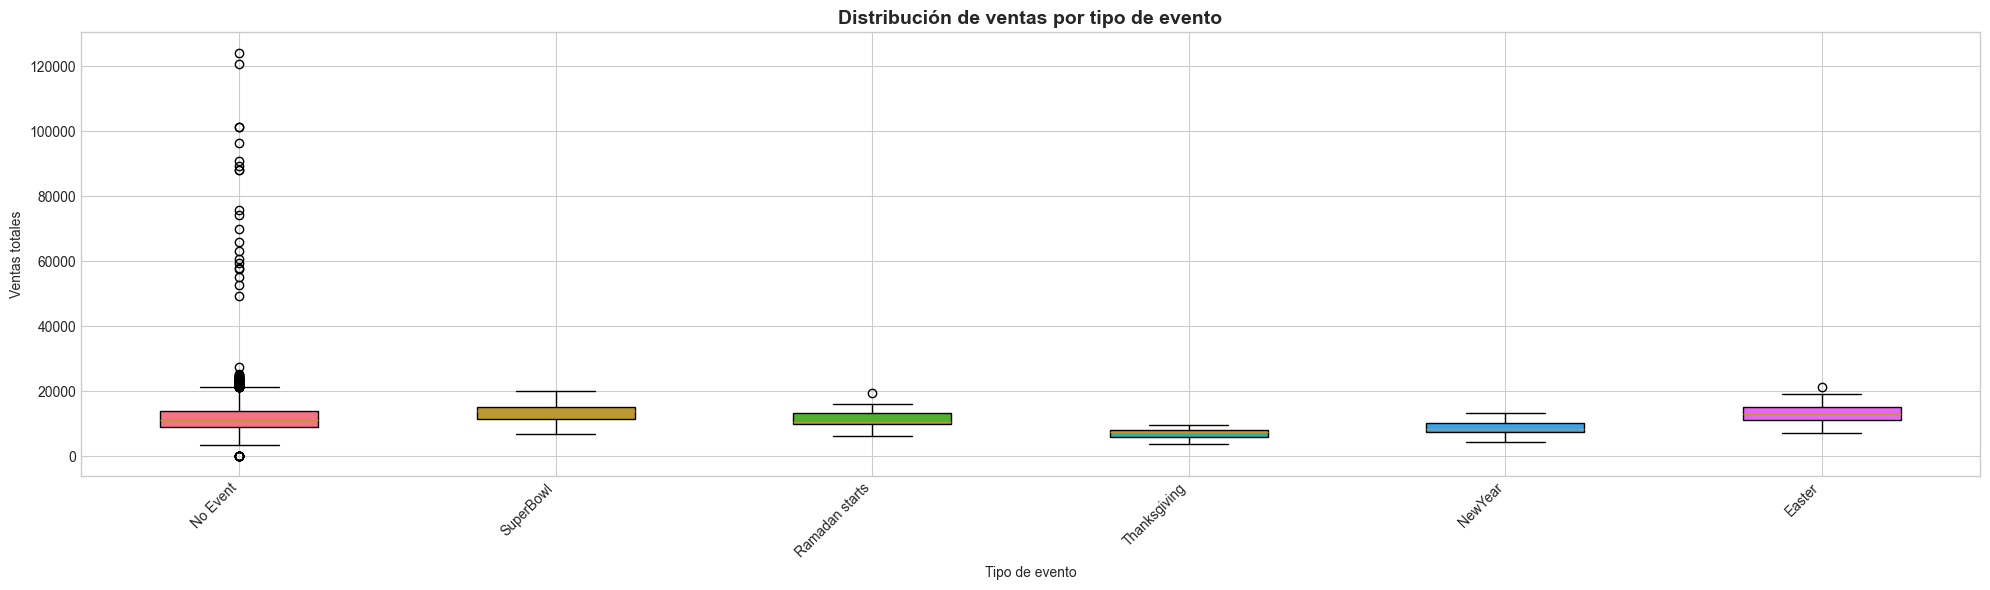

In [61]:
print("ANÁLISIS DEL IMPACTO DE EVENTOS EN VENTAS")
print("=" * 60)

df_city_daily_init = df_city_daily.copy()

# Add necessary columns if they do not exist
cols_to_add = list()
if 'is_event' not in df_city_daily_init.columns:
    cols_to_add.append('is_event')
if 'event' not in df_city_daily_init.columns:
    cols_to_add.append('event')

if cols_to_add:
    df_city_daily_init = df_city_daily_init.merge(
        df_calendar[['date'] + cols_to_add],
        on='date',
        how='left'
    )

# Sales on days with an event vs. without an event
ventas_con_evento = df_city_daily_init[df_city_daily_init['is_event'] == 1]['total_sales'].mean()
ventas_sin_evento = df_city_daily_init[df_city_daily_init['is_event'] == 0]['total_sales'].mean()

uplift = ((ventas_con_evento / ventas_sin_evento) - 1) * 100

print(f"\n   Ventas promedio en días SIN evento: {ventas_sin_evento:>10,.2f}")
print(f"   Ventas promedio en días CON evento: {ventas_con_evento:>10,.2f}")
print(f"   Uplift por evento: {uplift:>+10,.2f}%")

# By type of event
print("\n   Impacto por tipo de evento:")

eventos_unicos = df_calendar[df_calendar['event'].notna()]['event'].unique()

for evento in sorted(eventos_unicos):
    ventas_evento = df_city_daily_init[df_city_daily_init['event'] == evento]['total_sales'].mean()
    uplift_evento = ((ventas_evento / ventas_sin_evento) - 1) * 100
    print(f"      {evento:20s}: {ventas_evento:>10,.2f} ({uplift_evento:>+6.2f}%)")

# Box plot chart
df_eventos = df_city_daily.copy()
df_eventos['event_type'] = df_eventos['event'].fillna('No Event')

fig, ax = plt.subplots(figsize=(20, 6))

event_types = df_eventos['event_type'].unique()
data_to_plot = [df_eventos[df_eventos['event_type'] == et]['total_sales'].values for et in event_types]

bp = ax.boxplot(data_to_plot, labels=event_types, patch_artist=True)

colors = sns.color_palette("husl", len(event_types))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Tipo de evento')
ax.set_ylabel('Ventas totales')
ax.set_title('Distribución de ventas por tipo de evento', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusión:**  
*  **El SuperBowl** (+15.36%) y **Easter** (+12.38%) son periodos donde el consumo se dispara por encima de la media habitual.
*  **Thanksgiving** muestra una caída drástica (-40.21%), probablemente las tiendas cierran o reducen su horario drásticamente.
*  El boxplot de **No Event** muestra una cantidad ingente de outliers que superan las 120,000 unidades. Esto confirma que el gran pico de 2013 no estuvo ligado a un festivo tradicional, sino a una acción comercial interna (como la bajada de precios detectada anteriormente).

### 6.6 Análisis de Correlaciones

ANÁLISIS DE CORRELACIONES

   Dataset muy grande (60,004,842 filas). Usando muestra de 1M filas...

   Matriz de correlación:


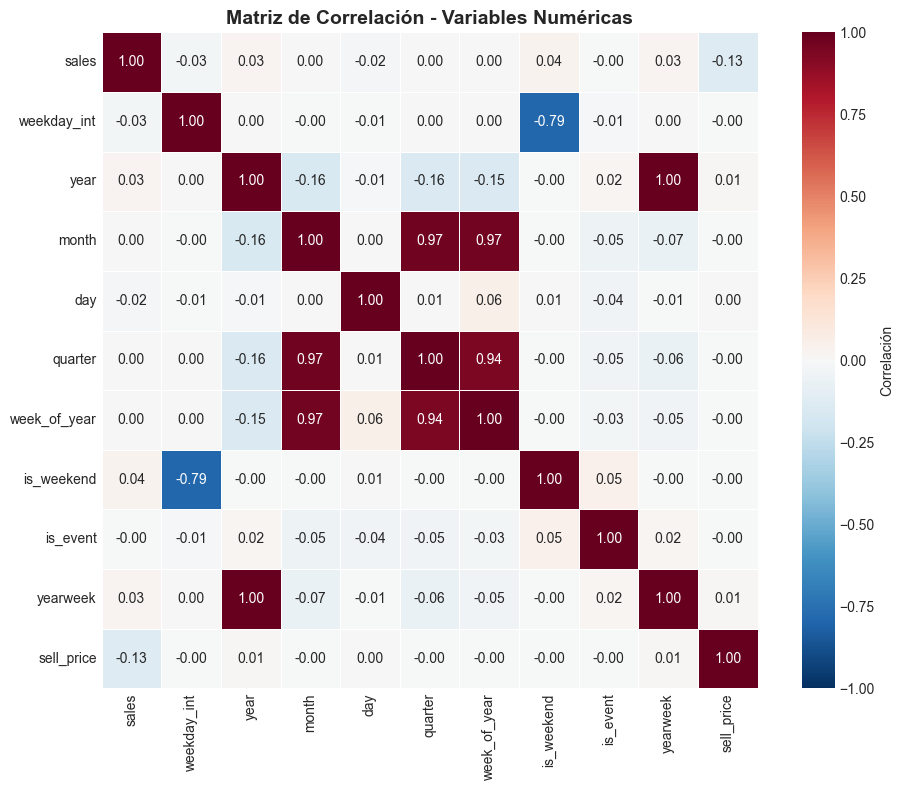


   Correlaciones con 'sales' (ordenadas por valor absoluto):
------------------------------------------------------------
   sell_price               : -0.1321
   is_weekend               : +0.0383
   yearweek                 : +0.0310
   year                     : +0.0307
   weekday_int              : -0.0287
   day                      : -0.0160
   month                    : +0.0022
   quarter                  : +0.0013
   is_event                 : -0.0011
   week_of_year             : +0.0005


In [62]:
print("ANÁLISIS DE CORRELACIONES")
print("=" * 60)

# Select only numeric columns from df_sales_long
numeric_cols = df_sales_long.select_dtypes(include=['number']).columns.tolist()

# Exclude columns that are not relevant to the correlation
cols_to_exclude = list()
numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude]

# Calculate correlation matrix. Use a sample if the dataset is very large (>1M rows)
if len(df_sales_long) > 1_000_000:
    print(f"\n   Dataset muy grande ({len(df_sales_long):,} filas). Usando muestra de 1M filas...")
    df_sample = df_sales_long[numeric_cols].sample(n=1_000_000, random_state=42)
else:
    df_sample = df_sales_long[numeric_cols]

corr_matrix = df_sample.corr()

print("\n   Matriz de correlación:")

# Graphic
plt.figure(figsize=(max(10, len(numeric_cols) * 0.7), max(8, len(numeric_cols) * 0.6)))

sns.heatmap(
    corr_matrix,
    annot=len(numeric_cols) <= 15,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones más fuertes con sales (si existe)
if 'sales' in corr_matrix.columns:
    print("\n   Correlaciones con 'sales' (ordenadas por valor absoluto):")
    print("-" * 60)
    sales_corr = corr_matrix['sales'].drop('sales').abs().sort_values(ascending=False)
    for var, corr in sales_corr.items():
        corr_real = corr_matrix.loc['sales', var]
        signo = "+" if corr_real > 0 else ""
        print(f"   {var:25s}: {signo}{corr_real:.4f}")

---

## 7. EXPORT FOR POWER BI

In [63]:
print("EXPORTANDO DATOS PARA POWER BI")
print("=" * 60)

# Calendar clean
df_calendar.to_csv(f'{PROCESSED_FILE_PATH}/calendar_clean.csv', index=False)
print("\n   Creado calendar_clean.csv")

# Prices clean
df_prices.to_csv(f'{PROCESSED_FILE_PATH}/prices_clean.csv', index=False)
print("   Creado prices_clean.csv")

# Agregados (más pequeños, útiles para análisis)
df_city_daily.to_csv(f'{PROCESSED_FILE_PATH}/city_daily_sales.csv', index=False)
print("   Creado city_daily_sales.csv")

df_store_daily.to_csv(f'{PROCESSED_FILE_PATH}/store_daily_sales.csv', index=False)
print("   Creado store_daily_sales.csv")

df_product_daily.to_csv(f'{PROCESSED_FILE_PATH}/product_daily_sales.csv', index=False)
print("   Creado product_daily_sales.csv")

# Sales long - Guardado en Parquet por ser más eficiente
df_sales_long.to_parquet(f'{PROCESSED_FILE_PATH}/sales_long.parquet', index=False)
print("   Creado sales_long.parquet")

print("\nTodos los datasets exportados!")

EXPORTANDO DATOS PARA POWER BI

   Creado calendar_clean.csv
   Creado prices_clean.csv
   Creado city_daily_sales.csv
   Creado store_daily_sales.csv
   Creado product_daily_sales.csv
   Creado sales_long.parquet

Todos los datasets exportados!


---

## 8. FEATURE ENGINEERING

### 8.1 Pipeline

Se definen los siguientes features:<br>
*  **Lag Features:** Son las ventas de días anteriores. Se usan para que el modelo aprenda patrones del pasado y pueda predecir el futuro. El [análisis ACF/PACF](#ACF_PACF_Desc) confirma qué lags son más relevantes:<br>

    *  *sales_lag_1:* El más importante ya que el ACF/PACF muestra una correlación de ~0.78 con el día anterior. "¿Cuánto vendí ayer?".

    *  *sales_lag_7:* Captura el patrón semanal, el mismo día de la semana pasada. "¿Cuánto vendí el lunes pasado?".

    *  *sales_lag_14:* Dos semanas atrás, refuerza el patrón semanal.

    *  *sales_lag_21:* Tres semanas atrás, ciclo de 3 semanas.

    *  *sales_lag_28:* Un mes atrás, captura estacionalidad mensual. "¿Cuánto vendí hace 4 semanas?"

    *  *Nota:* El PACF también muestra una pequeña contribución en lag 2 (~0.15). A partir del lag 3 los valores caen dentro de la banda de confianza, lo que indica que no aportan información directa adicional más allá de la que ya captura lag 1.

    La decaída lenta del ACF (todos los lags hasta 40 son significativos) confirma que la serie tiene mucha memoria y que los lags largos siguen aportando información relevante al modelo.

*  **Estadísticas móviles:** Los Rolling Features capturan la tendencia reciente de las ventas, no solo un día específico (el promedio es más estable y menos sensible a días atípicos).<br>

    *  *sales_rolling_mean_7/14/28 - Promedio móvil:* Capturar la tendencia reciente a diferentes escalas de tiempo ("¿Cuánto vendí en promedio la última semana o últimas 2 semanas o último mes?").

    *  *sales_rolling_std_7/14/28 - Desviación estándar móvil:* Detectar volatilidad. Un producto con ventas erráticas se comporta diferente a uno estable ("¿Qué tan variables/erráticas fueron las ventas esta semana?"). Productos con alta std tienen más incertidumbre.

    *  *sales_rolling_max/min_28 - Máximo y mínimo del mes:* Detectar el rango de ventas posibles, identificar si hubo picos (promociones, eventos) y saber el piso mínimo de demanda ("¿Cuál fue el pico máximo/mínimo de ventas este mes?").

*  **Features de precio:** Cada feature de precio captura información diferente sobre el comportamiento del precio y cómo puede afectar las ventas.  

    *  *price_lag_1 - Precio del día anterior:* El modelo puede detectar si un cambio de precio reciente afecta las ventas de hoy ("¿Cuánto costaba ayer?").

    *  *price_change - Cambio absoluto de precio:* Detectar si hubo una promoción (precio bajó) o aumento (precio subió).

    *  *price_change_pct - Cambio porcentual de precio:* Un descuento del 20% impacta más que uno de 10%. El porcentaje es más informativo que el valor absoluto.

    *  *price_rolling_mean_4w - Precio promedio últimas 4 semanas:* Establecer una línea base del precio histórico ("¿Cuál es el precio 'normal' de este producto?").

    *  *price_ratio_vs_avg - Ratio precio actual vs promedio:* Conocer si el precio actual está en promoción (ratio < 1) o **inflado** (ratio > 1).

*  **Features agregadas:** Dan al modelo información sobre el comportamiento histórico promedio de cada producto/tienda/categoría/ciudad.

| Feature | Información que aporta |
| :--- | :--- |
| item_avg_sales | Nivel de demanda del producto (promedio de ventas diarias de los productos) |
| store_avg_sales | Volumen de la tienda (promedio de ventas totales diarias de las tienda) |
| category_avg_sales | Popularidad de la categoría (promedio de las categoría) |
| city_avg_sales | Tamaño del mercado de la ciudad (promedio de las ciudades) |

*  **Features de encoding:** Las columnas de encoding que se crean son:

    *  *item_encoded:* Codificación numérica del producto.

    *  *category_encoded:* Codificación numérica de la categoría.

    *  *department_encoded:* Codificación numérica del departamento.

    *  *store_encoded:* Codificación numérica de la tienda.

    *  *store_code_encoded:* Codificación numérica del código de la tienda.

    *  *city_encoded:* Codificación numérica de la ciudad.

In [64]:
print("CREANDO FEATURES ENGINEERING CON PIPELINE")
print("=" * 60)

categorical_cols = ['item', 'category', 'department', 'store', 'store_code', 'city']

feature_engineering_pipeline = Pipeline(
    steps=[
        ('lag_features', FunctionTransformer(create_lag_features)),
        ('rolling_features', FunctionTransformer(create_rolling_features)),
        ('price_features', FunctionTransformer(create_price_features)),
        ('aggregate_features', FunctionTransformer(create_aggregate_features)),
        ('encoding_features', FunctionTransformer(func=create_encoding_features, kw_args={"categorical_cols": categorical_cols}))
    ]
)

df_sales_long = feature_engineering_pipeline.fit_transform(df_sales_long)

print(f"Feature Engineering completado con Pipeline!\nNuevas dimensiones: {df_sales_long.shape}")

CREANDO FEATURES ENGINEERING CON PIPELINE
Feature Engineering completado con Pipeline!
Nuevas dimensiones: (60004842, 48)


### 8.2 Definición de features para el modelo

In [65]:
print("DEFINICIÓN DE FEATURES PARA EL MODELO")
print("=" * 60)

FEATURES = [
    # Temporary
    'weekday_int', 'month', 'day', 'quarter', 'week_of_year', 'year', 'is_weekend', 'is_event',

    # Lag features
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28',

    # Rolling features
    'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_28',
    'sales_rolling_std_7', 'sales_rolling_std_14', 'sales_rolling_std_28',
    'sales_rolling_max_28', 'sales_rolling_min_28',

    # Price features
    'sell_price', 'price_lag_1', 'price_change', 'price_change_pct',
    'price_rolling_mean_4w', 'price_ratio_vs_avg',

    # Encoding features
    'item_encoded', 'category_encoded', 'department_encoded',
    'store_encoded', 'store_code_encoded', 'city_encoded',

    # Aggregate features
    'item_avg_sales', 'store_avg_sales', 'category_avg_sales', 'city_avg_sales'
]

# Filter only features that exist
FEATURES = [f for f in FEATURES if f in df_sales_long.columns]

TARGET = 'sales'

print(f"\n   Features para el modelo ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"      {i:2d}. {f}")

print(f"\n   Target: {TARGET}")

DEFINICIÓN DE FEATURES PARA EL MODELO

   Features para el modelo (37):
       1. weekday_int
       2. month
       3. day
       4. quarter
       5. week_of_year
       6. year
       7. is_weekend
       8. is_event
       9. sales_lag_1
      10. sales_lag_7
      11. sales_lag_14
      12. sales_lag_21
      13. sales_lag_28
      14. sales_rolling_mean_7
      15. sales_rolling_mean_14
      16. sales_rolling_mean_28
      17. sales_rolling_std_7
      18. sales_rolling_std_14
      19. sales_rolling_std_28
      20. sales_rolling_max_28
      21. sales_rolling_min_28
      22. sell_price
      23. price_lag_1
      24. price_change
      25. price_change_pct
      26. price_rolling_mean_4w
      27. price_ratio_vs_avg
      28. item_encoded
      29. category_encoded
      30. department_encoded
      31. store_encoded
      32. store_code_encoded
      33. city_encoded
      34. item_avg_sales
      35. store_avg_sales
      36. category_avg_sales
      37. city_avg_sales

   

### 8.3 Split temporal (train/test/validation)

In [66]:
print("SPLIT TEMPORAL DE DATOS")
print("=" * 60)

# Temporary split, NOT random
fecha_max = df_sales_long['date'].max()
fecha_min = df_sales_long['date'].min()

print(f"\n   Rango de fechas: {fecha_min.strftime('%Y-%m-%d')} a {fecha_max.strftime('%Y-%m-%d')}")

# Cut points
validation_start = fecha_max - pd.Timedelta(days=27)   # Last 28 days
test_start = validation_start - pd.Timedelta(days=28)   # 28 days before the test

print(f"\n   Puntos de corte:")
print(f"      Train: {fecha_min.strftime('%Y-%m-%d')} a {(test_start - pd.Timedelta(days=1)).strftime('%Y-%m-%d')}")
print(f"      Test: {test_start.strftime('%Y-%m-%d')} a {(validation_start - pd.Timedelta(days=1)).strftime('%Y-%m-%d')}")
print(f"      Validation: {validation_start.strftime('%Y-%m-%d')} a {fecha_max.strftime('%Y-%m-%d')}")

# Create splits
df_train = df_sales_long[df_sales_long['date'] < test_start].copy()
df_test = df_sales_long[(df_sales_long['date'] >= test_start) & (df_sales_long['date'] < validation_start)]
df_validation = df_sales_long[df_sales_long['date'] >= validation_start].copy()

print(f"\n   Tamaños (antes de eliminar nulos):")
print(f"      Train: {len(df_train):,} filas ({len(df_train) / len(df_sales_long) * 100:.1f}%)")
print(f"      Test: {len(df_test):,} filas ({len(df_test) / len(df_sales_long) * 100:.1f}%)")
print(f"      Validation: {len(df_validation):,} filas ({len(df_validation) / len(df_sales_long) * 100:.1f}%)")

# Remove rows with nulls in features (first days without history)
print(f"\n   Eliminando filas con nulos en features...")
df_train = df_train.dropna(subset=FEATURES)
df_test = df_test.dropna(subset=FEATURES)
df_validation = df_validation.dropna(subset=FEATURES)

print(f"\n   Tamaños (después de eliminar nulos):")
print(f"      Train: {len(df_train):,} filas")
print(f"      Test: {len(df_test):,} filas")
print(f"      Validation: {len(df_validation):,} filas")

# Prepare X and Y
X_train = df_train[FEATURES]
y_train = df_train[TARGET]

X_test = df_test[FEATURES]
y_test = df_test[TARGET]

X_validation = df_validation[FEATURES]
y_validation = df_validation[TARGET]

print(f"\n   Datasets preparados para entrenamiento!")
print(f"      X_train shape: {X_train.shape}")
print(f"      X_test shape: {X_test.shape}")
print(f"      X_validation shape: {X_validation.shape}")

SPLIT TEMPORAL DE DATOS

   Rango de fechas: 2011-01-29 a 2016-04-24

   Puntos de corte:
      Train: 2011-01-29 a 2016-02-28
      Test: 2016-02-29 a 2016-03-27
      Validation: 2016-03-28 a 2016-04-24

   Tamaños (antes de eliminar nulos):
      Train: 58,296,506 filas (97.2%)
      Test: 854,616 filas (1.4%)
      Validation: 853,720 filas (1.4%)

   Eliminando filas con nulos en features...

   Tamaños (después de eliminar nulos):
      Train: 57,442,786 filas
      Test: 854,616 filas
      Validation: 853,720 filas

   Datasets preparados para entrenamiento!
      X_train shape: (57442786, 37)
      X_test shape: (854616, 37)
      X_validation shape: (853720, 37)


### 8.4 Verificación de features

In [67]:
print("VERIFICACIÓN DE FEATURES")
print("=" * 60)

print(f"\n   Total columnas en df_sales_long: {len(df_sales_long.columns)}")

# Check for nulls in features
print("\n   Valores nulos por feature (en df_sales_long completo):")
null_counts = df_sales_long[FEATURES].isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
if len(null_counts) > 0:
    print(null_counts)
else:
    print("      No hay nulos en las features seleccionadas")

print("\n   Tipos de datos de las features:")
print(df_sales_long[FEATURES].dtypes)

VERIFICACIÓN DE FEATURES

   Total columnas en df_sales_long: 48

   Valores nulos por feature (en df_sales_long completo):
sales_lag_28             853720
sales_lag_21             640290
sales_lag_14             426860
sales_lag_7              213430
sales_rolling_std_7       60980
sales_rolling_std_14      60980
sales_rolling_std_28      60980
sales_lag_1               30490
sales_rolling_mean_28     30490
sales_rolling_mean_7      30490
sales_rolling_mean_14     30490
sales_rolling_max_28      30490
sales_rolling_min_28      30490
price_lag_1               30490
price_change              30490
price_change_pct          30490
price_rolling_mean_4w     30490
price_ratio_vs_avg        30490
dtype: int64

   Tipos de datos de las features:
weekday_int                int64
month                      int32
day                        int32
quarter                    int32
week_of_year               int64
year                       int32
is_weekend                 int64
is_event            

---

## 9. EXPORT FOR ML

In [68]:
print("EXPORTANDO DATOS PARA EL MODELO")
print("=" * 60)

# Dataset completo con features
df_sales_long.to_parquet(f'{PROCESSED_FILE_PATH}/sales_features.parquet', index=False)
print("\n   Creado sales_features.parquet")

# Sets de train, test y validation
df_train.to_parquet(f'{PROCESSED_FILE_PATH}/train_set.parquet', index=False)
print("   Creado train_set.parquet")

df_test.to_parquet(f'{PROCESSED_FILE_PATH}/test_set.parquet', index=False)
print("   Creado test_set.parquet")

df_validation.to_parquet(f'{PROCESSED_FILE_PATH}/validation_set.parquet', index=False)
print("   Creado validation_set.parquet")

# Lista de features, se almacena porque al cargar el modelo guardado (best_model.pkl) sin ejecutar el notebook,
# se sepa exactamente qué columnas pasarle y en qué orden
with open(f'{FEATURES_PATH}/feature_list.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET}, f, indent=2)
print("   Creado feature_list.json")

EXPORTANDO DATOS PARA EL MODELO

   Creado sales_features.parquet
   Creado train_set.parquet
   Creado test_set.parquet
   Creado validation_set.parquet
   Creado feature_list.json


---

## 10. CLUSTERING

Se procede a agrupar los 3,049 productos en clusters (grupos con comportamiento similar).Ejemplo:<br>
*  Cluster A = productos estrella (venden mucho, precio alto).
*  Cluster B = productos estacionales (venden más en Navidad).

Joelle (Marketing) puede hacer campañas diferentes por cluster en lugar de tratar todos los productos igual.


### 10.1 Clustering por Producto

#### 10.1.1 Features por producto para clustering

Los tres son ratios y tienen un propósito común: capturar el comportamiento del producto independientemente de su volumen de ventas.<br>
*  *cv_sales — Coeficiente de Variación:* Mide qué tan errática o estable es la demanda de un producto, relativo a su propio promedio.<br>

| Producto | avg_sales | std_sales | cv_sales | Interpretación |
| :--- | :--- | :--- | :--- | :--- |
| Leche | 100 | 5 | 0.05 | Muy estable -> fácil de predecir │
| Decoración navideña | 10 | 18 | 1.80 | Muy errática -> difícil de predecir |

*  *weekend_boost — Sensibilidad al fin de semana:* Mide cuánto más vende un producto en fin de semana vs días laborables.<br>

| Producto | weekday | weekend | weekend_boost | Interpretación |
| :--- | :--- | :--- | :--- | :--- |
| Cerveza | 20 | 60 | 3.0 | Vende 3× más en fin de semana │
| Arroz | 50 | 55 | 1.1 | Indiferente al día |

*  *event_sensitivity — Sensibilidad a eventos:* Mide cuánto afectan los eventos especiales (Black Friday, Navidad...) a las ventas del producto.<br>

| Producto | event | no_event | event_sensitivity | Interpretación |
| :--- | :--- | :--- | :--- | :--- |
| Juguetes | 40 | 5 | 8.0 | Muy sensible a eventos │
| Pan | 85 | 80 | 1.06 | Indiferente a eventos |

Con estos ratios, KMeans puede encontrar clusters con significado real de negocio:

*  Cluster A -> cv_sales bajo + weekend_boost alto -> productos estables que se disparan en fin de semana.
*  Cluster B -> cv_sales alto + event_sensitivity alto -> productos erráticos impulsados por eventos.
*  Cluster C -> cv_sales bajo + ratios ~1.0 -> productos de consumo diario estable.

In [69]:
print("FEATURES POR PRODUCTO PARA CLUSTERING")
print("=" * 60)

# Aprovechamos columnas ya calculadas en la sección FE + groupby para las que faltan
product_features = df_sales_long.groupby('item').agg(
    # Columnas que ya existen tras FE
    avg_daily_sales=('item_avg_sales', 'first'),        # Selecciona el primer valor (son constantes por item)
    avg_price=('sell_price', 'mean'),                   # Precio promedio
    std_price=('sell_price', 'std'),                    # Variabilidad de precio
    num_stores=('store', 'nunique'),                    # Tiendas donde se vende

    # Columnas base que siempre han existido
    total_sales=('sales', 'sum'),
    std_daily_sales=('sales', 'std'),

    # Ratio ventas fin de semana vs días laborables
    weekend_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_weekend'] == 1].mean()),
    weekday_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_weekend'] == 0].mean()),

    # Sensibilidad a eventos
    event_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_event'] == 1].mean()),
    no_event_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_event'] == 0].mean()),

    # Categoría del producto
    category=('category', 'first')
).reset_index()

# Calcular ratios
product_features['cv_sales'] = (
    product_features['std_daily_sales'] / product_features['avg_daily_sales']
)
product_features['weekend_boost'] = (
    product_features['weekend_sales'] / product_features['weekday_sales'].replace(0, np.nan)
)
product_features['event_sensitivity'] = (
    product_features['event_sales'] / product_features['no_event_sales'].replace(0, np.nan)
)

# Rellenar posibles nulos
product_features = product_features.fillna(0)

print(f"Features de productos creadas: {product_features.shape}")
print(f"Columnas: {product_features.columns.tolist()}")

FEATURES POR PRODUCTO PARA CLUSTERING
Features de productos creadas: (3049, 15)
Columnas: ['item', 'avg_daily_sales', 'avg_price', 'std_price', 'num_stores', 'total_sales', 'std_daily_sales', 'weekend_sales', 'weekday_sales', 'event_sales', 'no_event_sales', 'category', 'cv_sales', 'weekend_boost', 'event_sensitivity']


In [70]:
# Normalizar
feature_cols_prod = [
    'avg_daily_sales', 'cv_sales', 'avg_price', 'std_price',
    'weekend_boost', 'event_sensitivity'
]

scaler_prod = StandardScaler()
X_prod_cluster = scaler_prod.fit_transform(product_features[feature_cols_prod])

#### 10.1.2 K-Means con k=5, 10, 20

In [71]:
print("KMEANS -> K= 5, 10, 20")
print("=" * 60)

clustering_results = run_kmeans_clustering(
    X=X_prod_cluster,
    k_values=[5, 10, 20],
    entity_name='Productos'
)

KMEANS -> K= 5, 10, 20
Productos k= 5 -> Silhouette: 0.2249 | Inertia: 10420
Productos k=10 -> Silhouette: 0.1628 | Inertia: 7380
Productos k=20 -> Silhouette: 0.1624 | Inertia: 4969


**Conclusiones:**<br>
| k | Silhouette | Inertia | Interpretación |
| :--- | :--- | :--- | :--- |
| 5 | 0.2249 | 10420 | Mejor separación, pero pocos grupos │
| 10 | 0.1628 | 7380 | Separación peor, más granularidad |
| 20 | 0.1624 | 4969 | Casi igual que k=10, mucho más complejo |

*  Los scores por debajo de 0.25 indican que los productos no forman grupos naturales muy diferenciados — tienen comportamientos bastante parecidos entre sí.
*  **k=5** tiene el mejor resultado por Silhouette (0.2249 vs 0.16 del resto).
*  Pasar de **k=10** a **k=20** casi no mejora la separación (0.1628 vs 0.1624), pero duplica la complejidad.
*  **k=5** tiene mejor calidad de clusters y más interpretable para Marketing.

#### 10.1.3 Evaluación: Elbow Method + Silhouette

ELBOW METHOD + SILHOUETTE EVALUACIÓN


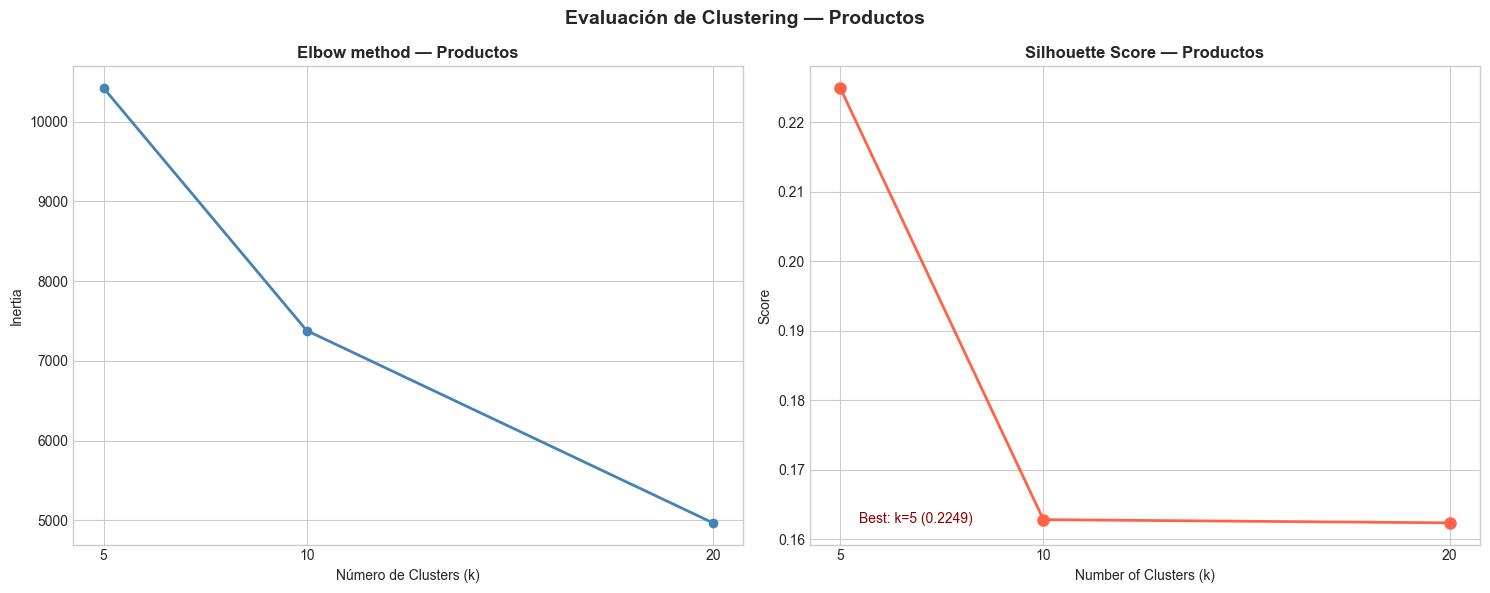

In [72]:
print("ELBOW METHOD + SILHOUETTE EVALUACIÓN")
print("=" * 60)

k_optimal_prod = plot_clustering_evaluation(
    k_values=[5, 10, 20],
    clustering_results=clustering_results,
    entity_name='Productos'
)

#### 10.1.4 Análisis del cluster óptimo

ANÁLIS DEL CLUSTER ÓPTIMO

PERFIL DE CLUSTERS (k=5):
cluster              0    1    2     3     4
avg_daily_sales   0.43 1.34 0.23  0.47 11.84
cv_sales          2.79 1.73 3.53  2.48  1.18
avg_price         6.51 3.87 4.77 14.76  1.81
std_price         0.19 0.16 0.13  0.81  0.09
weekend_boost     1.45 1.31 1.23  1.29  1.32
event_sensitivity 1.13 0.87 0.79  0.90  1.00


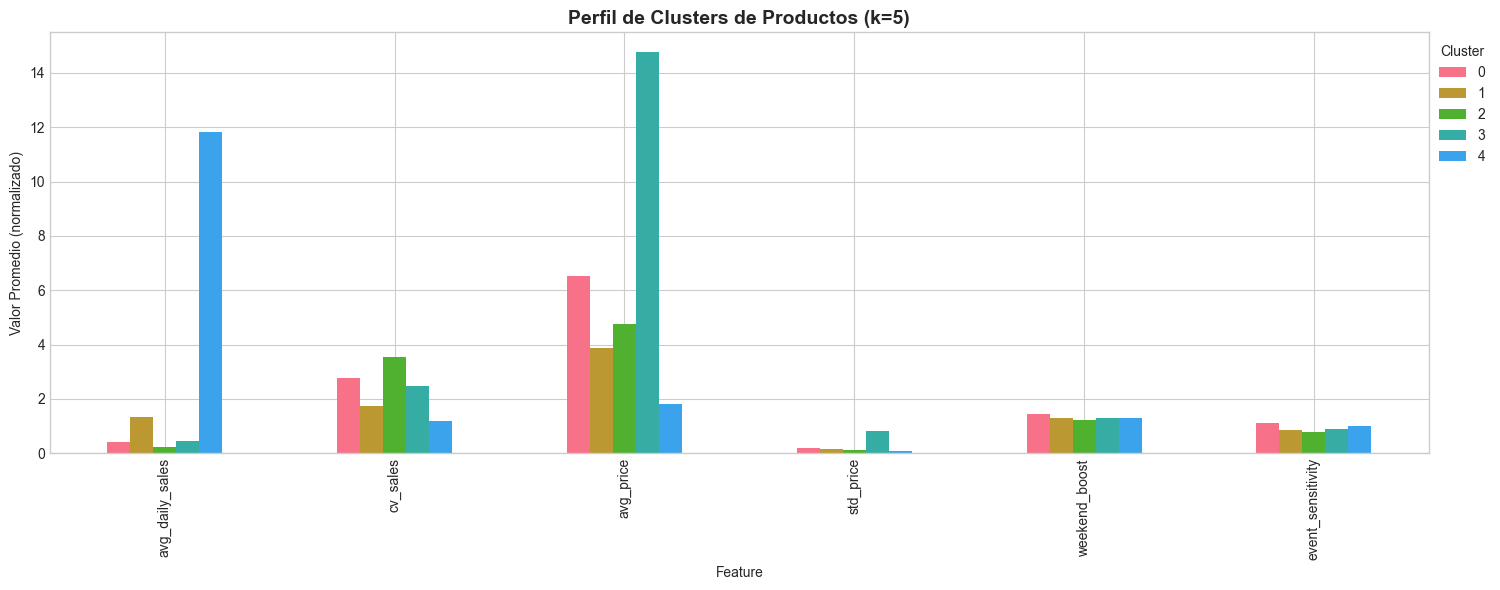


Category predominante por cluster:
category  ACCESORIES  HOME_&_GARDEN  SUPERMARKET
cluster                                         
0                125            316          174
1                165            439          933
2                171            178          179
3                104            107           84
4                  0              7           67


In [73]:
print("ANÁLIS DEL CLUSTER ÓPTIMO")
print("=" * 60)

profiles = analyze_cluster_profiles(
    product_feat=product_features,
    clustering_results=clustering_results,
    k_optimal=k_optimal_prod,
    feature_cols=feature_cols_prod,
    group_col='category',
    entity_name='Productos'
)

**Conclusiones:**<br>
*  *Cluster 0 — "Productos de fin de semana":* Productos que la gente compra el fin de semana (herramientas, decoración, jardín).
    *  avg_daily_sales: 0.43
    *  cv_sales: 2.79 (alta variabilidad).
    *  weekend_boost: 1.45 (el mayor de todos los cluster = 45% más ventas en fin de semana).
    *  event_sensitivity: 1.13 (también suben en eventos).
    *  Categoría: HOME_&_GARDEN dominante (52%).

*  *Cluster 1 — "Productos regulares de supermercado":* Productos de consumo habitual pero no básicos. Bajan en eventos, posiblemente el cliente en días de evento prioriza otras categorías.
    *  avg_daily_sales: 1.34 (ventas medias).
    *  cv_sales: 1.73 (variabilidad media).
    *  avg_price: 3.87 (precio bajo-medio).
    *  event_sensitivity: 0.87 (venden menos en días de evento).
    *  Categoría: SUPERMARKET dominante (61%).

*  *Cluster 2 — "Productos de demanda intermitente":* Productos con muy poca demanda y sin ningún patrón claro. A revisar si deben seguir en el catálogo.
    *  avg_daily_sales: 0.23 (los que menos venden, casi nada).
    *  cv_sales: 3.53 (los más erráticos).
    *  weekend_boost: 1.23 (menor efecto de fin de semana).
    *  event_sensitivity: 0.79 (los eventos tampoco benefician).
    *  Categoría: perfectamente equilibrado entre las 3.

*  *Cluster 3 — "Productos premium / promocionales":* Productos caros con precios inestables, sufren muchas promociones que provocan picos de ventas erráticos.
    *  avg_price: 14.76 (el más caro con diferencia).
    *  cv_sales: 2.48 (alta variabilidad).
    *  std_price: 0.81 (el más variable, muchos descuentos).
    *  Categoría: mix equilibrado de las 3.

*  *Cluster 4 — "Productos estrella":* Productos básicos de supermercado. Alta rotación, precio bajo, demanda estable.
    *  avg_daily_sales: 11.84 (el más alto con diferencia, 10x vs el resto).
    *  cv_sales: 1.18 (el más estable, demanda predecible).
    *  avg_price: 1.81 (el más barato).
    *  event_sensitivity: 1.00 (indiferente a eventos).
    *  Categoría: 93% SUPERMARKET.

Resumen para Marketing (Joelle):<br>

| Cluster | Nombre | Estrategia sugerida |
| :--- | :--- | :--- |
| 0 | Fin de semana | Reforzar stock Jueves-Viernes |
| 1 | Regular | Gestión estándar, vigilar días de evento |
| 2 | Poca demanda | Revisar rentabilidad, posible descatalogación |
| 3 | Premium/Promo | Coordinar descuentos con proveedor |
| 4 | Estrella | Mantener stock siempre, promociones innecesarias |

### 10.2 Clustering por Tiendas

#### 10.2.1 Features por tiendas para clustering

In [74]:
store_features = df_sales_long.groupby('store').agg(
    total_sales=('sales', 'sum'),
    avg_daily_sales=('store_avg_sales', 'first'),
    std_daily_sales=('sales', 'std'),
    avg_price=('sell_price', 'mean'),
    product_diversity=('item', 'nunique'),
    city=('city', 'first'),
    weekend_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_weekend'] == 1].mean()),
    weekday_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_weekend'] == 0].mean()),
    event_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_event'] == 1].mean()),
    no_event_sales=('sales', lambda x: x[df_sales_long.loc[x.index, 'is_event'] == 0].mean()),
).reset_index()

# Calcular ratios
store_features['cv_sales'] = (
    store_features['std_daily_sales'] / store_features['avg_daily_sales']
)
store_features['weekend_boost'] = (
    store_features['weekend_sales'] / store_features['weekday_sales'].replace(0, np.nan)
)
store_features['event_sensitivity'] = (
    store_features['event_sales'] / store_features['no_event_sales'].replace(0, np.nan)
)

# Rellenar posibles nulos
store_features = store_features.fillna(0)

print(f"Features de tiendas creadas: {store_features.shape}")
print(f"Columnas: {store_features.columns.tolist()}")

Features de tiendas creadas: (10, 14)
Columnas: ['store', 'total_sales', 'avg_daily_sales', 'std_daily_sales', 'avg_price', 'product_diversity', 'city', 'weekend_sales', 'weekday_sales', 'event_sales', 'no_event_sales', 'cv_sales', 'weekend_boost', 'event_sensitivity']


In [75]:
feature_cols_store = [
    'avg_daily_sales', 'cv_sales', 'avg_price',
    'weekend_boost', 'event_sensitivity'
]

scaler_store = StandardScaler()
X_store_cluster = scaler_store.fit_transform(store_features[feature_cols_store])

#### 10.2.2 K-Means con k=2, 3, 5

Ya que el dataset tiene exactamente 10 tiendas, y no puede tener más clusters que datos, k <= número de tiendas / 2.<br>
Con 10 tiendas: k=2 (5 tiendas por cluster), k=3 (3 tiendas por cluster), k=5 (2 tiendas por cluster)

In [76]:
print("KMEANS -> K= 2, 3, 5")
print("=" * 60)

clustering_results_store = run_kmeans_clustering(
    X=X_store_cluster,
    k_values=[2, 3, 5],
    entity_name='Tiendas'
)

KMEANS -> K= 2, 3, 5
Tiendas k= 2 -> Silhouette: 0.2660 | Inertia: 31
Tiendas k= 3 -> Silhouette: 0.2928 | Inertia: 21
Tiendas k= 5 -> Silhouette: 0.2556 | Inertia: 9


**Conclusiones:**<br>
| k | Silhouette | Inertia | Interpretación |
| :--- | :--- | :--- | :--- |
| 2 | 0.2660 | 31 | Mejor separación, pero pocos grupos │
| 3 | 0.2928 | 21 | Separación peor, más granularidad |
| 5 | 0.2556 | 9 | Casi igual que k=10, mucho más complejo |

*  Los scores entre 0.25 y 0.30 indican que las tiendas tienen diferencias comportamentales sutiles, esto es lógico al ser todas de la misma cadena y vender los mismos productos.
*  **k=3** tiene el mejor resultado por Silhouette (0.2928 vs 0.2660 y 0.2556 del resto).
*  Pasar de **k=3** a **k=5** empeora la separación (0.2928 -> 0.2556) pese a reducir la inertia, lo que significa que más clusters no implica mejor clustering.
*  **k=3** coincide con el número de ciudades del dataset (*New York*, *Boston*, *Philadelphia*), lo que sugiere que el comportamiento de ventas está principalmente determinado por la ciudad, no por la tienda individual.

#### 10.2.3 Evaluación: Elbow Method + Silhouette

ELBOW METHOD + SILHOUETTE EVALUACIÓN


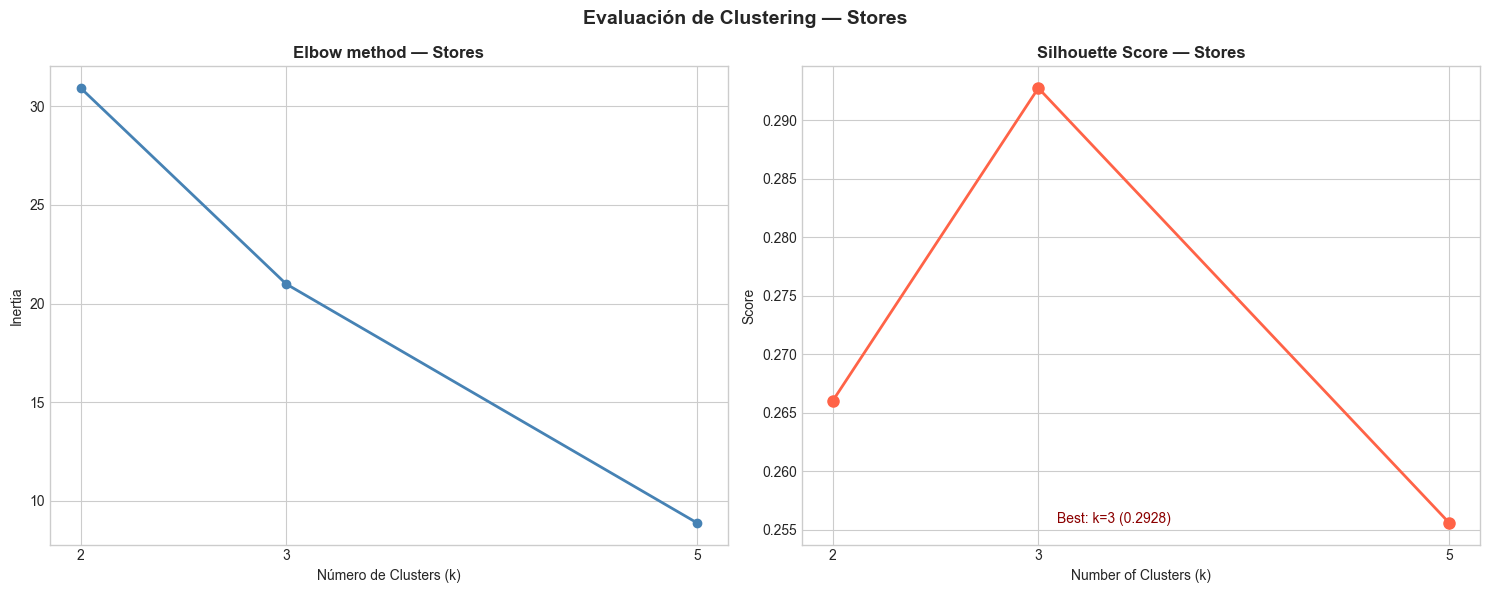

In [77]:
print("ELBOW METHOD + SILHOUETTE EVALUACIÓN")
print("=" * 60)

k_optimal_store = plot_clustering_evaluation(
    k_values=[2, 3, 5],
    clustering_results=clustering_results_store,
    entity_name='Stores'
)

#### 10.2.4 Análisis del cluster óptimo

ANÁLIS DEL CLUSTER ÓPTIMO

PERFIL DE CLUSTERS (k=3):
cluster              0    1    2
avg_daily_sales   0.92 1.26 1.07
cv_sales          3.15 3.56 2.88
avg_price         5.59 5.54 5.58
weekend_boost     1.18 1.29 1.44
event_sensitivity 0.87 0.99 0.91


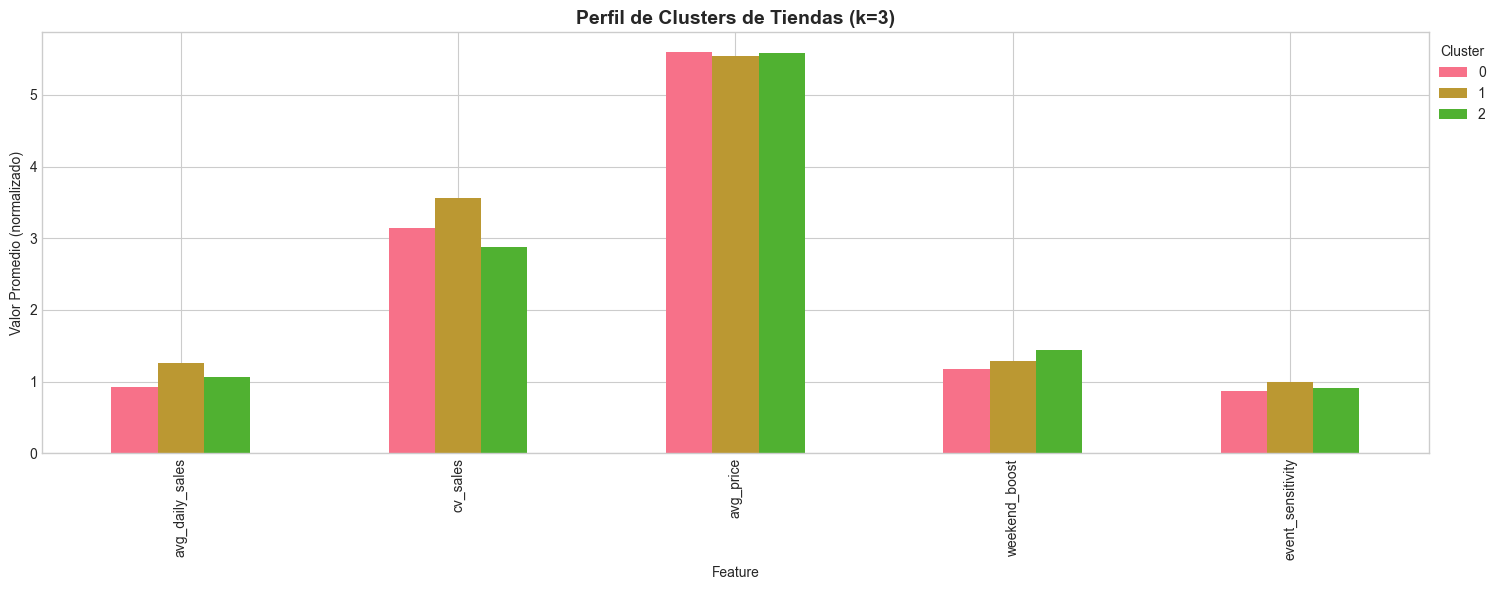


City predominante por cluster:
city     Boston  New York  Philadelphia
cluster                                
0             0         1             1
1             3         1             1
2             0         2             1


In [78]:
print("ANÁLIS DEL CLUSTER ÓPTIMO")
print("=" * 60)

store_profiles = analyze_cluster_profiles(
    product_feat=store_features,
    clustering_results=clustering_results_store,
    k_optimal=k_optimal_store,
    feature_cols=feature_cols_store,
    group_col='city',
    entity_name='Tiendas'
)

**Conclusiones:**<br>
*  *Cluster 0 — "Tiendas de baja actividad":* Tiendas con menor volumen de ventas y poco sensibles tanto a fines de semana como a eventos.
    *  avg_daily_sales: 0.92 (el más bajo).
    *  weekend_boost: 1.18 (el menor de todos = solo un 18% más en fin de semana).
    *  event_sensitivity: 0.87 (el menor de todos = los eventos reducen sus ventas).
    *  Ciudad: mix entre New York (50%) y Philadelphia (50%).

* *Cluster 1 — "Tiendas de alto volumen":* Tiendas con las mayores ventas diarias pero también las más erráticas. Son casi exclusivamente tiendas de Boston.
    *  avg_daily_sales: 1.26 (el más alto).
    *  cv_sales: 3.56 (el más errático = demanda difícil de predecir).
    *  event_sensitivity: 0.99 (prácticamente neutras a eventos).
    *  Ciudad: Boston dominante (60%, como deducción, las 3 tiendas de Boston están aquí).

* *Cluster 2 — "Tiendas de fin de semana":* Tiendas con el mayor efecto de fin de semana y la demanda más estable durante la semana. Predominantemente tiendas de New York.
    *  avg_daily_sales: 1.07 (ventas medias).
    *  cv_sales: 2.88 (el más estable de los 3 clusters).
    *  weekend_boost: 1.44 (el mayor = 44% más ventas en fin de semana).
    *  Ciudad: New York dominante (67%, como deducción, 2 de las 4 tiendas de New York).

**Nota sobre avg_price:** Prácticamente constante en los 3 clusters (5.54 – 5.59). El precio medio no diferencia el comportamiento entre tiendas, en conclusión, todas venden a precios similares.

Resumen para Marketing (Joelle):<br>

| Cluster | Nombre | Estrategia sugerida |
| :--- | :--- | :--- |
| 0 | Baja actividad | Revisar surtido, posible reducción de stock |
| 1 | Alto volumen | Priorizar reposición, gestionar variabilidad |
| 2 | Fin de semana | Reforzar stock Jueves-Viernes, especialmente New York |

---

## 11. ENTRENAMIENTO DEL MODELO

### 11.1 Baseline Model

Inicialmente se necesita un punto de referencia mínimo para saber si el modelo de Machine Learning que se entrenará podrá aportar valor real. Para ello se definen un modelo de referencia o "Baseline Model".

In [79]:
print("CREANDO EL BASELINE MODEL")
print("=" * 60)

y_baseline = df_test['sales_rolling_mean_28'].fillna(0)
y_true = df_test[TARGET]

results = dict()

# Guardar métricas del Baseline
results['Baseline (MA28)'] = evaluate_model(y_true, y_baseline, 'Baseline (MA28)')

CREANDO EL BASELINE MODEL
Baseline (MA28)
   RMSE: 2.1847
   MAE: 1.0048
   MAPE: 58.74%


**Conclusión:**

*  **RMSE:** El modelo se equivoca en media 2.18 unidades por producto/día, pero penaliza más los errores grandes. Si un modelo predice 50 unidades y se venden 100, ese error grande cuenta mucho.

*  **MAE:** El modelo se equivoca en media 1 unidad por producto/día. Más intuitivo que RMSE, ya que todos los errores pesan igual.

*  **MAPE:** El error porcentual medio es del 58.74% en los días con ventas. Parece alto, pero es habitual en productos con ventas intermitentes (muchos días con 1-2 unidades donde cualquier error supone un % alto).

### 11.2 Ridge Regression

Ridge es una regresión lineal que incluye una penalización para evitar que el modelo asigne un peso desproporcionado a alguna feature. Sin esta penalización, la regresión lineal tiende a sobreajustarse al training set asignando valores extremos a sus pesos internos. Ridge los mantiene controlados, lo que mejora su capacidad de generalizar a datos nuevos. Se incluye como segundo punto de referencia tras el Baseline:

*  Si un modelo tan simple como una recta consigue superar el promedio móvil, significa que las features creadas en el Feature Engineering tienen poder.
*  Predictivo lineal: Si los modelos de árbol no superan a Ridge, indicaría un problema en el diseño de las features o en el pipeline.

*Ventaja:* muy rápido.<br>
*Desventaja:* no captura relaciones no lineales.

In [80]:
print("RIDGE REGRESSION")
print("=" * 60)

t0 = time.time()

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = np.clip(ridge_model.predict(X_test), 0, None)        # Limita los valores de un array entre un mínimo y un máximo
results['Ridge'] = evaluate_model(y_test.values, y_pred_ridge, 'Ridge Regression')
print(f"   Tiempo: {time.time() - t0:.1f}s")

RIDGE REGRESSION
Ridge Regression
   RMSE: 2.0647
   MAE: 0.9972
   MAPE: 59.26%
   Tiempo: 238.9s


### 11.3 Random Forest

Random Forest construye múltiples árboles de decisión en paralelo sobre muestras aleatorias del dataset (bagging) y promedia sus predicciones. Se incluye como representante de la familia de métodos de ensemble por bagging: al promediar muchos árboles independientes reduce el sobreajuste y aporta robustez. Sirve de puente entre la linealidad de Ridge y los métodos de boosting más complejos.

*Ventaja:* robusto, poco sobreajuste.<br>
*Desventaja:* más lento que algunos otros modelos, suaviza picos de demanda.

In [81]:
print("RANDOM FOREST")
print("=" * 60)

t0 = time.time()

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    max_samples=0.05,    # 5% de datos por árbol (más rápido)
    max_features=0.5,    # 50% de features por split (más rápido)
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = np.clip(rf_model.predict(X_test), 0, None)
results['Random Forest'] = evaluate_model(y_test.values, y_pred_rf, 'Random Forest')
print(f"   Tiempo: {time.time() - t0:.1f}s")

RANDOM FOREST


Random Forest
   RMSE: 2.0101
   MAE: 0.9733
   MAPE: 55.95%
   Tiempo: 2094.3s


### 11.4 XGBoost

XGBoost construye árboles de forma secuencial donde cada árbol corrige los errores del anterior (boosting). Fue durante años el algoritmo de referencia en datos tabulares y sigue siendo un estándar de comparación. Se incluye para evaluar si el boosting supera al bagging (Random Forest).

*Ventaja:* gran precisión, regularización incorporada.<br>
*Desventaja:* más lento que LightGBM en datasets grandes.

In [82]:
print("XGBOOST")
print("=" * 60)

t0 = time.time()

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],        # Proporcionar los datos de test para que el early stopping pueda monitorizar si el modelo mejora o empeora
    verbose=False
)

y_pred_xgb = np.clip(xgb_model.predict(X_test), 0, None)
results['XGBoost'] = evaluate_model(y_test.values, y_pred_xgb, 'XGBoost')
print(f"   Tiempo: {time.time() - t0:.1f}s | Best iteration: {xgb_model.best_iteration}")

XGBOOST
XGBoost
   RMSE: 1.9673
   MAE: 0.9590
   MAPE: 56.20%
   Tiempo: 1428.1s | Best iteration: 998


### 11.5 LightGBM

LightGBM es también un algoritmo de boosting pero con dos optimizaciones clave frente a XGBoost: agrupa los valores continuos en histogramas antes de construir los árboles (más rápido) y crece por las hojas más prometedoras en lugar de nivel a nivel (más preciso con menos iteraciones). Tiene la capacidad para manejar datasets grandes con tiempos de entrenamiento razonables.

*Ventaja:* generalmente más rápido en datasets grandes gracias a sus histogramas nativos, aunque el resultado depende de la configuración y el hardware concreto.<br>
*Desventaja:* puede sobreajustar si num_leaves es alto sin regularización.

In [83]:
print("LIGHTGBM")
print("=" * 60)

t0 = time.time()

lgb_params = {
    'objective': 'regression',      # Target es un número continuo
    'metric': 'rmse',           # Métrica que monitoriza durante el entrenamiento para decidir si mejora o no (early stopping)
    'boosting_type': 'gbdt',        # Gradient Boosting Decision Tree
    'num_leaves': 31,           # Número máximo de hojas por árbol
    'learning_rate': 0.05,      # Cuánto aprende cada árbol
    'feature_fraction': 0.8,        # 80% de las features al construir cada árbol
    'bagging_fraction': 0.8,        # 80% de las filas por árbol
    'bagging_freq': 5,          # Aplica el muestreo cada 5 árboles (bagging_fraction)
    'verbose': -1
}

# Formato propio de datos optimizado de LightGBM (más rápido que pasar un DataFrame directamente)
dtrain = lgb.Dataset(X_train, label=y_train)
dtest = lgb.Dataset(X_test, label=y_test, reference=dtrain)     # reference: mismo esquema de bins que dtrain, para que las transformaciones sean consistentes entre train y test

lgb_model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=1000,               # Máximo de árboles a construir
    valid_sets=[dtest],         # Dataset sobre el que evalúa la métrica tras cada árbol (exclusivamente para el early stopping). Si el RMSE en test no mejora en 50 iteraciones consecutivas, el entrenamiento se detiene
    valid_names=['test'],       # Nombre que aparece en el log para identificar el set de validación
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),     # Se detiene si no mejora en 50 árboles
        lgb.log_evaluation(period=200)          # Imprime métricas cada 200 árboles
    ]
)

# lgb_model.best_iteration es el árbol donde el modelo tuvo mejor RMSE en test antes de que el early stopping lo detuviera
y_pred_lgb = np.clip(
    lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration), 0, None
)
results['LightGBM'] = evaluate_model(y_test.values, y_pred_lgb, 'LightGBM')
print(f"   Tiempo: {time.time() - t0:.1f}s | Best iteration: {lgb_model.best_iteration}")

LIGHTGBM
Training until validation scores don't improve for 50 rounds
[200]	test's rmse: 1.98047
[400]	test's rmse: 1.97531
[600]	test's rmse: 1.97217
[800]	test's rmse: 1.9699
[1000]	test's rmse: 1.96744
Did not meet early stopping. Best iteration is:
[999]	test's rmse: 1.96744
LightGBM
   RMSE: 1.9674
   MAE: 0.9600
   MAPE: 56.49%
   Tiempo: 3896.3s | Best iteration: 999


### 11.6 CatBoost

CatBoost es un algoritmo de boosting desarrollado por Yandex con dos características diferenciales: maneja variables categóricas de forma nativa sin necesidad de encoding previo, y aplica una técnica llamada ordered boosting que reduce el sobreajuste en datasets pequeños. Se incluye para verificar si su robustez por defecto compite con los modelos de boosting en este problema, donde ya se ha aplicado encoding manual en el Feature Engineering.

*Ventaja:* menos sobreajuste por defecto, buen rendimiento out-of-the-box (parámetros por defecto).<br>
*Desventaja:* más lento que LightGBM en entrenamiento inicial.

In [84]:
print("CATBOOST")
print("=" * 60)

t0 = time.time()

cat_model = CatBoostRegressor(
    iterations=1000,            # Máximo de árboles a construir
    learning_rate=0.05,         # Cuánto aprende cada árbol
    depth=6,                # Profundidad máxima de cada árbol
    loss_function='RMSE',       # Función que el modelo minimiza durante el entrenamiento
    eval_metric='RMSE',         # Métrica que monitoriza para el early stopping
    early_stopping_rounds=50,       # Se detiene si no mejora en 50 iteraciones consecutivas
    random_seed=42,             # Semilla para reproducibilidad (equivalente a random_state en los demás modelos)
    verbose=200             # Imprime las métricas cada 200 iteraciones
)

cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))      # Proporcionar los datos de test para que el early stopping pueda monitorizar si el modelo mejora o empeora

y_pred_cat = np.clip(cat_model.predict(X_test), 0, None)
results['CatBoost'] = evaluate_model(y_test.values, y_pred_cat, 'CatBoost')
print(f"   Tiempo: {time.time() - t0:.1f}s")

CATBOOST
0:	learn: 3.8318198	test: 3.5437714	best: 3.5437714 (0)	total: 5.64s	remaining: 1h 33m 59s
200:	learn: 2.0175108	test: 1.9984854	best: 1.9984854 (200)	total: 11m 12s	remaining: 44m 32s
400:	learn: 1.9903091	test: 1.9874999	best: 1.9874999 (400)	total: 22m 35s	remaining: 33m 44s
600:	learn: 1.9741890	test: 1.9819431	best: 1.9819431 (600)	total: 33m 35s	remaining: 22m 17s
800:	learn: 1.9630585	test: 1.9775780	best: 1.9775780 (800)	total: 44m 36s	remaining: 11m 4s
999:	learn: 1.9548918	test: 1.9752388	best: 1.9752321 (995)	total: 55m 16s	remaining: 0us

bestTest = 1.975232082
bestIteration = 995

Shrink model to first 996 iterations.
CatBoost
   RMSE: 1.9752
   MAE: 0.9613
   MAPE: 56.46%
   Tiempo: 3369.1s


### 11.7 Tabla comparativa de resultados

In [85]:
results_df = pd.DataFrame(results).T.reset_index(drop=True)
results_df = results_df.sort_values('rmse').reset_index(drop=True)
results_df['ranking'] = results_df.index + 1

print("COMPARATIVA FINAL DE LOS MODELOS (ordenado por RMSE)")
print("=" * 60)
results_df[['model', 'rmse', 'mae', 'mape', 'ranking']]

COMPARATIVA FINAL DE LOS MODELOS (ordenado por RMSE)


,model,rmse,mae,mape,ranking
0,XGBoost,1.97,0.96,56.20,1
1,LightGBM,1.97,0.96,56.49,2
2,CatBoost,1.98,0.96,56.46,3
3,Random Forest,2.01,0.97,55.95,4
4,Ridge Regression,2.06,1.00,59.26,5
5,Baseline (MA28),2.18,1.00,58.74,6


**NOTA:** *Random Forest* entrenó con max_samples=0.05 (5% de filas por árbol) y n_estimators=50 por limitaciones computacionales. Su RMSE de 2.01 podría ser ligeramente diferente con el dataset completo.

Mejor modelo: XGBoost
   Mejora vs Baseline : 9.9%


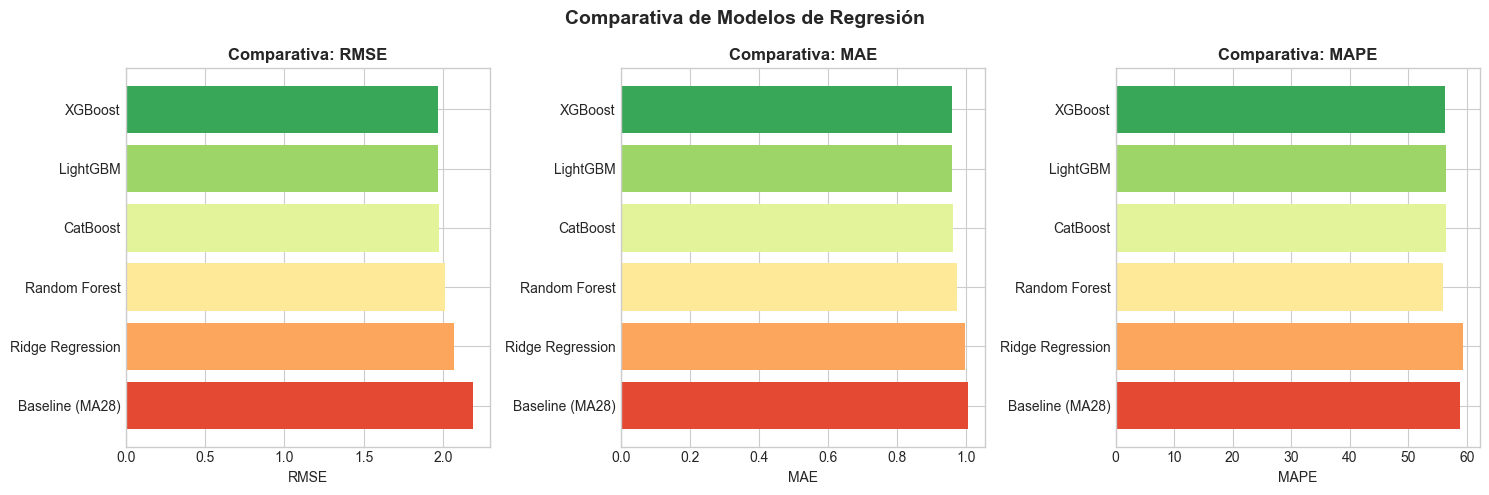

In [86]:
baseline_rmse_val = results_df[results_df['model'] == 'Baseline (MA28)']['rmse'].values[0]
winner = results_df.iloc[0]
mejora = (baseline_rmse_val - winner['rmse']) / baseline_rmse_val * 100
print(f"Mejor modelo: {winner['model']}")
print(f"   Mejora vs Baseline : {mejora:.1f}%")

plot_model_comparison(results_df)

**Conclusiones:**
*  Los tres modelos de boosting (**XGBoost**, **LightGBM**, **CatBoost**) superan claramente al bagging (**Random Forest**) y a la regresión lineal (**Ridge**), confirmando que el aprendizaje secuencial es más adecuado para este problema de series temporales.

*  **XGBoost:** es el modelo ganador con **RMSE 1.97**, igualando la precisión de **LightGBM** pero con un tiempo de entrenamiento de ~24 minutos frente a los ~65 minutos de **LightGBM** en este dataset y configuración concretos. En un problema de producción donde el modelo se reentrena periódicamente, la eficiencia computacional es un criterio relevante.

*  **LightGBM:** empata en precisión (RMSE 1.97) pero resultó más lento en esta configuración por el coste de construcción del dataset y el bagging frecuente sobre 57M filas. Podría recuperar su ventaja de velocidad con ajuste de parámetros específicos (`max_bin`, `bagging_freq`).

*  **La mejora del 9.9% sobre el Baseline** (promedio móvil de 28 días) confirma que el Feature Engineering aporta valor real, ya que el modelo aprende patrones que una simple media histórica no captura.

*  Como siguiente paso, se aplica optimización de hiperparámetros con Optuna sobre XGBoost para intentar mejorar adicionalmente el RMSE antes de la evaluación final en el Validation set.

### 11.8 Evaluación del modelo ganador

#### 11.8.1 Optimización de hiperparámetros con Optuna (**XGBoost**)

Se optimiza sobre los últimos 5M registros del training (datos más recientes -> más representativos del período a predecir).

Optuna usa optimización bayesiana: aprende de cada trial anterior para elegir la siguiente combinación más prometedora, encontrando mejores parámetros en menos pruebas que una búsqueda aleatoria.

In [87]:
print("OPTIMIZACIÓN XGBOOST")
print("=" * 60)

# Muestra temporal: últimos 5M registros (más cercanos al test)
len_tune = 5_000_000
X_tune = X_train.iloc[-len_tune:]
y_tune = y_train.iloc[-len_tune:]

best_model_name = winner['model']

print(f"\nOptimizando {best_model_name} sobre {len(X_tune):,} filas...")

# Si el Baseline es mejor, algo falló en el entrenamiento -> detener el proceso
if best_model_name == 'Baseline (MA28)':
    raise ValueError(
        "El Baseline superó a todos los modelos ML. "
        "Revisa el Feature Engineering y el entrenamiento antes de continuar con Optuna!"
    )

objective_map = {
    'XGBoost': objective_xgb,
    'LightGBM': objective_lgb,
    'CatBoost': objective_cat
}

t0 = time.time()

study = optuna.create_study(direction='minimize')
study.optimize(
    make_objective(objective_map[best_model_name], X_tune, y_tune, X_test, y_test),
    n_trials=30,
    show_progress_bar=True
)

print(f"\nOptuna completado en {(time.time() - t0) / 60:.1f} minutos")
print(f"   Mejor RMSE (muestra): {study.best_value:.4f}")
print(f"   Mejores parámetros:")

for k, v in study.best_params.items():
    print(f"      {k}: {v}")

OPTIMIZACIÓN XGBOOST

Optimizando XGBoost sobre 5,000,000 filas...


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna completado en 46.4 minutos
   Mejor RMSE (muestra): 1.9891
   Mejores parámetros:
      n_estimators: 1933
      learning_rate: 0.023180204824782783
      max_depth: 8
      subsample: 0.642599601876698
      colsample_bytree: 0.9059717672126593
      min_child_weight: 31
      gamma: 0.45408573013301645
      reg_alpha: 0.3421456288729119
      reg_lambda: 1.1374811149330148


**Conclusiones:**

*  Optuna encontró que el modelo óptimo necesita **más árboles y aprendizaje más lento** (n_estimators=1933, learning_rate=0.023) frente al modelo base (n_estimators=1000, learning_rate=0.05). Esto confirma lo que ya indicaba el base: llegó a 998/1000 iteraciones sin hacer early stopping, señal de que aún tenía margen de mejora.

*  `max_depth=8` alcanzó el límite superior del rango de búsqueda, lo que sugiere que el modelo se beneficia de árboles profundos. Con 57M filas y múltiples features de lag, estacionalidad y clustering, la complejidad extra está justificada.

*  `min_child_weight=31` indica que el modelo requiere al menos 31 filas por hoja antes de hacer una división, actuando como regularización implícita frente al sobreajuste.

*  `reg_alpha=0.342` refleja una regularización L1 moderada que penaliza ligeramente los pesos de features poco relevantes, reduciendo el riesgo de sobreajuste sin llevar pesos a cero de forma agresiva.

*  El RMSE de 1.989 obtenido durante Optuna ya es comparable al 1.97 del modelo base, a pesar de haberse entrenado solo sobre 5M filas. Indica que los hiperparámetros encontrados son sólidos.

#### 11.8.2 Reentrenamiento con parámetros óptimos sobre dataset completo

Los parámetros encontrados por Optuna sobre 5M filas se aplican ahora sobre el dataset completo (57M filas) para obtener el modelo final.

In [88]:
print("REENTRENANDO XGBOOST CON PARÁMETROS ÓPTIMOS")
print("=" * 60)

xgb_tuned = retrain_best_xgb(study, X_train, y_train, X_test, y_test)

y_pred_tuned = np.clip(xgb_tuned.predict(X_test), 0, None)
results['XGBoost (Optuna)'] = evaluate_model(
    y_test.values, y_pred_tuned, 'XGBoost (Optuna)'
)

# Comparar con XGBoost base
rmse_base  = results['XGBoost']['rmse']
rmse_tuned = results['XGBoost (Optuna)']['rmse']
mejora_optuna = (rmse_base - rmse_tuned) / rmse_base * 100

print(f"\n   XGBoost base -> RMSE: {rmse_base:.4f}")
print(f"   XGBoost Optuna -> RMSE: {rmse_tuned:.4f}")
print(f"\n   Mejora con Optuna: {mejora_optuna:.1f}%")

REENTRENANDO XGBOOST CON PARÁMETROS ÓPTIMOS
Tiempo: 1838.9s | Best iteration: 1030
XGBoost (Optuna)
   RMSE: 1.9645
   MAE: 0.9580
   MAPE: 56.31%

   XGBoost base -> RMSE: 1.9673
   XGBoost Optuna -> RMSE: 1.9645

   Mejora con Optuna: 0.1%


**Conclusiones:**

*  El reentrenamiento sobre el dataset completo con los parámetros óptimos obtuvo RMSE 1.9645, mejorando un 0.1% respecto al XGBoost base (1.9673). La mejora es pequeña pero consistente.

*  El early stopping se activó en la iteración 1030 de las 1933 configuradas, convergiendo antes del límite de árboles. A diferencia del modelo base que necesitó 998/1000 iteraciones, aquí el modelo encontró su punto óptimo gracias al `learning_rate` más bajo combinado con regularización L1 (`reg_alpha`=0.342).

#### 11.8.3 Evaluación en dataset de validación

In [89]:
print("EVALUACIÓN FINAL EN VALIDACIÓN SET")
print("=" * 60)

y_pred_validation = np.clip(xgb_tuned.predict(X_validation), 0, None)
validation_results = evaluate_model(
    y_validation.values,
    y_pred_validation,
    'XGBoost (Optuna) — VALIDATION FINAL'
)

mejora_final = (results['Baseline (MA28)']['rmse'] - validation_results['rmse']) / results['Baseline (MA28)']['rmse'] * 100

print(f"\n   Mejora final vs Baseline: {mejora_final:.1f}%")

EVALUACIÓN FINAL EN VALIDACIÓN SET
XGBoost (Optuna) — VALIDATION FINAL
   RMSE: 1.8994
   MAE: 0.9592
   MAPE: 55.82%

   Mejora final vs Baseline: 13.1%


**Conclusiones:**

*  El modelo final obtiene un RMSE de 1.8994 en el dataset de *Validation*, representando una mejora del 13.1% sobre el *Baseline (promedio móvil de 28 días)*. Es el resultado definitivo del TFM ya que el dataset de *Validation* no se usó en ningún momento durante el entrenamiento ni la selección del modelo.

*  El RMSE en *Validation* (1.8994) es mejor que en *Test* (1.9645), lo que indica que el modelo generaliza bien y no está sobreajustado al período de Test. El modelo captura patrones generales de demanda, no específicos de un período concreto.

#### 11.8.4 Feature importantes del modelo

Muestra qué features contribuyen más a las predicciones. Esto es útil para justificar por qué se crearon esas features en el Feature Engineering y cuáles son prescindibles.

FEATURE IMPORTANTES PARA EL MODELO


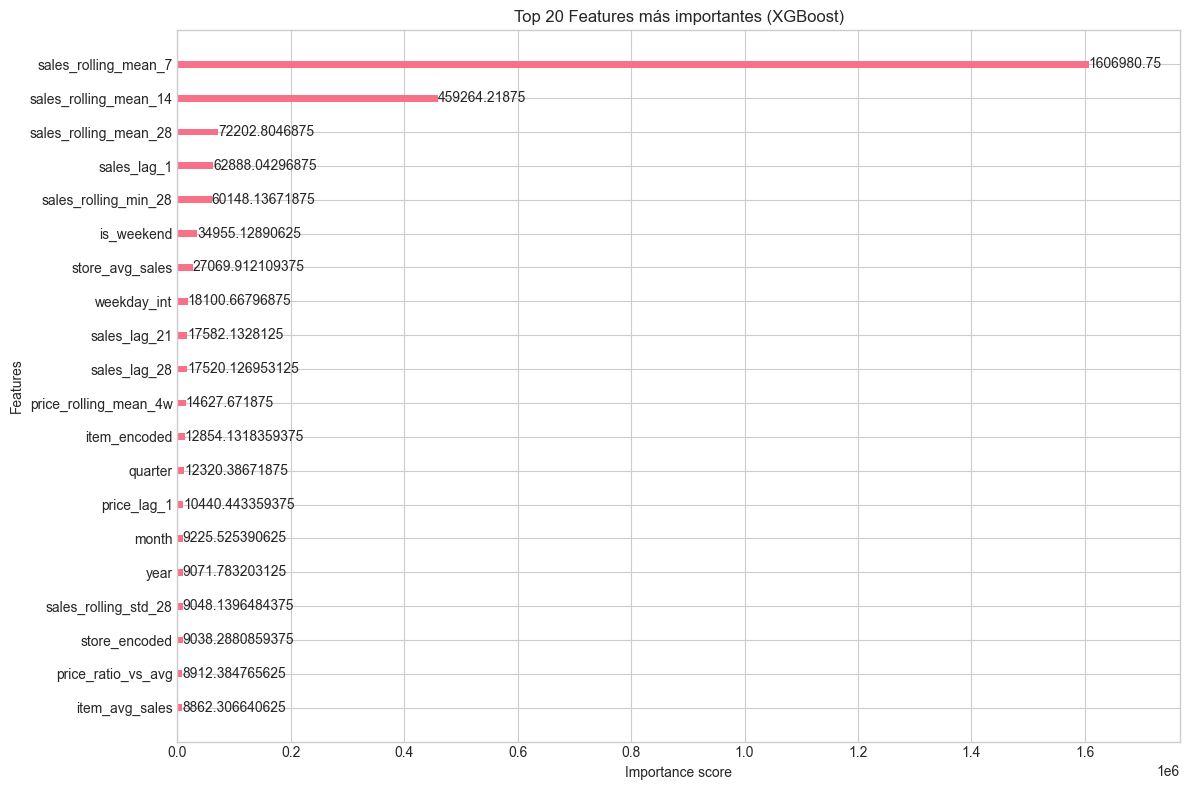

In [90]:
print("FEATURE IMPORTANTES PARA EL MODELO")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 8))

xgb.plot_importance(
    xgb_tuned,
    max_num_features=20,
    importance_type='gain',   # 'gain' = mejora media que aporta cada feature
    ax=ax
)

plt.title('Top 20 Features más importantes (XGBoost)')
plt.tight_layout()
plt.show()

**Conclusiones:**

*  Las medias móviles de ventas dominan claramente: `sales_rolling_mean_7` (la media de los últimos 7 días) es la feature más importante con diferencia, seguida de `sales_rolling_mean_14`. Esto confirma que el comportamiento reciente es el mejor predictor del comportamiento futuro.

*  Los lags de ventas (`sales_lag_1`, `sales_lag_21`, `sales_lag_28`) aparecen en posiciones altas, validando el análisis ACF/PACF que mostraba una fuerte correlación con valores pasados, especialmente en lag_1 (~0.78).

*  `store_avg_sales` aparece en el top 10, confirmando que el contexto de la tienda (su nivel de ventas histórico) aporta información relevante más allá de los patrones temporales.

*  Las features temporales `weekday_int` e `is_weekend` aparecen en el top 10, validando que el patrón semanal detectado en el análisis de series temporales tiene impacto real en las predicciones.

*  Features de precio (`price_rolling_mean_4w`, `price_lag_1`, `price_ratio_vs_avg`) aparecen en posiciones intermedias, indicando que el precio tiene influencia moderada pero real en la demanda.

#### 11.8.5 Guardar el modelo final

In [91]:
print("GUARDAR EL MODELO FINAL")
print("=" * 60)

with open(f'{MODELS_PATH}/best_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)
print(f"\n   best_model.pkl -> XGBoost con parámetros finales")

results_df_final = pd.DataFrame(results).T.reset_index(drop=True)
results_df_final = results_df_final.sort_values('rmse').reset_index(drop=True)
results_df_final.to_csv(f'{MODELS_PATH}/model_comparison.csv', index=False)
print(f"   model_comparison.csv -> comparativa de todos los modelos")

# NOTA: LabelEncoder no gestiona categorías nuevas en producción (nuevos productos/tiendas).
# En un entorno productivo, se recomienda sustituir por OrdinalEncoder(handle_unknown='use_encoded_value')
# o implementar un mapeo de fallback a la categoría más similar
label_encoders = get_label_encoders(df_sales_long, categorical_cols)
with open(f'{FEATURES_PATH}/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print(f"   label_encoders.pkl -> encoders para predicción en producción")

GUARDAR EL MODELO FINAL

   best_model.pkl -> XGBoost con parámetros finales
   model_comparison.csv -> comparativa de todos los modelos
   label_encoders.pkl -> encoders para predicción en producción


---

## 12. SISTEMA DE ABASTECIMIENTO

Con el modelo **XGBoost** entrenado y validado, el último paso es convertir las predicciones de ventas en decisiones concretas de compra.

El sistema responde a la pregunta: **¿cuántas unidades hay que pedir para cada producto en cada tienda durante los próximos 7 días?**

Para ello, por cada combinación producto-tienda:

1. Se predice la demanda esperada para los próximos 7 días usando el modelo.

2. Se añade un **stock de seguridad** como buffer ante la variabilidad de la demanda y así evitar *stockout* (rotura de stock).

3. Se calcula la **cantidad a pedir** como la diferencia entre lo que se necesita y lo que ya hay en stock.

4. Se asigna una **prioridad** (ALTA / NORMAL) según el nivel de urgencia del pedido.

El resultado es una tabla de recomendaciones de abastecimiento lista para ser consumida por el equipo de compras o integrada en un sistema ERP.

In [92]:
print("RECOMENDACIONES DE ABASTECIMIENTO")
print("=" * 60)

# Clasificar productos por nivel de rotación usando item_avg_sales
item_rotation = (
    df_sales_long.groupby('item')['item_avg_sales']
    .first()
    .reset_index()
    .rename(columns={'item_avg_sales': 'avg_sales'})
)

# Percentiles para definir los tres grupos
p33 = item_rotation['avg_sales'].quantile(0.33)
p66 = item_rotation['avg_sales'].quantile(0.66)

low_rotation = item_rotation[item_rotation['avg_sales'] <= p33]['item'].tolist()
medium_rotation = item_rotation[(item_rotation['avg_sales'] > p33) & (item_rotation['avg_sales'] <= p66)]['item'].tolist()
high_rotation = item_rotation[item_rotation['avg_sales'] > p66]['item'].tolist()

print(f"\nBaja rotación: {len(low_rotation)} productos (avg_sales ≤ {p33:.2f})")
print(f"Media rotación: {len(medium_rotation)} productos (avg_sales {p33:.2f} - {p66:.2f})")
print(f"Alta rotación: {len(high_rotation)} productos (avg_sales > {p66:.2f})")

# Selecciona 2 productos de cada grupo
np.random.seed(42)
sample_items = (
    np.random.choice(low_rotation, 2, replace=False).tolist() +
    np.random.choice(medium_rotation, 2, replace=False).tolist() +
    np.random.choice(high_rotation, 2, replace=False).tolist()
)

store_id = df_sales_long['store'].iloc[0]       # Primera tienda disponible, solo para demo. En producción este valor vendría de un parámetro externo (ej. el sistema ERP, Enterprise Resource Planning, envía el store_id al ejecutar el proceso de abastecimiento semanal)

# Generar recomendaciones con los 6 productos representativos
orders_df = generate_replenishment_orders(
    model=xgb_tuned,
    df_validation=df_validation,
    X_validation=X_validation,
    store_id=store_id,
    item_ids=sample_items
)

orders_df

RECOMENDACIONES DE ABASTECIMIENTO

Baja rotación: 1006 productos (avg_sales ≤ 0.31)
Media rotación: 1006 productos (avg_sales 0.31 - 0.81)
Alta rotación: 1037 productos (avg_sales > 0.81)


,current_stock,forecast_7d,safety_stock,order_quantity,priority,item_id,store_id
0,53,2.00,0.10,0,NORMAL,SUPERMARKET_3_284,South_End
1,23,3.00,0.20,0,NORMAL,HOME_&_GARDEN_2_314,South_End
2,47,4.00,0.30,0,NORMAL,HOME_&_GARDEN_2_329,South_End
3,78,1.20,0.10,0,NORMAL,SUPERMARKET_1_049,South_End
4,46,13.50,1.40,0,NORMAL,SUPERMARKET_2_194,South_End
5,88,53.70,2.70,0,NORMAL,HOME_&_GARDEN_1_277,South_End


**Análisis fila por fila:**

Todos los pedidos son 0 y prioridad NORMAL. Esta es la ejecución sin `stock_overrides`, con stocks aleatorios altos (20-100). El sistema funciona correctamente, si hay stock suficiente, no pide nada.

| Item | Stock | Forecast | Semanas cubiertas |
| :--- | :--- | :--- | :--- |
| SUPERMARKET_3_284 | 53 | 2.0 | ~26 semanas |
| HOME_&_GARDEN_2_314 | 23 | 3.0 | ~8 semanas |
| HOME_&_GARDEN_2_329 | 47 | 4.0 | ~11 semanas |
| SUPERMARKET_1_049 | 78 | 1.2 | ~65 semanas |
| SUPERMARKET_2_194 | 46 | 13.5 | ~3.4 semanas |
| HOME_&_GARDEN_1_277 | 88 | 53.7 | ~1.6 semanas |

**Conclusiones:**

*  El sistema funciona correctamente — ningún producto necesita pedido esta semana porque todos los stocks cubren al menos la demanda de los próximos 7 días.

*  *HOME_&_GARDEN_1_277* es el caso más crítico a vigilar. Con una demanda de 53.7 unidades semanales y solo 88 en stock, se agotará en aproximadamente 1.6 semanas. Aunque esta semana no requiere pedido, la próxima semana será el primero en activar prioridad ALTA.

*  *SUPERMARKET_2_194* también requiere atención próxima, con ~3.4 semanas de cobertura, necesitará reposición en los próximos días si el ciclo de pedido es semanal.

*  *SUPERMARKET_1_049* tiene un stock claramente sobredimensionado: 78 unidades para una demanda de apenas 1.2 semanales implica más de un año de stock (capital inmovilizado innecesariamente).

*  El contraste entre los productos de baja rotación (*SUPERMARKET_1_049*: 65 semanas) y alta rotación (*HOME_&_GARDEN_1_277*: 1.6 semanas) ilustra perfectamente la necesidad de un sistema automatizado, ya que gestionar manualmente estos ritmos tan distintos es inviable a escala.

In [93]:
# Demo: forzar stock muy bajo en 3 items (uno de cada grupo) para provocar ALTA prioridad
stock_overrides = {
    sample_items[0]: 1,         # Baja rotación -> stock crítico
    sample_items[2]: 3,         # Media rotación -> stock crítico
    sample_items[4]: 5,         # Alta rotación -> stock crítico
}

orders_df = generate_replenishment_orders(
    model=xgb_tuned,
    df_validation=df_validation,
    X_validation=X_validation,
    store_id=store_id,
    item_ids=sample_items,
    stock_overrides=stock_overrides
)
orders_df

,current_stock,forecast_7d,safety_stock,order_quantity,priority,item_id,store_id
0,5,13.50,1.40,10.00,ALTA,SUPERMARKET_2_194,South_End
1,1,2.00,0.10,1.00,ALTA,SUPERMARKET_3_284,South_End
2,3,4.00,0.30,1.00,NORMAL,HOME_&_GARDEN_2_329,South_End
3,44,3.00,0.20,0.00,NORMAL,HOME_&_GARDEN_2_314,South_End
4,22,1.20,0.10,0.00,NORMAL,SUPERMARKET_1_049,South_End
5,87,53.70,2.70,0.00,NORMAL,HOME_&_GARDEN_1_277,South_End


**Explicación de columnas:**

| Columna | Significado |
| :--- | :--- |
| current_stock | Unidades actuales en la tienda (simulado en demo) |
| forecast_7d | Demanda total predicha por XGBoost para los próximos 7 días |
| safety_stock | Buffer de seguridad ante variabilidad (3 × desviación estándar de las predicciones diarias) |
| order_quantity | Unidades a pedir = max(0, forecast_7d + safety_stock - current_stock) |
| priority | ALTA si current_stock < reorder_point × 0.5, NORMAL en caso contrario |
| item_id | Identificador del producto |
| store_id | Tienda evaluada (South_End en todos) |

**Análisis fila por fila:**

*Fila 0 — SUPERMARKET_2_194 (ALTA)*

*  Stock: 5 unidades, demanda esperada: 13.5 -> solo cubre el 37% de la demanda semanal.
*  Pedir 10 unidades urgentemente -> riesgo real de stockout a mitad de semana.

*Fila 1 — SUPERMARKET_3_284 (ALTA)*

*  Stock: 1 unidad, demanda esperada: 2 -> prácticamente sin stock.
*  Pedir 1 unidad -> producto de baja rotación pero en situación crítica.

*Fila 2 — HOME_&_GARDEN_2_329 (NORMAL)*

*  Stock: 3 unidades, demanda: 4 -> stock justo pero cubre más del 50% del reorder_point.
*  Pedir 1 unidad como prevención.

*Fila 3 — HOME_&_GARDEN_2_314 (NORMAL)*

*  Stock: 44 unidades, demanda: 3 -> stock más que suficiente para toda la semana.
*  No se pide nada (`order_quantity` = 0).

*Fila 4 — SUPERMARKET_1_049 (NORMAL)*

*  Stock: 22 unidades, demanda: 1.2 -> stock cubre más de 18 semanas.
*  No se pide nada — producto de muy baja rotación con stock sobredimensionado.

*Fila 5 — HOME_&_GARDEN_1_277 (NORMAL)*

*  Stock: 87 unidades, demanda: 53.7 -> el producto de mayor rotación de la tabla.
*  A pesar de la alta demanda, el stock actual (87) supera el `reorder_point` (56.4) — no se pide nada esta semana.

**Conclusiones:**

*  El sistema identifica correctamente los 2 productos en situación crítica (ALTA prioridad) con stocks insuficientes para cubrir la demanda semanal prevista, permitiendo al equipo de compras actuar de forma inmediata.

*  *HOME_&_GARDEN_1_277* es el producto de mayor rotación (`forecast_7d` = 53.7) pero su stock actual (87 unidades) es suficiente para esta semana. Sin embargo, con una demanda tan alta será el primero en necesitar reposición la semana siguiente.

*  *SUPERMARKET_1_049* tiene un stock (22 unidades) muy sobredimensionado respecto a su demanda (1.2 unidades semanales), se sugiere una gestión de inventario ineficiente para ese producto, inmovilizando capital innecesariamente (físicamente ocupan espacio en el almacén y representan dinero que ya se gastó en comprarlas). En retail esto se llama **"capital de trabajo inmovilizado"** (dinero que está "atrapado" en forma de mercancía sin venderse).

*  El safety_stock es pequeño en todos los casos (0.1 - 2.7) porque las predicciones diarias son bastante estables (poca variabilidad entre días), lo que indica que el modelo predice con consistencia la demanda de estos productos.

In [94]:
# Exportar órdenes de reposición completas para Power BI
# NOTA: el stock actual se simula aleatoriamente (en producción vendría del ERP)
print("EXPORTANDO ÓRDENES DE REPOSICIÓN PARA POWER BI")
print("=" * 60)

all_stores = df_sales_long['store'].unique().tolist()
all_items  = df_sales_long['item'].unique().tolist()

all_orders = list()
for store in all_stores:
    store_orders = generate_replenishment_orders(
        model=xgb_tuned,
        df_validation=df_validation,
        X_validation=X_validation,
        store_id=store,
        item_ids=all_items
    )
    all_orders.append(store_orders)
    print(f"   {store}: {len(store_orders)} órdenes generadas")

orders_full_df = pd.concat(all_orders, ignore_index=True)
orders_full_df.to_csv(f'{PROCESSED_FILE_PATH}/replenishment_orders.csv', index=False)

print(f"\n   Total registros: {len(orders_full_df)} ({len(all_stores)} tiendas x {len(all_items)} productos)")
print(f"   Prioridad ALTA: {(orders_full_df['priority'] == 'ALTA').sum()} productos")
print(f"   Prioridad NORMAL: {(orders_full_df['priority'] == 'NORMAL').sum()} productos")
print(f"\n   Fichero replenishment_orders.csv creado correctamente!")

EXPORTANDO ÓRDENES DE REPOSICIÓN PARA POWER BI
   South_End: 3049 órdenes generadas
   Roxbury: 3049 órdenes generadas
   Back_Bay: 3049 órdenes generadas
   Greenwich_Village: 3049 órdenes generadas
   Harlem: 3049 órdenes generadas
   Tribeca: 3049 órdenes generadas
   Brooklyn: 3049 órdenes generadas
   Midtown_Village: 3049 órdenes generadas
   Yorktown: 3049 órdenes generadas
   Queen_Village: 3049 órdenes generadas

   Total registros: 30490 (10 tiendas x 3049 productos)
   Prioridad ALTA: 338 productos
   Prioridad NORMAL: 30152 productos

   Fichero replenishment_orders.csv creado correctamente!


---

## 13. CONCLUSIONES GENERALES

### Resumen del trabajo realizado

A lo largo de este proyecto se ha construido un sistema completo de predicción de ventas y gestión de abastecimiento para DSMarket, cubriendo las 4 tareas propuestas:

*  **Tarea 1 — Análisis exploratorio:** Se analizaron las ventas de 3 ciudades (*Boston*, *Nueva York*, *Filadelfia*), identificando patrones de estacionalidad semanal, diferencias entre ciudades y el impacto de eventos y precios en la demanda.

*  **Tarea 2 — Clustering:** Se segmentaron los 3.049 productos en 5 grupos y las 10 tiendas en 3 grupos con comportamientos diferenciados, aportando información estratégica para campañas de marketing y gestión por segmentos.

*  **Tarea 3 — Predicción de ventas:** Se entrenaron y compararon 5 modelos ML (Ridge, Random Forest, XGBoost, LightGBM, CatBoost). XGBoost con optimización Optuna obtuvo el mejor resultado con un **RMSE de 1.8994**, representando una **mejora del 13.1% sobre el Baseline** (promedio móvil de 28 días).

*  **Tarea 4 — Sistema de abastecimiento:** Se desarrolló un sistema que convierte las predicciones del modelo en órdenes de compra semanales con prioridad automática (ALTA / NORMAL), listo para integrarse con el ERP de DSMarket. El flujo completo en producción sería:

    Cada lunes por la mañana (proceso automático):

    1. ERP -> proporciona stock actual de cada producto/tienda.
    2. Base de datos -> proporciona features de los últimos 28 días (lags, rolling means, precio, etc.)
    3. generate_replenishment_orders() -> genera tabla de pedidos
    4. ERP <- recibe las órdenes recomendadas (equipo de compras las revisa y aprueba)

### Valor aportado a DSMarket

El modelo sustituye el enfoque manual y rudimentario actual por un sistema basado en datos que:

*  Reduce el error de predicción un 13.1% frente al método anterior.
*  Automatiza las recomendaciones de reposición de stock semanalmente.
*  Identifica productos con riesgo de stockout antes de que ocurran.
*  Minimiza el capital inmovilizado en productos de baja rotación.

### Próximos pasos

*  Despliegue del modelo como API REST para integración con el ERP.
*  Incorporación de datos de inventario real para eliminar la simulación del stock actual.
*  Extensión del sistema al resto de tiendas y ciudades de DSMarket.
*  Reentrenamiento periódico del modelo con datos nuevos para mantener su precisión a lo largo del tiempo.